In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import json
import math
import pickle
from collections import deque
import random

import gc, time, math
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset

import torchvision.transforms as T

from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

from IPython.display import clear_output

# Set high default resolution for figures
plt.rcParams['figure.dpi'] = 100
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'
#set global dpi
plt.rcParams['figure.dpi'] = 500

from bioplnn.models import (
    SpatiallyEmbeddedClassifier,
    SpatiallyEmbeddedAreaConfig,
    SpatiallyEmbeddedRNN,
    Ablation,
)
from bioplnn.datasets import Mazes
from bioplnn.utils import initialize_dataloader

# Data and checkpoint paths
maze_data_path = "/home/jackking/torch-bioplnn-dev/data/mazes"
checkpoint_path = "/home/jackking/torch-bioplnn-dev/train/checkpoints/"

# Figure save directory
save_dir = "/home/jackking/torch-bioplnn-dev/figures/mazes"
os.makedirs(save_dir, exist_ok=True)

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64,  kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64,          64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(64,         128, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)

        self.fc1 = nn.Linear(128 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x))) 
        x = self.pool(self.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
    
def load_model_and_config(wandb_name, checkpoint, full_cfg=None):
    """Load model configuration and instantiate models."""
    if full_cfg is None:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))

    model_cfg = full_cfg["model_config"]

    if "num_steps" in full_cfg:
        num_steps = full_cfg["num_steps"]
    else:
        num_steps = 20
                
    if full_cfg["model_type"] == "cnn":
        model = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
        classifier = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
    else:
        model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
        classifier = SpatiallyEmbeddedClassifier(**model_cfg)

        # ——— Load checkpoint & weights ———
    try:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
    except:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

    try:
        state_dict = state_dict["model_state"]
    except:
        pass

    model.load_state_dict(prepare_rnn_weights(state_dict))
    classifier.load_state_dict(state_dict)

    return model, classifier, num_steps, full_cfg, state_dict

In [4]:
def map_distances(maze, start_goal, radius=3):
    """
    Computes the minimum number of radius-limited steps from any start_goal cell to every cell,
    but does not allow "jumping" through walls for radius > 1.
    Movement is only allowed along open paths (maze==1) and must not cross walls.
    """
    H, W = maze.shape
    dist = np.full((H, W), np.inf, dtype=float)
    maze2 = maze.copy()
    q = deque()

    # seed from input blocks
    for (i, j), v in np.ndenumerate(start_goal):
        if v:
            dist[i, j] = 0
            maze2[i, j] = 1
            q.append((i, j))

    # all offsets in a (2*radius+1)^2 patch, excluding (0,0)
    nbrs = [(dx, dy)
            for dx in range(-radius, radius + 1)
            for dy in range(-radius, radius + 1)
            if not (dx == 0 and dy == 0)]

    def is_path_clear(i, j, ii, jj):
        """
        Returns True if the path from (i,j) to (ii,jj) does not cross any walls.
        Uses Bresenham's line algorithm to check all intermediate cells.
        """
        from math import copysign

        x0, y0 = i, j
        x1, y1 = ii, jj
        dx = abs(x1 - x0)
        dy = abs(y1 - y0)
        x, y = x0, y0
        n = 1 + dx + dy
        x_inc = 1 if x1 > x0 else -1 if x1 < x0 else 0
        y_inc = 1 if y1 > y0 else -1 if y1 < y0 else 0
        error = dx - dy
        dx *= 2
        dy *= 2

        for _ in range(n):
            if (x, y) != (i, j) and (x, y) != (ii, jj):
                if not (0 <= x < H and 0 <= y < W):
                    return False
                if maze2[x, y] != 1:
                    return False
            if error > 0:
                x += x_inc
                error -= dy
            else:
                y += y_inc
                error += dx
        return True

    while q:
        i, j = q.popleft()
        dnext = dist[i, j] + 1
        for dx, dy in nbrs:
            ii, jj = i + dx, j + dy
            if not (0 <= ii < H and 0 <= jj < W):
                continue
            if maze2[ii, jj] != 1:
                continue

            # Only allow moves that do not cross walls
            if not is_path_clear(i, j, ii, jj):
                continue

            if dist[ii, jj] == np.inf:
                dist[ii, jj] = dnext
                q.append((ii, jj))

    return dist
    
def compute_reachable_mask(maze, start_goal, t):
    """
    All cells reachable within t conv‐hops.
    """
    dist_map = map_distances(maze, start_goal)
    return (dist_map <= t).astype(np.uint8)

def plot_mean_channel_activity(
    activity,       # array of shape [T, C, H, W]
    n, m, inp,          # grid layout: n rows, m cols
    cmap='viridis',  # optional colormap
    savepath=None,
):
    """
    Standalone plot of just the activity panels for one channel,
    with each RGB maze/reachability image plotted below the corresponding activity plot.
    """
    T = activity.shape[0]
    step_indices = np.linspace(0, T - 1, n * m, dtype=int)

    # compute shared color‐scale over all selected frames
    activity = torch.mean(activity, dim=1)
    vmin = torch.min(activity)
    vmax = torch.max(activity)

    # Make figure: 2n rows (activity + RGB), m columns
    fig = plt.figure(figsize=(m * 2, n * 2 * 2))
    grid = fig.add_gridspec(n * 2, m, hspace=0.1, wspace=0.02)
    # fig.suptitle(f"Mean Excitatory Activity", fontsize=14, y=0.98)

    for idx, step in enumerate(step_indices):
        r, c = divmod(idx, m)
        # Activity plot (top row of each pair)
        ax_act = fig.add_subplot(grid[2 * r, c])
        im = ax_act.imshow(activity[step], cmap=cmap, vmin=vmin, vmax=vmax)
        ax_act.set_title(f"T = {step}", fontsize=12)
        # ax_act.axis('off')

        # only add colorbar on the last activity panel
        # if idx == len(step_indices) - 1:
        #     fig.colorbar(im, ax=ax_act, fraction=0.046, pad=0.04)

        # Maze/reachability RGB plot (bottom row of each pair)
        ax_rgb = fig.add_subplot(grid[2 * r + 1, c])

        maze = inp[0].numpy()
        start_goal = inp[-1].numpy()
        reach_map = compute_reachable_mask(maze, start_goal, t=step)  
        # Create an RGB image to combine all three layers
        h, w = maze.shape
        rgb_img = np.ones((h, w, 3), dtype=np.float32)

        # Maze: black (walls) and white (free space)
        # Assume maze is 0 (free) and 1 (wall)
        rgb_img[maze == 1] = [1, 1, 1]  # white
        rgb_img[maze == 0] = [0, 0, 0]  # black

        # Reach map: blue overlay where reach_map is True (or 1)
        if reach_map.dtype != bool:
            reach_mask = reach_map > 0
        else:
            reach_mask = reach_map
        # Set blue channel to 1, red and green to 0 where reach_map is True
        rgb_img[reach_mask] = [0.5, 0.7, 1.0]  # softer blue

        # Start/goal: red dots (override everything else)
        # Assume start_goal is 0 everywhere except at start/goal locations (1)
        if start_goal.ndim == 2:
            red_mask = start_goal > 0
        else:
            red_mask = start_goal.squeeze() > 0
        rgb_img[red_mask] = [1, 0, 0]

        ax_rgb.imshow(rgb_img)
        # ax_rgb.axis('off')

        # Always set y-labels for the first column of each row
        if c == 0:
            ax_act.set_ylabel("Excitatory\nActivity", fontsize=12, labelpad=10, rotation=0, ha='right', va='center')
            ax_rgb.set_ylabel("BFS\nReachability", fontsize=12, labelpad=10, rotation=0, ha='right', va='center')
        
        ax_act.set_xticks([])
        ax_act.set_yticks([])
        ax_rgb.set_xticks([])
        ax_rgb.set_yticks([])

    cbar = fig.colorbar(im, ax=fig.get_axes(), orientation='vertical',
                    fraction=0.02, pad=0.04)
    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, format='svg', bbox_inches='tight', dpi=600)
    plt.show()

# Loading

## Model

In [5]:
## MAZES ##

wandb_name, checkpoint = "dauntless-elevator-522", 390 # ReLU, with I->I recurrence
cnn_wandb_name, cnn_checkpoint = "whole-sunset-502", 1540 # CNN

# ——— Load model config & instantiate ———
model, classifier, num_steps, cfg, state_dict = load_model_and_config(wandb_name, checkpoint)

model.eval()
model.to(device)

classifier.eval()
classifier.to(device)

cnn_model, cnn_classifier, cnn_num_steps, cnn_cfg, cnn_state_dict = load_model_and_config(cnn_wandb_name, cnn_checkpoint)

cnn_classifier.eval()
cnn_classifier.to(device)

/tmp/ipykernel_484252/1130926848.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locatio

SimpleCNN(
  (conv1): Conv2d(4, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU(inplace=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=4608, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)

## Data

In [6]:
batch_size = 128
num_train_samples = batch_size * 1
num_test_samples = batch_size * 1

# MAZES

dim = 48
num_steps = 20
decision_step = 20
train_loader, test_loader = initialize_dataloader(
    seed=42, root=maze_data_path, batch_size=batch_size, dataset="mazes"
)
mazes = Mazes(maze_data_path)

# Figure A - Task

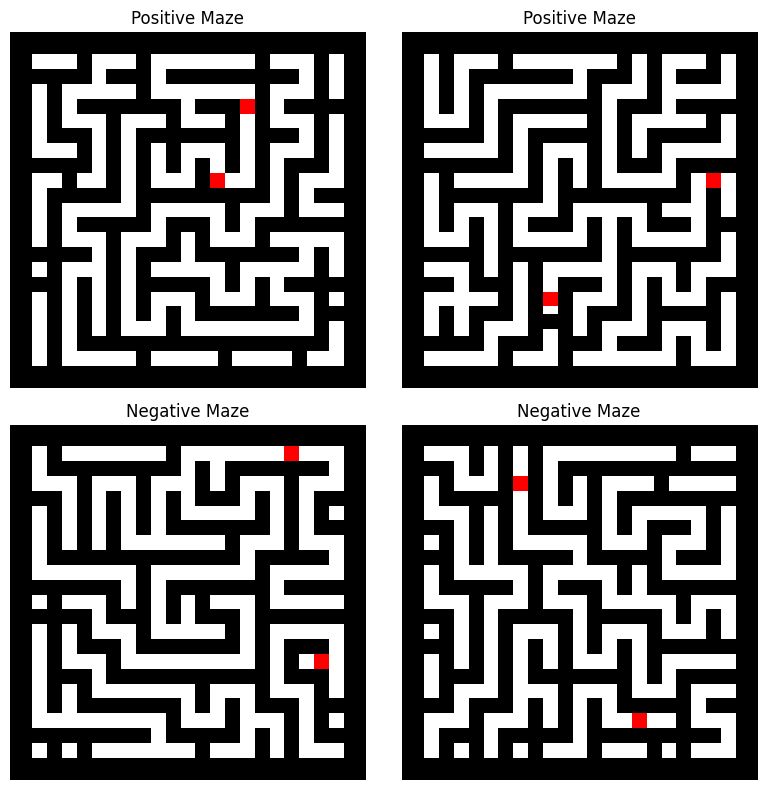

In [9]:
inputs = test_loader.dataset  # pyright: ignore[reportOptionalMemberAccess]
sample_indices = [0, 5, 3, 1]

# Set up grid: 2 rows x 2 cols for 4 samples
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for ax, sample_idx in zip(axes, sample_indices):
    inp, label = inputs[sample_idx][0], inputs[sample_idx][1]
    ax.imshow(mazes.tensor_to_image(inp))
    if label == 1:
        ax.set_title("Positive Maze")
    else:
        ax.set_title("Negative Maze")
    ax.axis('off')

plt.tight_layout()
fig.savefig(os.path.join(save_dir, "figure_a_task.svg"), format='svg', bbox_inches='tight')
plt.show()

# Figure C - Activity x BFS

/tmp/ipykernel_484252/3063276636.py:166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


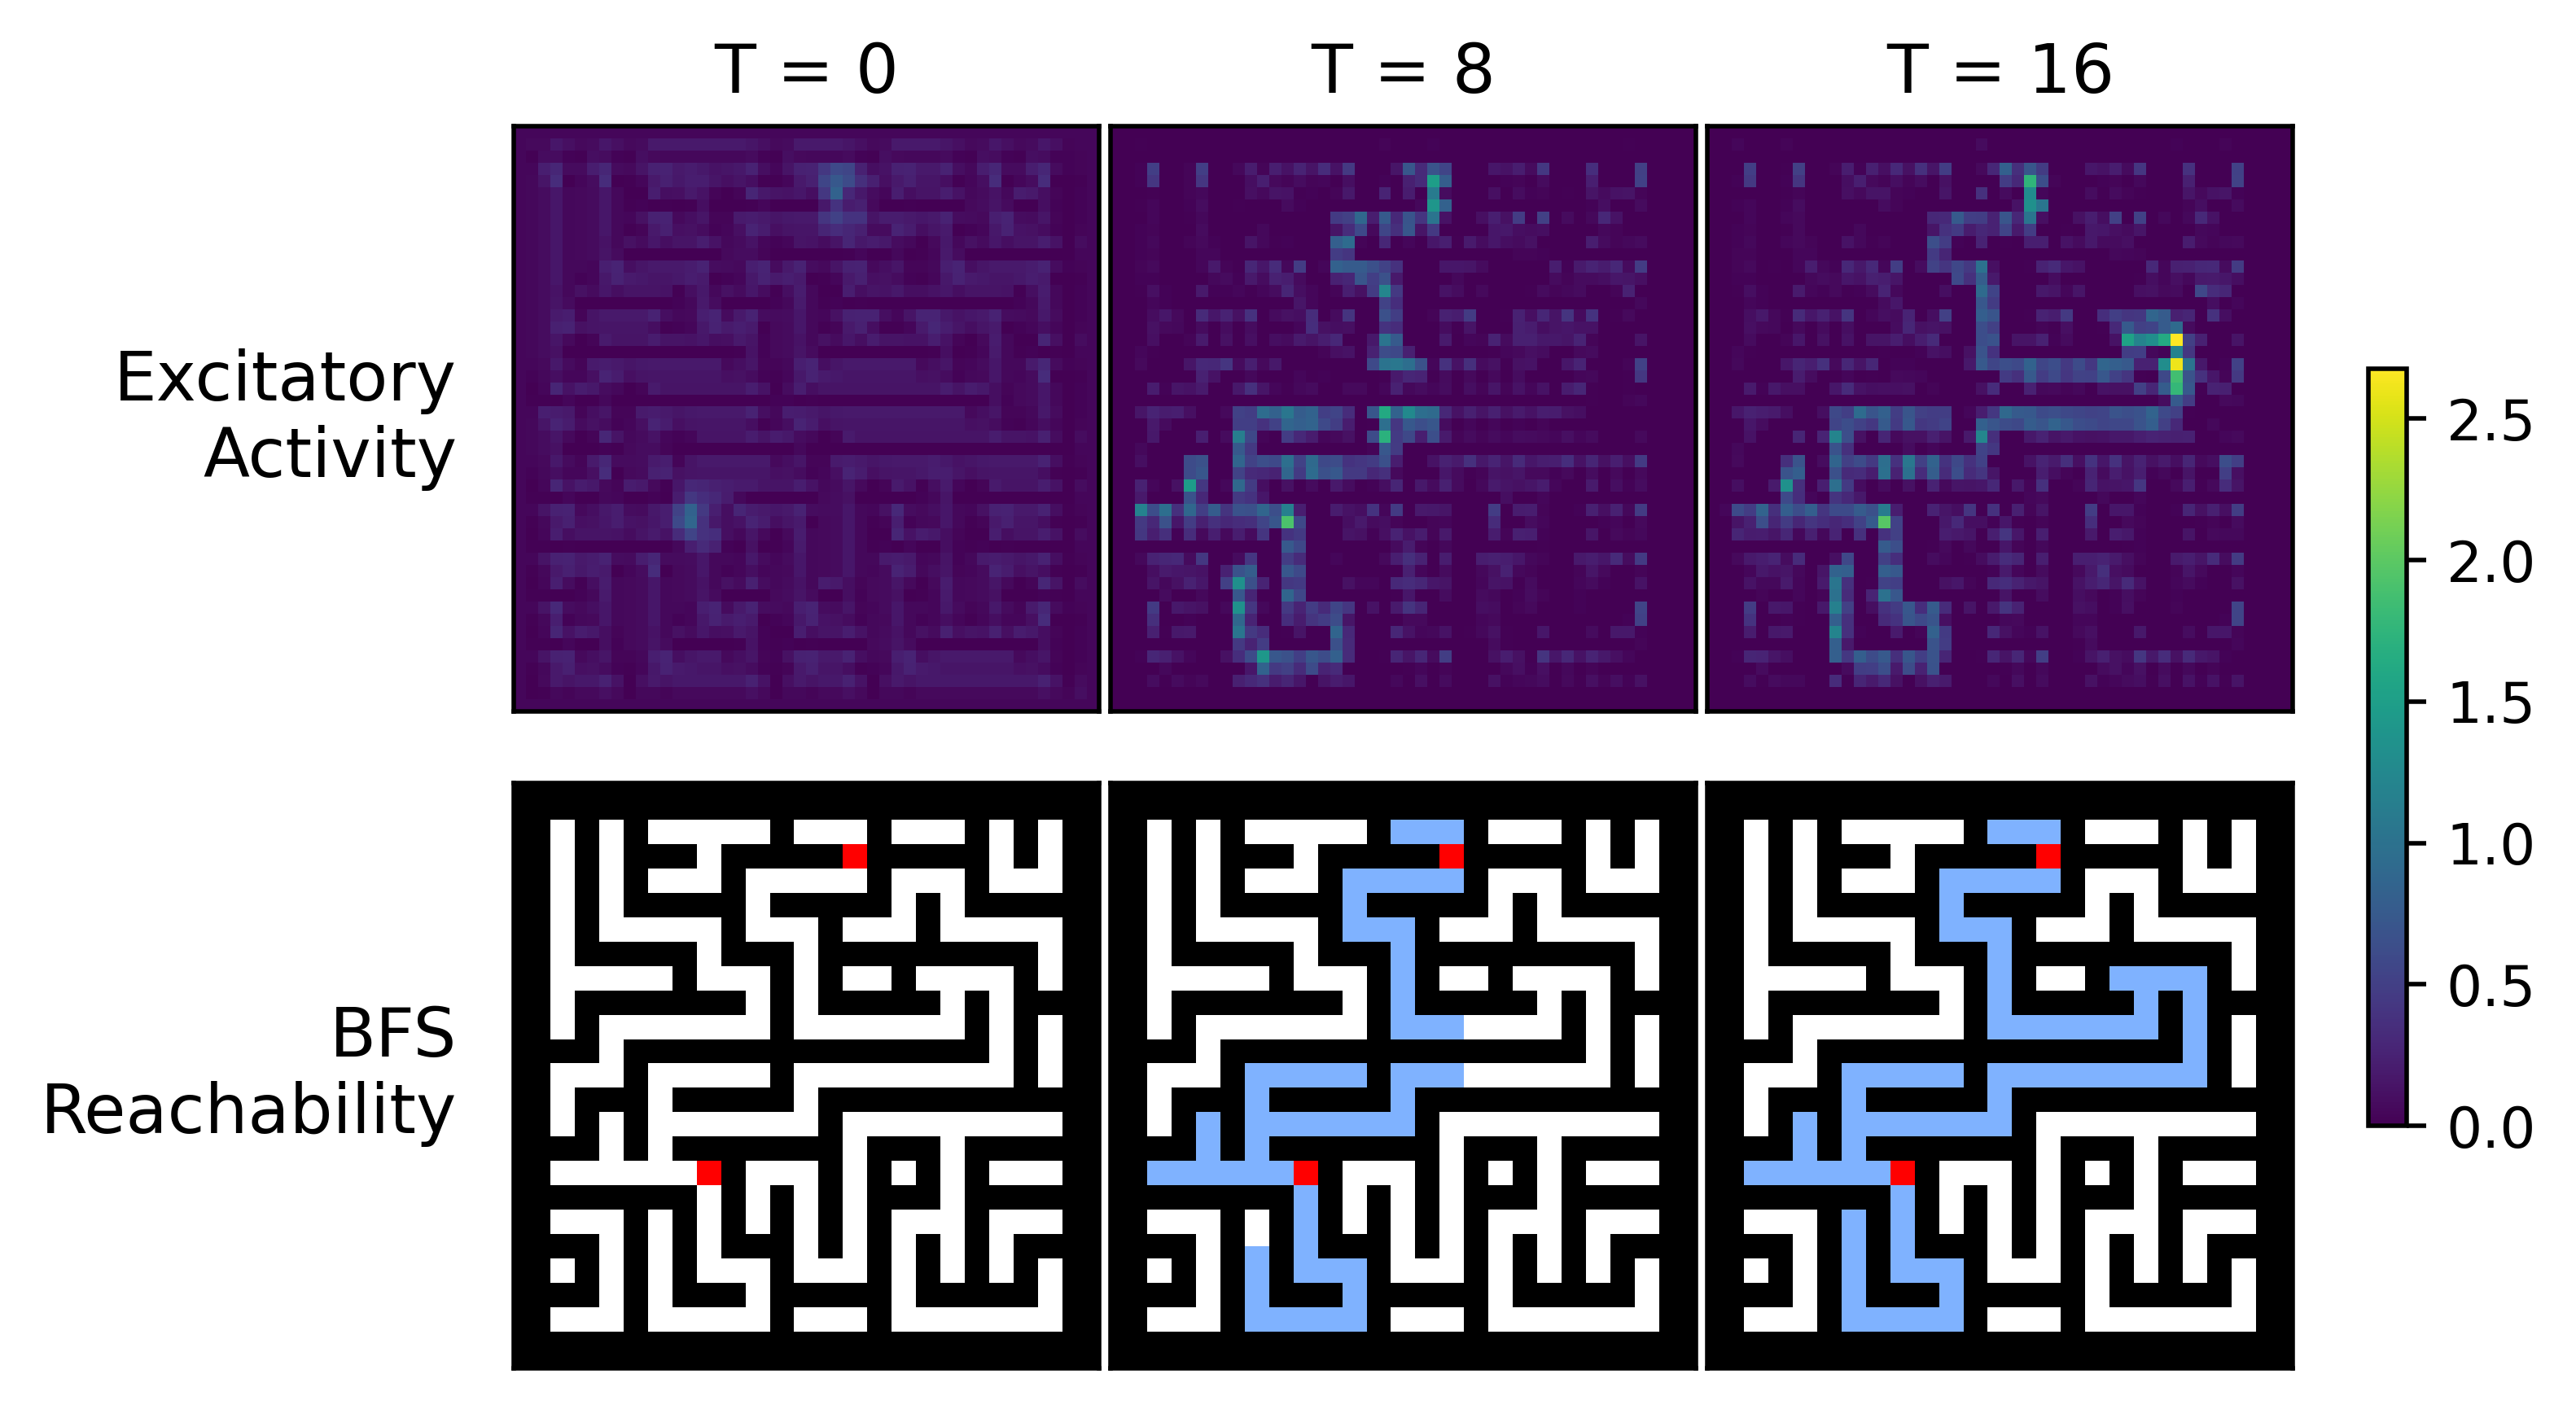

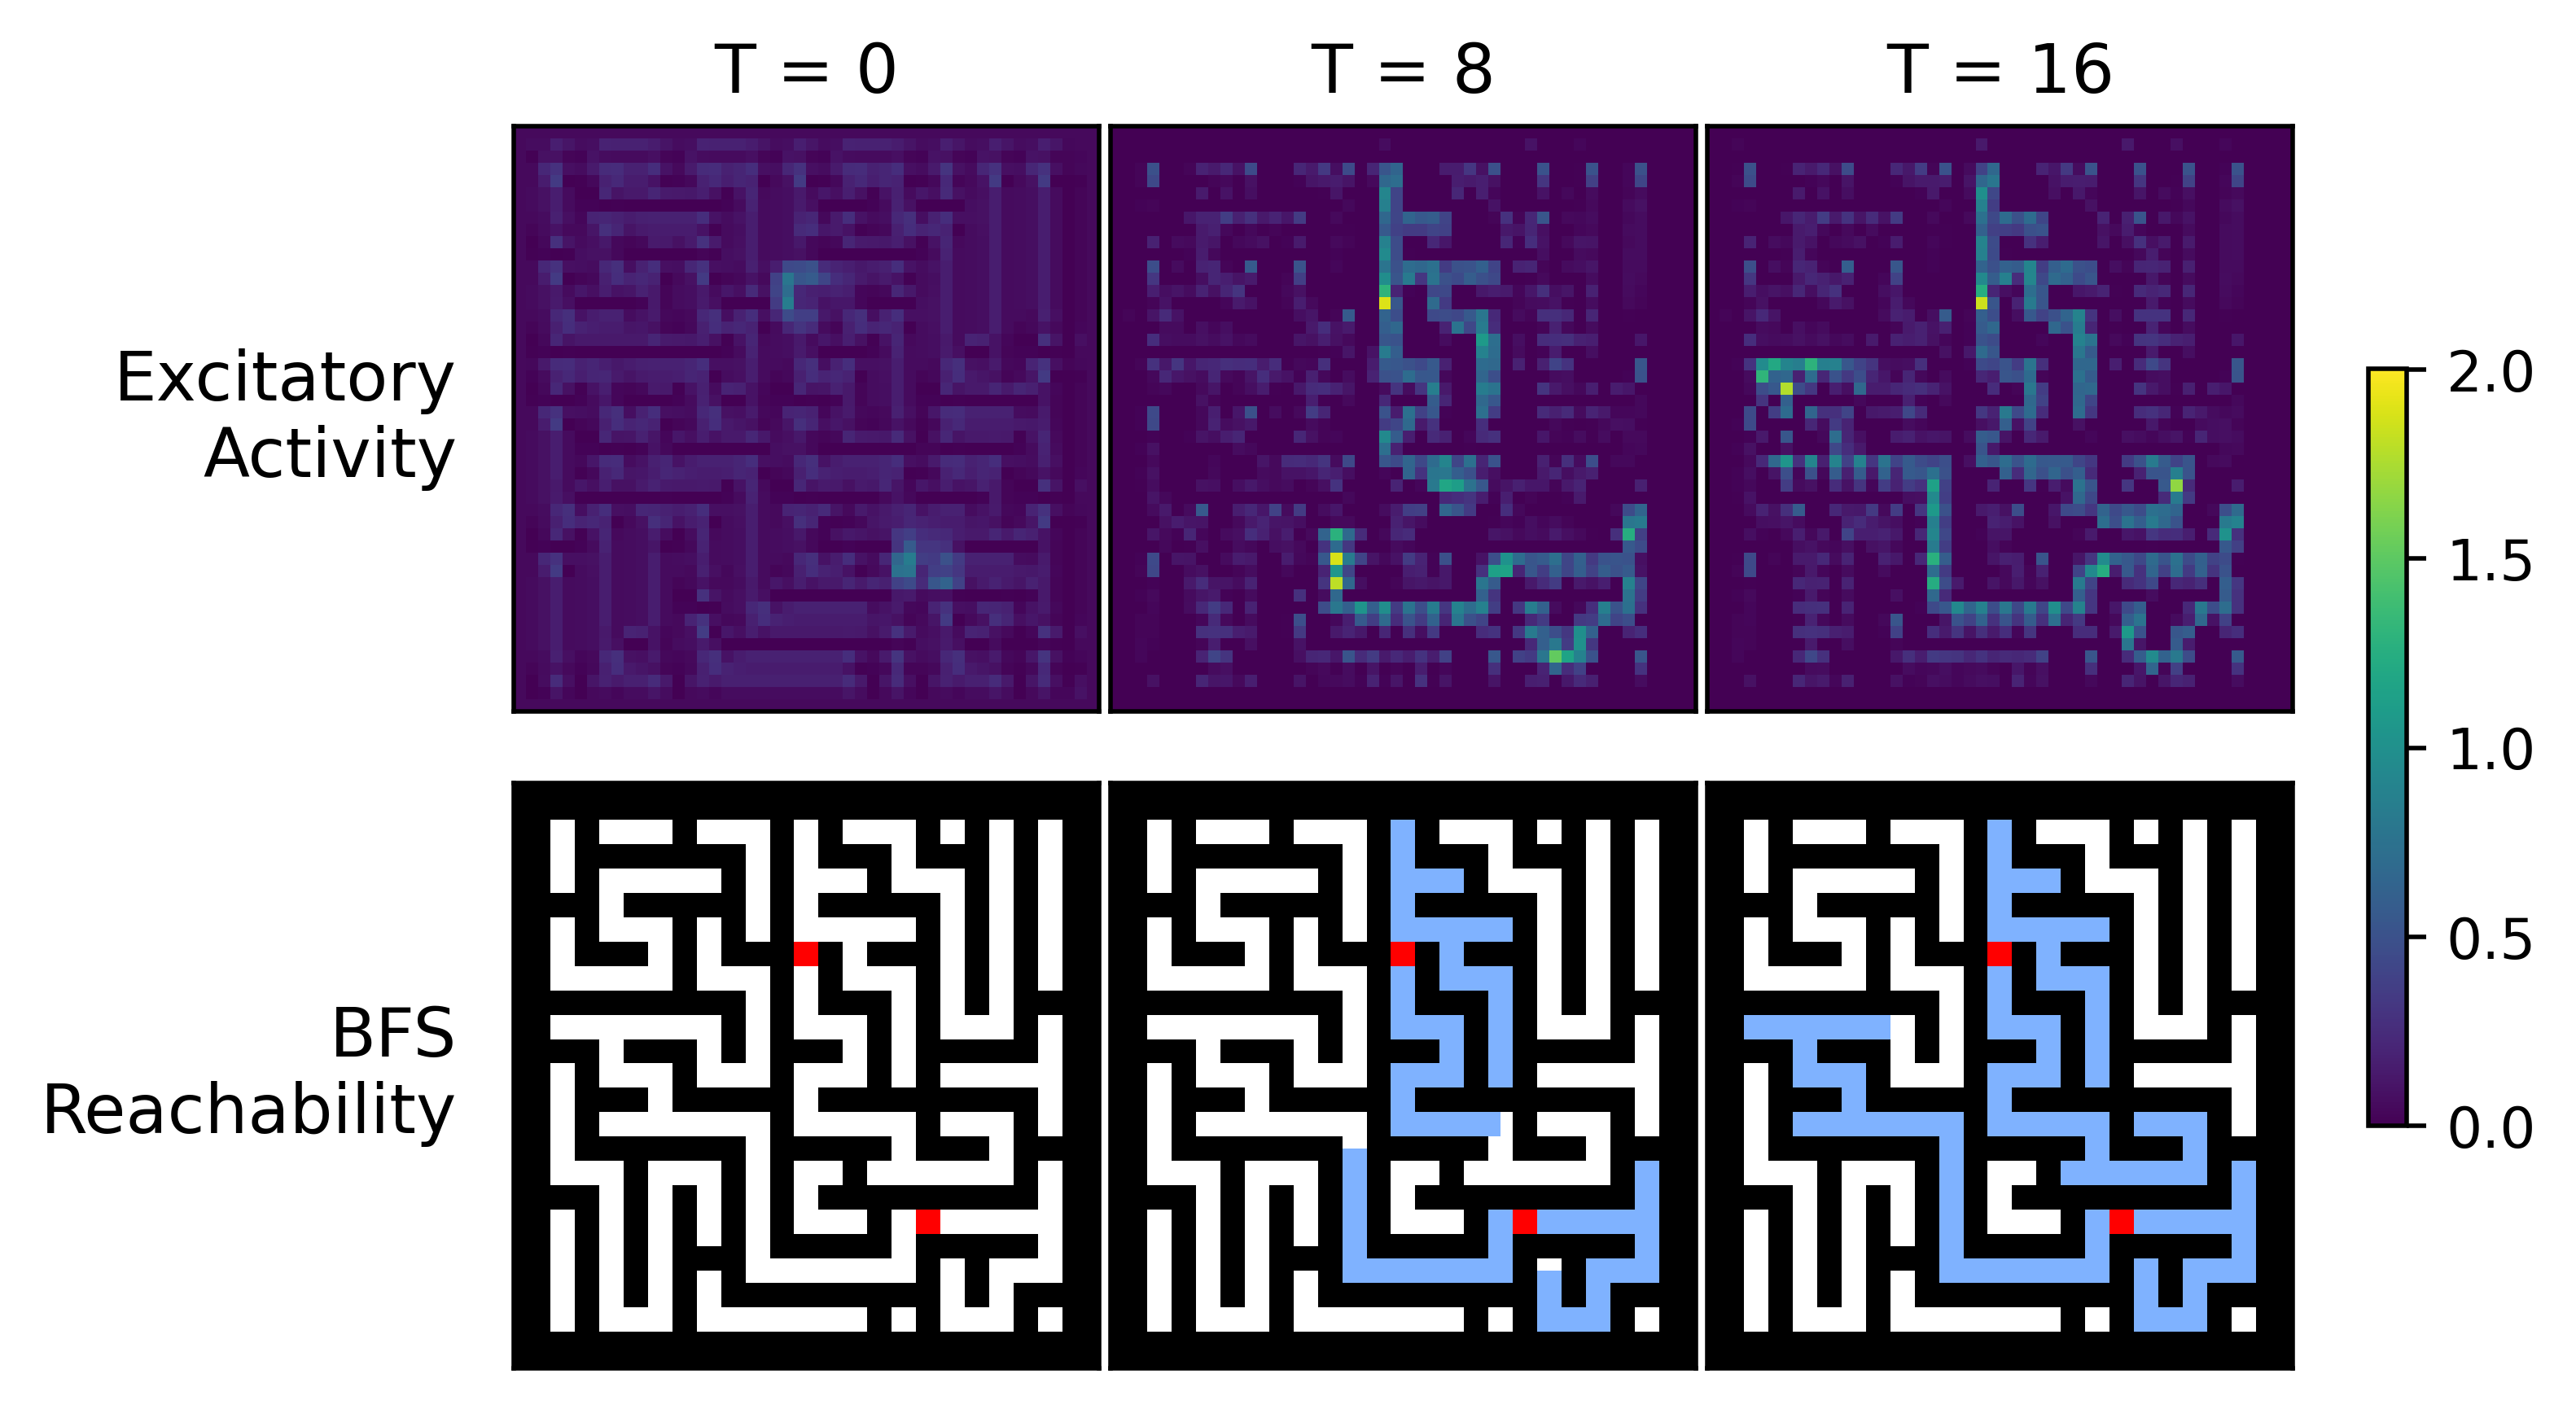

In [10]:
# ——— Plot settings ———
excitatory = True
n, m = 1, 3  # activity grid dims
sigma_filter = 1.0  # optional blur for weights
channels_to_plot = np.arange(8)
sample_indices = [12, 13]
do_highlight_self_kernel = False
num_steps = 17

inputs = test_loader.dataset  # pyright: ignore[reportOptionalMemberAccess]

# Main plotting loop
for plot_idx, sample_idx in enumerate(sample_indices):
    inp, label = inputs[sample_idx][0], inputs[sample_idx][1]
    _, neuron_states, _ = model(inp.unsqueeze(0).to(device), num_steps=num_steps)
    activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
               .detach().cpu()[0]  # shape (T, C)
    
    plot_mean_channel_activity(activity, n, m, inp, savepath=os.path.join(save_dir, f"figure_c_activity_bfs_{plot_idx}.svg"))

# Figure D - Comparison to CNN on OOD Inputs

## Generating OOD inputs

In [11]:
def cell_to_pixels(r, c):
    """Map a logical cell (r,c) to the 2×2 pixel block in a 48×48 grid."""
    return [(2*r + dr, 2*c + dc) for dr in (0, 1) for dc in (0, 1)]

def _base_u(cells=24, horiz=8, vert=4):
    """
    Build a 24×24 U‐maze open to the left, centered, with:
      - horizontal arms of length horiz+1
      - vertical connector of span vert+1
    """
    M = np.zeros((cells, cells), dtype=int)
    r0 = (cells - vert) // 2  # top arm row
    c0 = (cells - horiz) // 2 # leftmost column of arms

    M[r0,        c0 : c0 + horiz + 1] = 1
    M[r0 + vert, c0 : c0 + horiz + 1] = 1
    M[r0 : r0 + vert + 1, c0 + horiz] = 1
    return M

# --- helpers ---
def _logical_endpoints(base):
    endpoints = []
    H, W = base.shape
    for r, c in zip(*np.where(base == 1)):
        cnt = sum(
            0 <= r+dr < H and 0 <= c+dc < W and base[r+dr, c+dc] == 1
            for dr, dc in ((1,0),(-1,0),(0,1),(0,-1))
        )
        if cnt == 1:
            endpoints.append((r, c))
    return endpoints

def _ordered_path_through_U(base, ends):
    """Return the unique ordered path (list of (r,c)) along the U from ends[0] to ends[1]."""
    assert len(ends) == 2, "U should have exactly two endpoints"
    H, W = base.shape
    def nbrs(r,c):
        for dr,dc in ((1,0),(-1,0),(0,1),(0,-1)):
            rr, cc = r+dr, c+dc
            if 0 <= rr < H and 0 <= cc < W and base[rr,cc] == 1:
                yield (rr, cc)

    start, goal = ends
    path = [start]
    prev = None
    cur = start
    # Walk along the single path (degree≤2 everywhere)
    while cur != goal:
        candidates = [n for n in nbrs(*cur) if n != prev]
        if not candidates:
            break  # should not happen for a valid U
        nxt = candidates[0] if len(candidates) == 1 else (
            candidates[0] if candidates[0] != prev else candidates[1]
        )
        path.append(nxt)
        prev, cur = cur, nxt
    return path

def _cells_to_pixels(cells):
    return [pix for (r, c) in cells for pix in cell_to_pixels(r, c)]

def _expand_with_preidentified_endpoints(base_post, end_cells_pre):
    wall_cells = [tuple(rc) for rc in np.argwhere(base_post == 1)]
    wall_pixels = _cells_to_pixels(wall_cells)
    endpoint_pixels = _cells_to_pixels(end_cells_pre)
    return wall_pixels, endpoint_pixels

def _ablate_u_segment(base, *, length=None, frac=None, seed=None, protect_endpoints=True):
    """
    Zero out a contiguous segment along the U path.
    Choose via absolute `length` (cells) or `frac` of total path.
    """
    base = base.copy()
    ends = _logical_endpoints(base)
    path = _ordered_path_through_U(base, ends)
    L = len(path)
    if L == 0:
        return base

    if length is None:
        assert frac is not None and 0 < frac <= 1, "Provide length or 0<frac<=1"
        length = max(1, int(round(frac * L)))
    length = max(1, min(length, L))

    rng = np.random.default_rng(seed)

    # Respect endpoint protection by limiting start index range
    start_min = 1 if protect_endpoints else 0
    start_max = (L - length - 1) if protect_endpoints else (L - length)
    if start_max < start_min:
        # If the requested segment is too large to avoid endpoints, shrink it
        length = max(1, (L - 2) if protect_endpoints else L)
        start_max = (L - length - 1) if protect_endpoints else (L - length)
        start_min = min(start_min, start_max)

    start_idx = int(rng.integers(start_min, start_max + 1)) if start_max >= start_min else start_min
    seg = path[start_idx:start_idx + length]

    for rc in seg:
        base[rc] = 0
    return base

# --- U maze builders: endpoints BEFORE ablation; ablate a contiguous U chunk ---
def _apply_u_ablation(base, ablate_u=None, seed=None, protect_endpoints=True):
    if ablate_u is None or ablate_u == 0:
        return base
    if isinstance(ablate_u, int):
        return _ablate_u_segment(base, length=ablate_u, seed=seed, protect_endpoints=protect_endpoints)
    if isinstance(ablate_u, float):
        return _ablate_u_segment(base, frac=ablate_u, seed=seed, protect_endpoints=protect_endpoints)
    if isinstance(ablate_u, dict):
        mode = ablate_u.get('mode', 'segment')
        if mode != 'segment':
            raise ValueError("Only 'segment' mode is supported for U-specific ablation.")
        length = ablate_u.get('length', None)
        frac   = ablate_u.get('frac', None)
        seed   = ablate_u.get('seed', seed)
        protect = ablate_u.get('protect_endpoints', protect_endpoints)
        return _ablate_u_segment(base, length=length, frac=frac, seed=seed, protect_endpoints=protect)
    raise ValueError("ablate_u must be int (length), float (frac), or dict")

def maze_right(arm=12, vert=4, ablate_u=None, seed=None, protect_endpoints=True):
    base = _base_u(24, arm, vert)
    ends_pre = _logical_endpoints(base)
    base_post = _apply_u_ablation(base, ablate_u, seed, protect_endpoints)
    return _expand_with_preidentified_endpoints(base_post, ends_pre)

def maze_left(arm=12, vert=4, ablate_u=None, seed=None, protect_endpoints=True):
    base = np.fliplr(_base_u(24, arm, vert))
    ends_pre = _logical_endpoints(base)
    base_post = _apply_u_ablation(base, ablate_u, seed, protect_endpoints)
    return _expand_with_preidentified_endpoints(base_post, ends_pre)

def maze_up(arm=12, vert=4, ablate_u=None, seed=None, protect_endpoints=True):
    base = np.rot90(_base_u(24, arm, vert), k=1)
    ends_pre = _logical_endpoints(base)
    base_post = _apply_u_ablation(base, ablate_u, seed, protect_endpoints)
    return _expand_with_preidentified_endpoints(base_post, ends_pre)

def maze_down(arm=12, vert=4, ablate_u=None, seed=None, protect_endpoints=True):
    base = np.rot90(_base_u(24, arm, vert), k=-1)
    ends_pre = _logical_endpoints(base)
    base_post = _apply_u_ablation(base, ablate_u, seed, protect_endpoints)
    return _expand_with_preidentified_endpoints(base_post, ends_pre)

def connected_staircase_length(n=24, length=3, corner="tl", as_torch=False, dtype=np.uint8):
    """
    Build an n×n grid with a connected staircase:
      vertical segment of exactly `length` cells,
      then horizontal segment of exactly `length` cells,
      repeating until the grid edge is reached.
    The corner cell is shared between consecutive segments.

    Parameters
    ----------
    n : int
        Grid size (n×n).
    length : int
        Arm length (cells) for both vertical and horizontal segments (>=1).
        Each segment includes its starting corner cell.
    corner : {'tl','tr','bl','br'}
        Starting corner. The staircase moves inward:
          tl: down, then right (main-diagonal direction)
          tr: down, then left
          bl: up,   then right
          br: up,   then left
    as_torch : bool
        If True, return torch.FloatTensor; else NumPy array.
    dtype : np.dtype
        NumPy dtype when as_torch=False.

    Returns
    -------
    grid : np.ndarray or torch.Tensor
        n×n with 1s for the staircase and 0s elsewhere.
    """
    if length < 1:
        raise ValueError("length must be >= 1")

    g = np.zeros((n, n), dtype=dtype)

    # Start and directions
    if corner == "tl":
        r, c = 0, 0; v_down, h_right = True, True
    elif corner == "tr":
        r, c = 0, n-1; v_down, h_right = True, False
    elif corner == "bl":
        r, c = n-1, 0; v_down, h_right = False, True
    elif corner == "br":
        r, c = n-1, n-1; v_down, h_right = False, False
    else:
        raise ValueError("corner must be one of {'tl','tr','bl','br'}")

    def draw_vertical(r0, c0, L, down=True):
        """Draw L cells including (r0,c0). Return new (r,c) at far tip."""
        if down:
            r1 = min(n-1, r0 + (L - 1))
            g[r0:r1+1, c0] = 1
            return r1, c0
        else:
            r1 = max(0, r0 - (L - 1))
            g[r1:r0+1, c0] = 1
            return r1, c0

    def draw_horizontal(r0, c0, L, right=True):
        """Draw L cells including (r0,c0). Return new (r,c) at far tip."""
        if right:
            c1 = min(n-1, c0 + (L - 1))
            g[r0, c0:c1+1] = 1
            return r0, c1
        else:
            c1 = max(0, c0 - (L - 1))
            g[r0, c1:c0+1] = 1
            return r0, c1

    # Build connected Ls until neither segment adds anything new
    while True:
        r_prev, c_prev = r, c
        r, c = draw_vertical(r, c, length, down=v_down)
        r, c = draw_horizontal(r, c, length, right=h_right)

        # Stop if the tip didn't move (we're pinned at borders)
        if (r, c) == (r_prev, c_prev):
            break

    return torch.from_numpy(g.astype(np.float32))
    return g

base_input = np.zeros((24,24))

In [24]:
def plot_accuracies(bioplnn_accuracies_pos, cnn_accuracies_pos, bioplnn_accuracies_neg, cnn_accuracies_neg, savepath=None):
    labels = ['BioPLNN', 'CNN']
    pos_accuracies = [bioplnn_accuracies_pos, cnn_accuracies_pos]
    neg_accuracies = [bioplnn_accuracies_neg, cnn_accuracies_neg]

    x = np.arange(len(labels))
    width = 0.35

    # Define custom colors: light blue and light greenish yellow
    light_blue = "#a3c9f7"  # BFS fill blue (same as used above)
    light_green_yellow = "#95DB88"

    fig, ax = plt.subplots()
    rects1 = ax.bar(x - width/2, pos_accuracies, width, label='Positive', color=light_blue)
    rects2 = ax.bar(x + width/2, neg_accuracies, width, label='Negative', color=light_green_yellow)

    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Classifier Accuracy by Model and Condition', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12)
    ax.legend(fontsize=12)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    plt.ylim(0, 1.10)
    if savepath is not None:
        fig.savefig(savepath, format='svg', bbox_inches='tight')
    plt.show()

## U-Shape Inputs

In [13]:
def evaluate_classifier(classifier, steps_range, ablate=False):
    accuracies = []
    failed_inputs = []
    classifier.to(device)
    for num_steps in steps_range:
        num_correct, total = 0, 0
        for arm in range(7, 15):
            for vert in range(7, 15):
                ablate_us = [3,4,5,6] if ablate else [None]
                seeds = range(1, 6) if ablate else [None]  # seeds 1-10
                for ablate_u in ablate_us:
                    for seed in seeds:
                        for fn in (maze_left, maze_right, maze_up, maze_down):
                            kwargs = dict(arm=arm, vert=vert)
                            if ablate:
                                kwargs.update(dict(ablate_u=ablate_u, seed=seed))
                            wall_pixels, input_pixels = fn(**kwargs)
                            wall_rows, wall_cols = zip(*wall_pixels)
                            input_rows, input_cols = zip(*input_pixels)
                            walls = base_input.copy().repeat(2, axis=0).repeat(2, axis=1)
                            walls[wall_rows, wall_cols] = 1
                            walls = np.stack([walls]*3, axis=0)
                            points = base_input.copy().repeat(2, axis=0).repeat(2, axis=1)
                            points[input_rows, input_cols] = 1
                            points = points[np.newaxis, ...]
                            inp_np = np.concatenate([walls, points], axis=0)
                            inp = torch.tensor(inp_np, dtype=torch.float32).to(device)
                            if "CNN" in classifier.__class__.__name__:
                                pred = classifier(inp.unsqueeze(0))
                            else:
                                pred, *_ = classifier(inp.unsqueeze(0), num_steps=num_steps, ablater=None if not ablate else None, return_activations=True)
                            correct_label = 0 if ablate else 1
                            if pred.argmax(dim=1).item() == correct_label:
                                num_correct += 1
                            else:
                                failed_inputs.append(kwargs)
                            total += 1
        acc = num_correct / total
        accuracies.append(acc)
    return accuracies, failed_inputs

In [14]:
# Run for normal and ablation conditions
bioplnn_accuracies_pos, _ = evaluate_classifier(classifier, [20], ablate=False)
bioplnn_accuracies_neg, f = evaluate_classifier(classifier, [20], ablate=True)

cnn_accuracies_pos, _ = evaluate_classifier(cnn_classifier, [20], ablate=False)
cnn_accuracies_neg, _ = evaluate_classifier(cnn_classifier, [20], ablate=True)

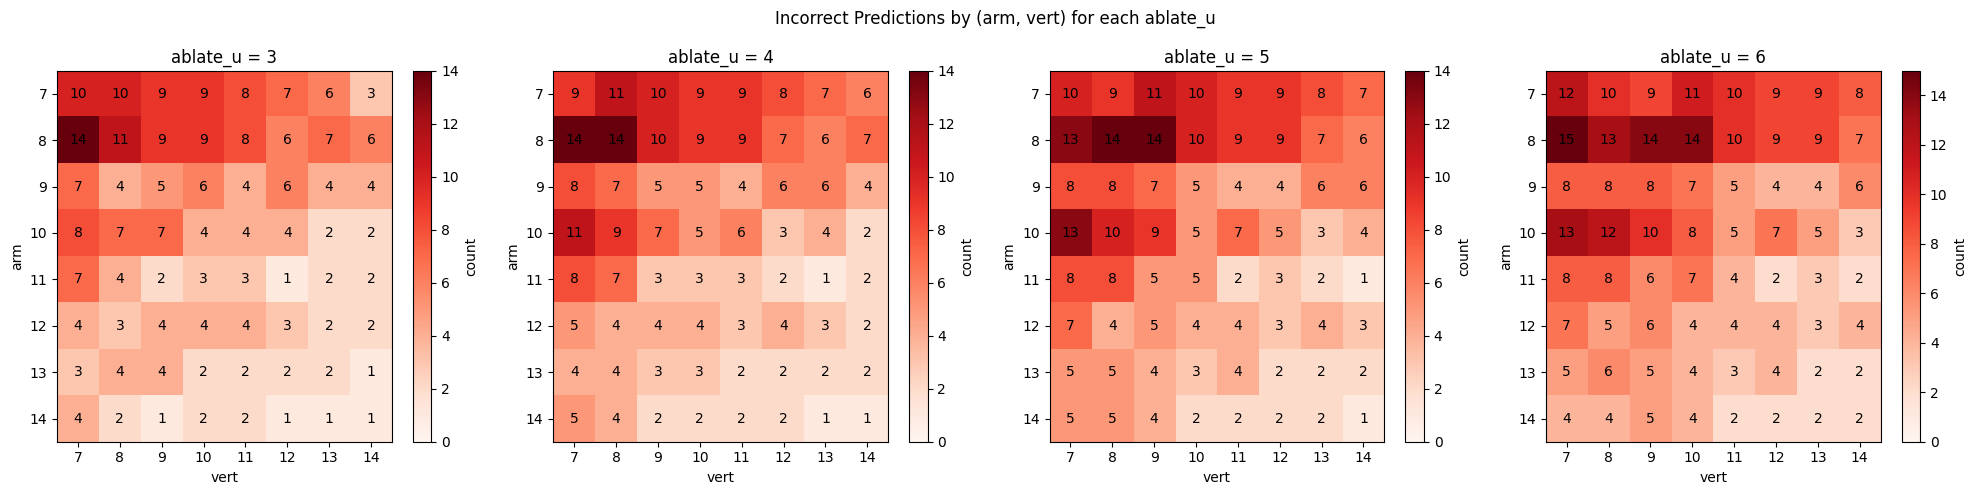

In [19]:
df = pd.DataFrame(f)

# Get unique values
ablate_u_vals = sorted(df['ablate_u'].unique())
arm_vals = sorted(df['arm'].unique())
vert_vals = sorted(df['vert'].unique())

fig, axes = plt.subplots(1, len(ablate_u_vals), figsize=(5 * len(ablate_u_vals), 5), squeeze=False)

for i, ablate_u in enumerate(ablate_u_vals):
    ax = axes[0, i]
    subset = df[df['ablate_u'] == ablate_u]
    
    # Create count matrix
    counts = subset.groupby(['arm', 'vert']).size().unstack(fill_value=0)
    counts = counts.reindex(index=arm_vals, columns=vert_vals, fill_value=0)
    
    im = ax.imshow(counts.values, cmap='Reds', aspect='auto', vmin=0)
    ax.set_xticks(range(len(vert_vals)))
    ax.set_xticklabels(vert_vals)
    ax.set_yticks(range(len(arm_vals)))
    ax.set_yticklabels(arm_vals)
    ax.set_xlabel('vert')
    ax.set_ylabel('arm')
    ax.set_title(f'ablate_u = {ablate_u}')
    
    # Add count annotations
    for y in range(len(arm_vals)):
        for x in range(len(vert_vals)):
            val = counts.values[y, x]
            if val > 0:
                ax.text(x, y, str(val), ha='center', va='center', fontsize=10, color='black')
    
    plt.colorbar(im, ax=ax, label='count')

plt.suptitle('Incorrect Predictions by (arm, vert) for each ablate_u')
plt.tight_layout()
plt.show()

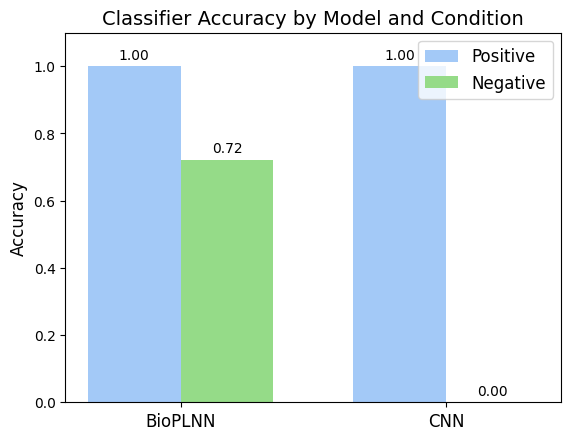

In [20]:
plot_accuracies(bioplnn_accuracies_pos, cnn_accuracies_pos, bioplnn_accuracies_neg, cnn_accuracies_neg, savepath=os.path.join(save_dir, "figure_d_ushape_accuracy.svg"))

## Staircase Inputs

In [15]:
def flip_random_connected_n(grid, n, rng=None, max_tries=500, in_place=False):
    """
    Zero out a random connected (4-neighbor) cluster of EXACTLY n cells that are 1s.
    If the sampled component has < n cells, retry with another start (up to max_tries).

    Parameters
    ----------
    grid : (H,W) np.ndarray of {0,1}
    n : int                   # target cluster size (>=1)
    rng : np.random.Generator # optional
    max_tries : int
    in_place : bool

    Returns
    -------
    out : np.ndarray
        Grid with the chosen n connected 1s flipped to 0s (or unchanged if impossible).
    """
    if rng is None:
        rng = np.random.default_rng()
    if n < 1:
        raise ValueError("n must be >= 1")
    H, W = grid.shape
    ones = np.argwhere(grid == 1)
    if ones.shape[0] < n:
        return grid if in_place else grid.copy()

    out = grid if in_place else grid.copy()

    def bfs_pick_n(r0, c0):
        """BFS within 1-cells; return list of up to n coords in one connected component."""
        if out[r0, c0] != 1:
            return []
        picked = []
        visited = np.zeros((H, W), dtype=bool)
        q = [(r0, c0)]
        visited[r0, c0] = True
        while q and len(picked) < n:
            r, c = q.pop(0)
            if out[r, c] == 1:
                picked.append((r, c))
                # enqueue 4-neighbors
                if r > 0   and not visited[r-1, c]: visited[r-1, c] = True; q.append((r-1, c))
                if r < H-1 and not visited[r+1, c]: visited[r+1, c] = True; q.append((r+1, c))
                if c > 0   and not visited[r, c-1]: visited[r, c-1] = True; q.append((r, c-1))
                if c < W-1 and not visited[r, c+1]: visited[r, c+1] = True; q.append((r, c+1))
        return picked

    # Try random starts until we find a component with at least n cells
    for _ in range(max_tries):
        r0, c0 = ones[rng.integers(len(ones))]
        picked = bfs_pick_n(r0, c0)
        if len(picked) == n:
            for r, c in picked:
                out[r, c] = 0
            return out
        # If component larger than n, we still returned exactly n via BFS order (connected).
        # If smaller, try another start.
    # If we couldn't find any component with >= n cells, return unchanged
    return out.to_numpy()

In [16]:
def evaluate_staircase_classifier(classifier, device, ablate=False, steps_to_plot=[20], show_plots=False):
    """
    Evaluate classifier accuracy on staircase variants for given steps.

    Args:
        classifier: The model to evaluate.
        device: Torch device.
        ablate: Whether to ablate (flip) 2 random connected wall cells.
        steps_to_plot: Iterable of num_steps to evaluate.
        show_plots: If True, show input images.

    Returns:
        List of accuracies for each num_steps in steps_to_plot.
    """
    accuracies = []
    classifier.to(device)

    for num_steps in steps_to_plot:
        num_correct = 0
        total = 0
        for corner in ["br", "tr", "bl", "tl"]:
            for length in [2, 3, 4, 5]:
                for ablate_size in [2, 3, 4, 5]:
                    seeds = range(1, 6) if ablate else [None]
                    for seed in seeds:
                        walls = connected_staircase_length(n=24, length=length, corner=corner).numpy()
                        if ablate:
                            rng = np.random.default_rng(seed)
                            walls = flip_random_connected_n(walls, ablate_size, rng=rng)
                        walls = walls.repeat(2, axis=0).repeat(2, axis=1)
                    walls = np.stack([walls, walls, walls], axis=0)

                    points = np.zeros((24, 24))
                    if corner == "tr" or corner == "bl":
                        points[-1, 0] = 1
                        points[0, -1] = 1
                    else:
                        points[0, 0] = 1
                        points[-1, -1] = 1

                    points = points.repeat(2, axis=0).repeat(2, axis=1)
                    points = points[np.newaxis, ...]

                    # combine
                    inp = np.concatenate([walls, points], axis=0)
                    if show_plots:
                        plt.imshow(inp[0] + inp[-1]*2)
                        plt.show()

                    inp = torch.tensor(inp, dtype=torch.float32).to(device)

                    if "CNN" in classifier.__class__.__name__:
                        pred = classifier(inp.unsqueeze(0))
                    else:
                        pred, outs, neuron_states, fbs = classifier(
                            inp.unsqueeze(0), num_steps=num_steps, ablater=None, return_activations=True
                        )

                    correct_label = 0 if ablate else 1
                    correct = (pred.argmax(dim=1).item() == correct_label)
                    if correct:
                        num_correct += 1
                    total += 1

                    if not ablate:
                        break

        accuracy = num_correct / total
        accuracies.append(accuracy)
    return accuracies

In [22]:
bioplnn_accuracies_pos, _ = evaluate_classifier(classifier, [20], ablate=False)
bioplnn_accuracies_neg, f = evaluate_classifier(classifier, [20], ablate=True)

cnn_accuracies_pos, _ = evaluate_classifier(cnn_classifier, [20], ablate=False)
cnn_accuracies_neg, _ = evaluate_classifier(cnn_classifier, [20], ablate=True)

biolnn_pos_accuracies_staircase = evaluate_staircase_classifier(classifier, device, ablate=False, steps_to_plot=[20])
biolnn_neg_accuracies_staircase = evaluate_staircase_classifier(classifier, device, ablate=True, steps_to_plot=[20])

cnn_pos_accuracies_staircase = evaluate_staircase_classifier(cnn_classifier, device, ablate=False, steps_to_plot=[20])
cnn_neg_accuracies_staircase = evaluate_staircase_classifier(cnn_classifier, device, ablate=True, steps_to_plot=[20])

bioplnn_accuracies_pos = (bioplnn_accuracies_pos[0] + biolnn_pos_accuracies_staircase[0]) / 2
bioplnn_accuracies_neg = (bioplnn_accuracies_neg[0] + biolnn_neg_accuracies_staircase[0]) / 2
cnn_accuracies_pos = (cnn_accuracies_pos[0] + cnn_pos_accuracies_staircase[0]) / 2
cnn_accuracies_neg = (cnn_accuracies_neg[0] + cnn_neg_accuracies_staircase[0]) / 2

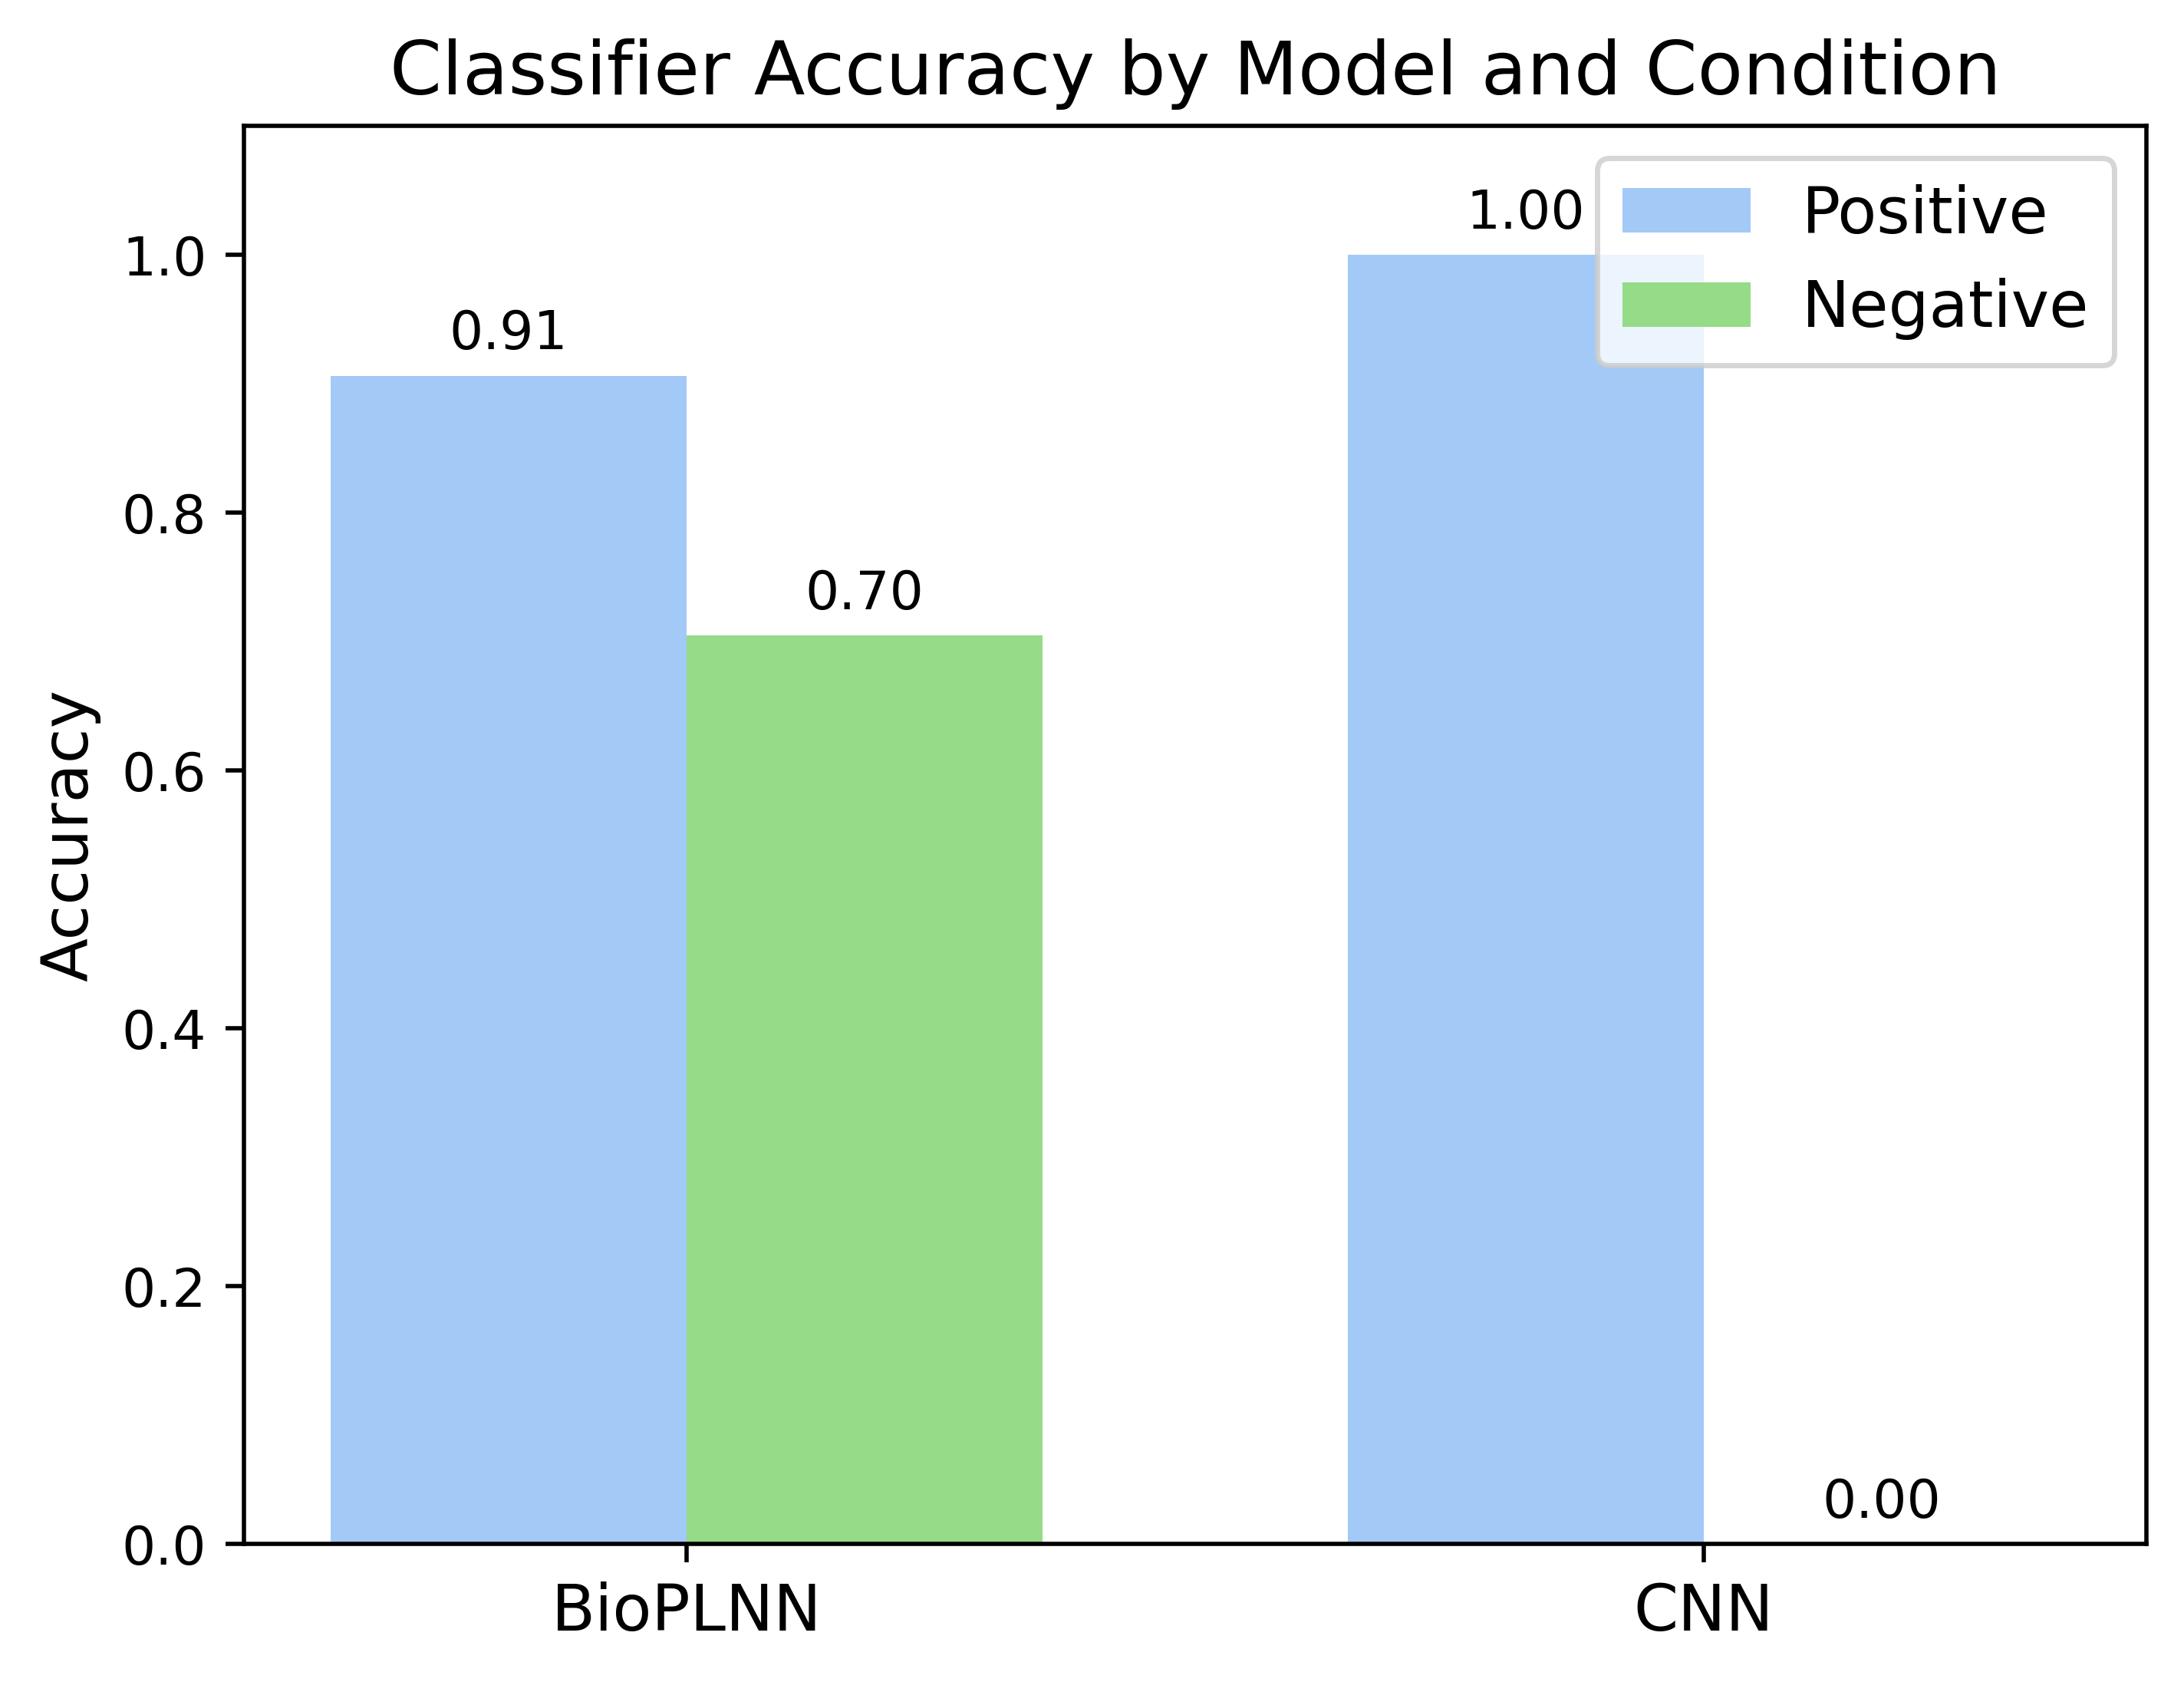

In [26]:
plot_accuracies(bioplnn_accuracies_pos, cnn_accuracies_pos, bioplnn_accuracies_neg, cnn_accuracies_neg, savepath=os.path.join(save_dir, "figure_d_accuracy.svg"))

## Plotting Different Mazes

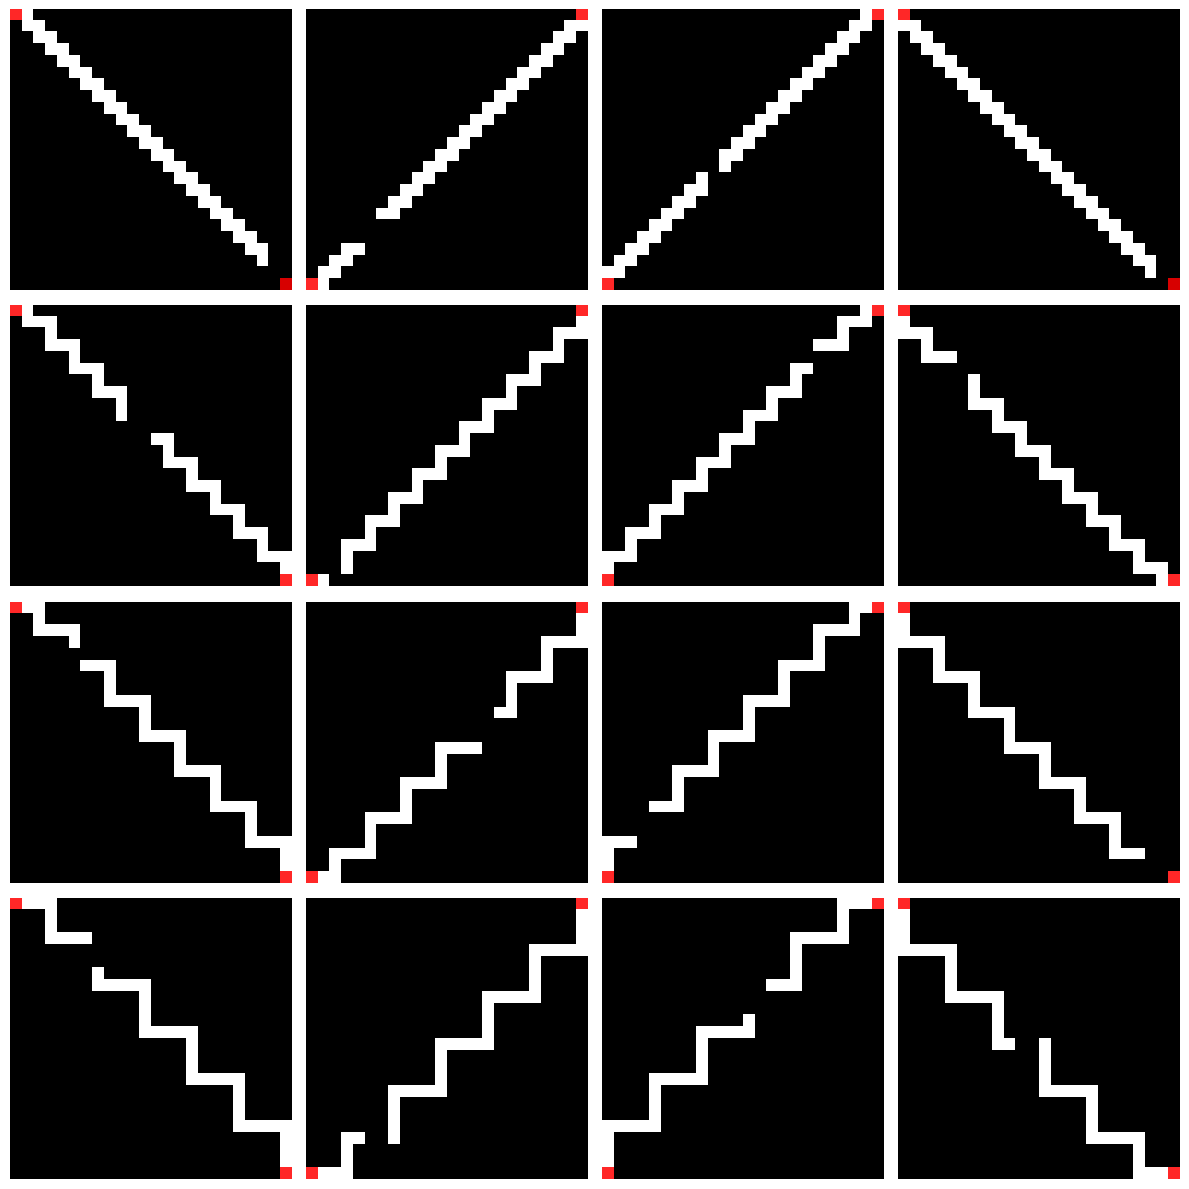

In [ ]:
# Plot all maze variants in a big grid
arms = [6, 14]
verts = [6, 12]
maze_fns = [maze_left, maze_right, maze_up, maze_down]
n_rows = len(maze_fns)
n_cols = len(arms) * len(verts)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows), squeeze=False)

col_idx = 0
for arm in arms:
    for vert in verts:
        for row_idx, fn in enumerate(maze_fns):
            # predesigned input
            wall_pixels, input_pixels = fn(arm=arm, vert=vert, ablate_u=random.randint(4, 7))
            wall_rows, wall_cols = zip(*wall_pixels)
            input_rows, input_cols = zip(*input_pixels)
            walls = base_input.copy()
            walls = walls.repeat(2, axis=0).repeat(2, axis=1)
            walls[wall_rows, wall_cols] = 1
            walls = np.stack([walls, walls, walls], axis=0)
            points = base_input.copy()
            points = points.repeat(2, axis=0).repeat(2, axis=1)
            points[input_rows, input_cols] = 1
            points = points[np.newaxis, ...]

            # combine
            inp_np = np.concatenate([walls, points], axis=0)
            inp = torch.tensor(inp_np, dtype=torch.float32)

            bg   = inp_np[0]
            over = inp_np[-1]

            ax = axs[row_idx, col_idx]
            ax.imshow(bg, cmap='gray', interpolation='none')

            over_norm = over.astype(float)
            vmax_o, vmin_o = np.nanmax(over_norm), np.nanmin(over_norm)
            over_norm = (over_norm - vmin_o) / (vmax_o - vmin_o) if vmax_o > vmin_o else np.zeros_like(over_norm)

            rgba = np.zeros((*over_norm.shape, 4), dtype=float)
            rgba[..., 0] = 1.0
            rgba[..., 3] = over_norm * 0.85
            ax.imshow(rgba, interpolation='none')

            ax.axis('off')
        col_idx += 1

plt.tight_layout()
fig.savefig(os.path.join(save_dir, "figure_d_ushape_grid.svg"), format='svg', bbox_inches='tight')
plt.show()


n_rows = 4
n_cols = 4

fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows), squeeze=False)

col_idx = 0
for corner in ["br", "tr", "bl", "tl"]:
    for row_idx, length in enumerate([2, 3, 4, 5]):
        walls = connected_staircase_length(n=24, length=length, corner=corner).numpy()
        walls = flip_random_connected_n(walls, np.random.randint(2, 5))
        walls = walls.repeat(2, axis=0).repeat(2, axis=1)
        walls = np.stack([walls, walls, walls], axis=0)

        points = np.zeros((24, 24))
        if corner == "tr" or corner == "bl":
            points[-1, 0] = 1
            points[0, -1] = 1
        else:
            points[0, 0] = 1
            points[-1, -1] = 1

        points = points.repeat(2, axis=0).repeat(2, axis=1)
        points = points[np.newaxis, ...]

        #combine
        inp = np.concatenate([walls, points], axis=0)

        bg   = inp[0]
        over = inp[-1]

        ax = axs[row_idx, col_idx]
        ax.imshow(bg, cmap='gray', interpolation='none')

        over_norm = over.astype(float)
        vmax_o, vmin_o = np.nanmax(over_norm), np.nanmin(over_norm)
        over_norm = (over_norm - vmin_o) / (vmax_o - vmin_o) if vmax_o > vmin_o else np.zeros_like(over_norm)

        rgba = np.zeros((*over_norm.shape, 4), dtype=float)
        rgba[..., 0] = 1.0
        rgba[..., 3] = over_norm * 0.85
        ax.imshow(rgba, interpolation='none')

        ax.axis('off')
    col_idx += 1

plt.tight_layout()
fig.savefig(os.path.join(save_dir, "figure_d_staircase_grid.svg"), format='svg', bbox_inches='tight')
plt.show()

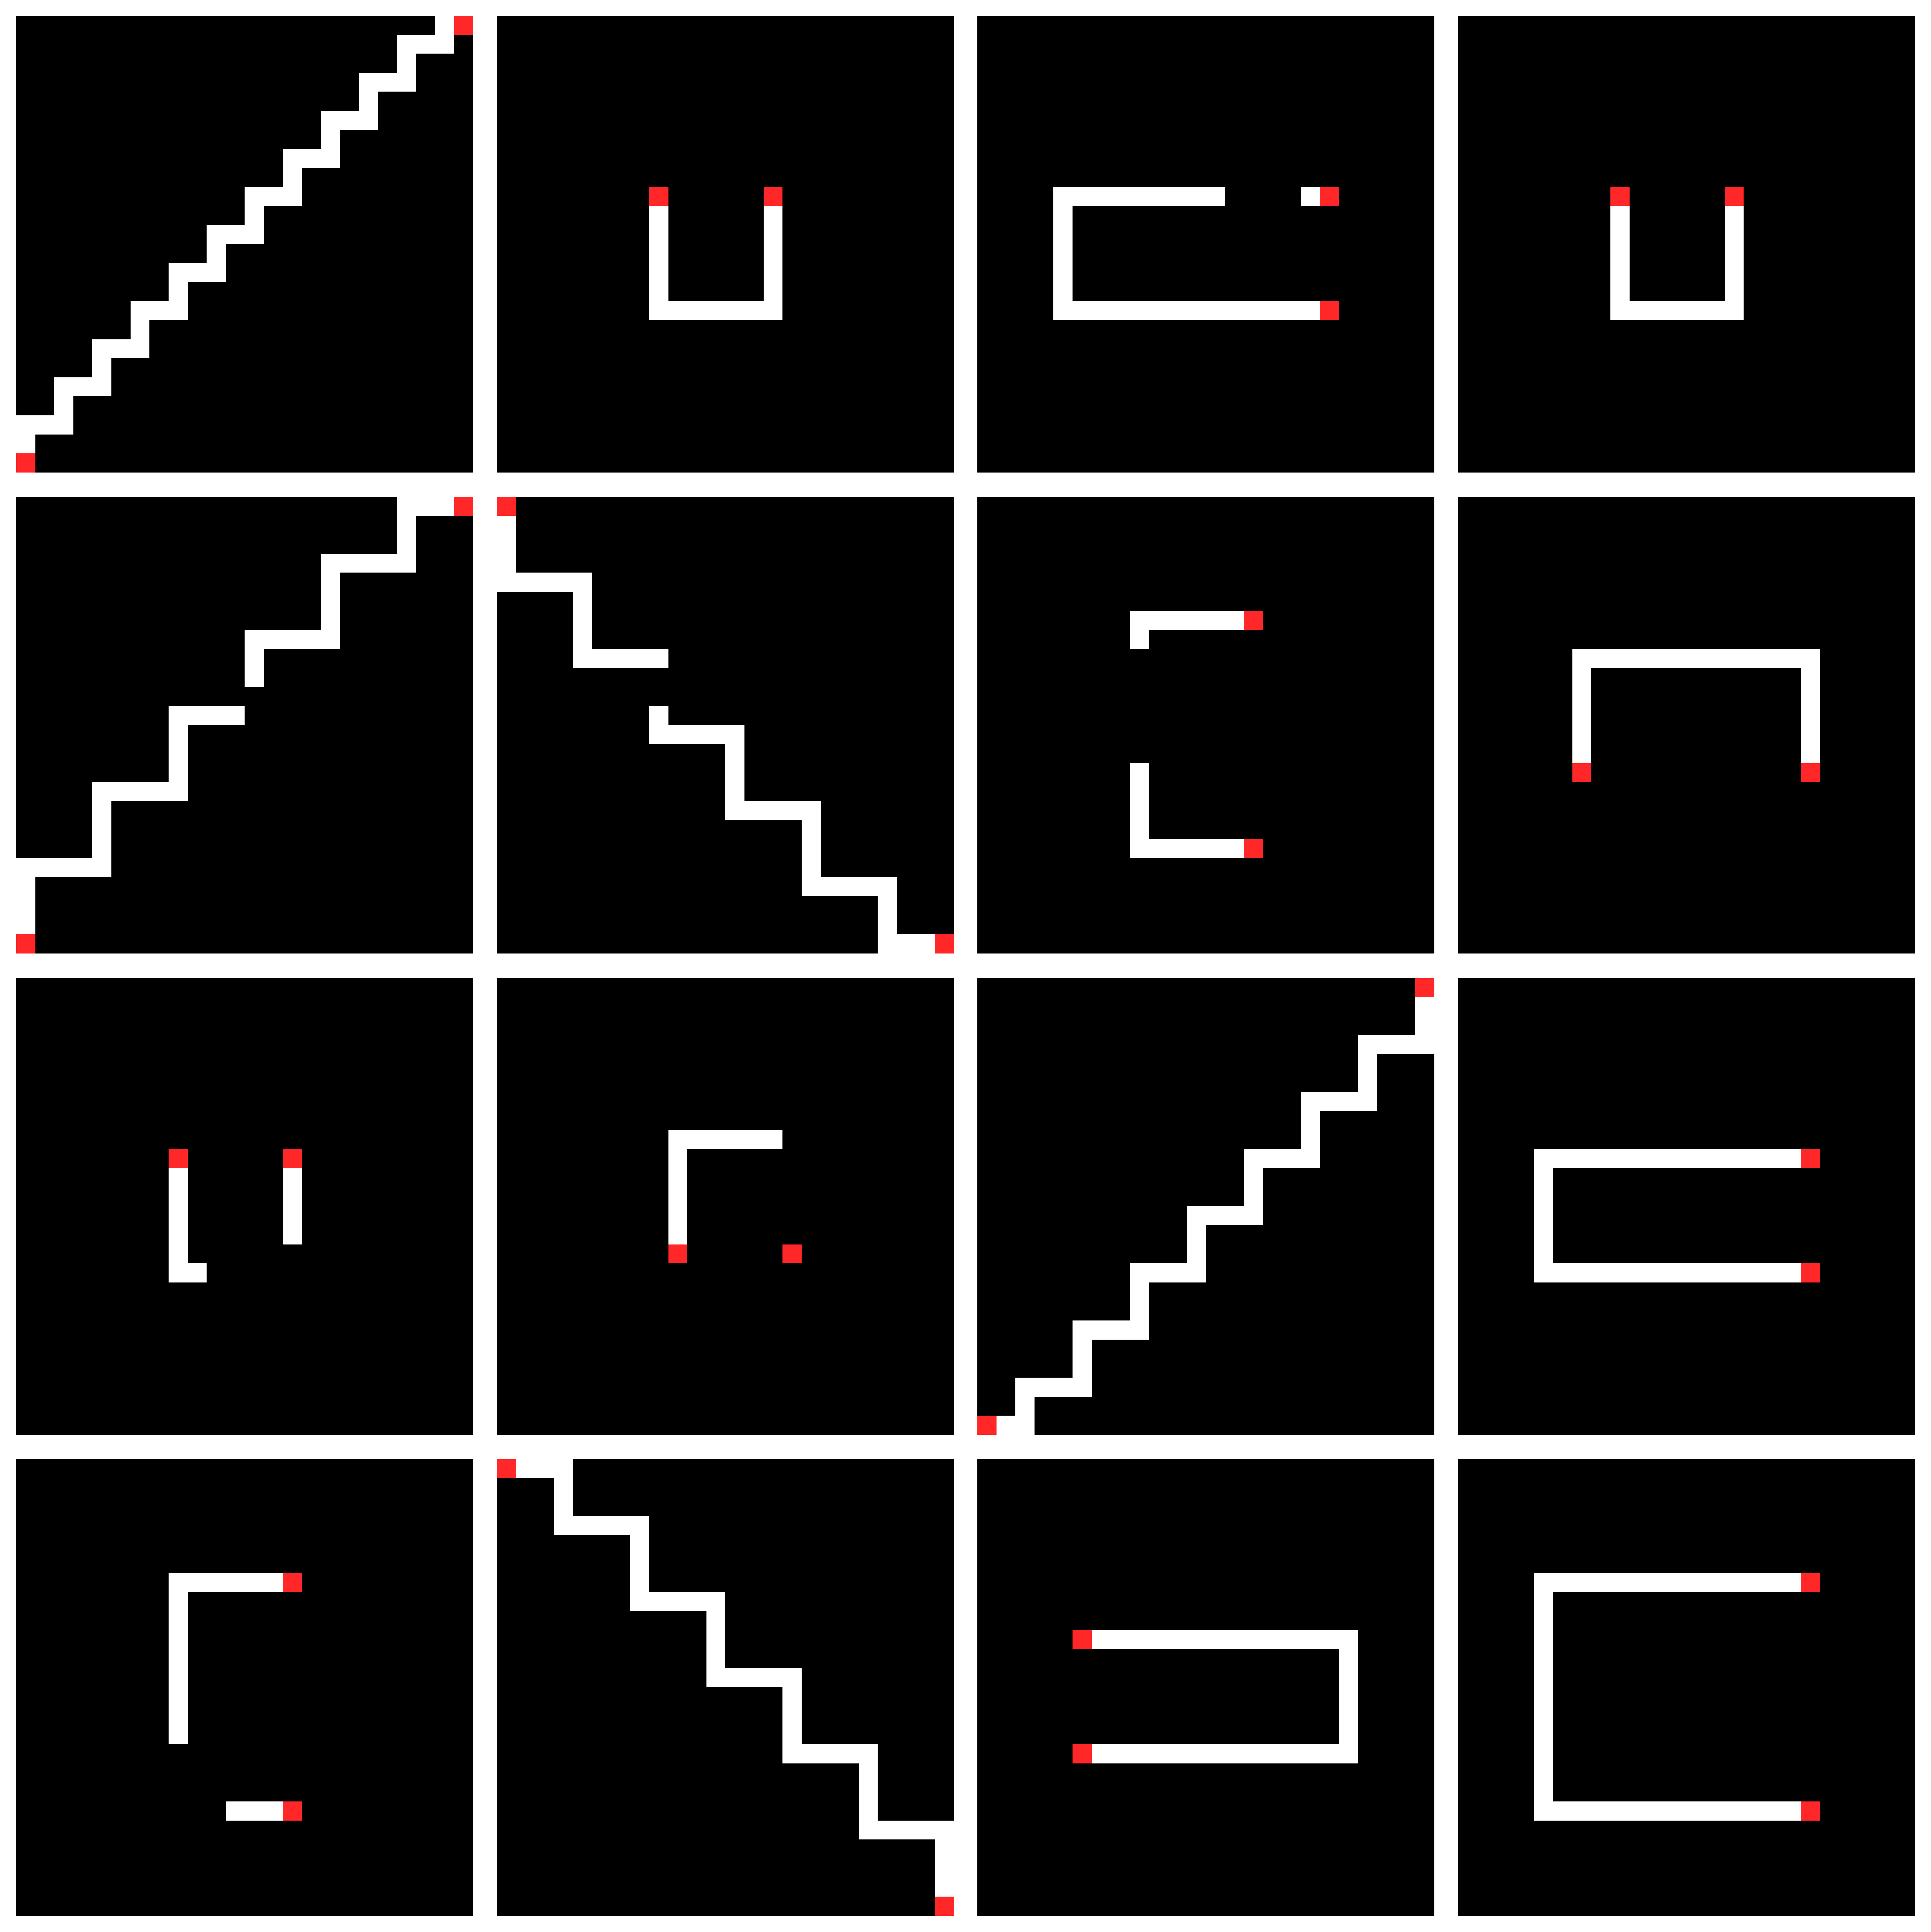

In [37]:
# Combined: sample randomly from BOTH plot-types, but keep the same 4x4 grid size/details

n_rows = 4
n_cols = 4
fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows), squeeze=False)

def draw_overlay(ax, bg, over):
    ax.imshow(bg, cmap="gray", interpolation="none")

    over_norm = over.astype(float)
    vmax_o, vmin_o = np.nanmax(over_norm), np.nanmin(over_norm)
    over_norm = (over_norm - vmin_o) / (vmax_o - vmin_o) if vmax_o > vmin_o else np.zeros_like(over_norm)

    rgba = np.zeros((*over_norm.shape, 4), dtype=float)
    rgba[..., 0] = 1.0
    rgba[..., 3] = over_norm * 0.85
    ax.imshow(rgba, interpolation="none")

    ax.axis("off")

# ----- generators that return (bg, over) in the SAME format as your plotting expects -----

def sample_ushape_example():
    arm = random.choice([6, 14])
    vert = random.choice([6, 12])
    fn = random.choice([maze_left, maze_right, maze_up, maze_down])

    # existing ablation logic, now randomly toggled between "no cut" and "cut"
    ablate_u = 0 if random.random() < 0.5 else random.randint(4, 7)

    wall_pixels, input_pixels = fn(arm=arm, vert=vert, ablate_u=ablate_u)
    wall_rows, wall_cols = zip(*wall_pixels)
    input_rows, input_cols = zip(*input_pixels)

    walls = base_input.copy()
    walls = walls.repeat(2, axis=0).repeat(2, axis=1)
    walls[wall_rows, wall_cols] = 1
    walls = np.stack([walls, walls, walls], axis=0)

    points = base_input.copy()
    points = points.repeat(2, axis=0).repeat(2, axis=1)
    points[input_rows, input_cols] = 1
    points = points[np.newaxis, ...]

    inp_np = np.concatenate([walls, points], axis=0)
    bg, over = inp_np[0], inp_np[-1]
    return bg, over

def sample_staircase_example():
    corner = random.choice(["br", "tr", "bl", "tl"])
    length = random.choice([3, 4, 5])

    walls = connected_staircase_length(n=24, length=length, corner=corner).numpy()
    if random.random() < 0.5:
        walls = flip_random_connected_n(walls, np.random.randint(2, 5))
    walls = walls.repeat(2, axis=0).repeat(2, axis=1)
    walls = np.stack([walls, walls, walls], axis=0)

    points = np.zeros((24, 24))
    if corner == "tr" or corner == "bl":
        points[-1, 0] = 1
        points[0, -1] = 1
    else:
        points[0, 0] = 1
        points[-1, -1] = 1

    points = points.repeat(2, axis=0).repeat(2, axis=1)
    points = points[np.newaxis, ...]

    inp = np.concatenate([walls, points], axis=0)
    bg, over = inp[0], inp[-1]
    return bg, over

samplers = [sample_ushape_example, sample_staircase_example]

# ----- fill the 4x4 grid with random picks from either family -----
for r in range(n_rows):
    for c in range(n_cols):
        bg, over = random.choice(samplers)()
        draw_overlay(axs[r, c], bg, over)

plt.tight_layout()
fig.savefig(os.path.join(save_dir, "figure_d_mixed_grid.svg"), format="svg", bbox_inches="tight")
plt.show()

# Figure E - Euclidean vs Geodesic

In [27]:
def get_decisions(classifier, dataloader, decision_step, device=None):
    if device is None:
        device = next(classifier.parameters()).device

    num_samples = len(dataloader.dataset)
    decisions = np.zeros((num_samples,), dtype=np.int64)

    classifier.eval()
    classifier.to(device)

    sample_idx = 0
    with torch.no_grad():
        for batch_inputs, _labels in tqdm(dataloader):
            bsz = batch_inputs.shape[0]
            batch_inputs = batch_inputs.to(device, non_blocking=True)
            pred = classifier(batch_inputs, num_steps=decision_step)
            dec = torch.argmax(pred, dim=-1).detach().cpu().numpy()
            decisions[sample_idx:sample_idx + bsz] = dec
            sample_idx += bsz

    return decisions

In [28]:
def compute_shortest_path_mask(maze, start_goal):
    """
    BFS shortest path between two single-pixel endpoints.
    maze: 2D array (0=wall, 1=corridor)
    start_goal: 2D array with exactly two nonzero pixels
    Returns: 2D mask with 1s along shortest path (sum = geodesic distance).
    """
    maze = (maze != 0).astype(np.uint8)
    sg = (start_goal != 0).astype(np.uint8)

    pts = np.argwhere(sg == 1)
    if pts.shape[0] != 2:
        return start_goal
    s = tuple(pts[0])
    t = tuple(pts[1])

    maze[s] = 1
    maze[t] = 1

    H, W = maze.shape
    visited = np.zeros_like(maze, dtype=bool)
    parent = -np.ones((H, W, 2), dtype=np.int32)

    nbrs = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]
    q = deque([s])
    visited[s] = True

    found = False
    while q:
        r, c = q.popleft()
        if (r, c) == t:
            found = True
            break
        for dr, dc in nbrs:
            nr, nc = r + dr, c + dc
            if not (0 <= nr < H and 0 <= nc < W):
                continue
            if visited[nr, nc] or maze[nr, nc] != 1:
                continue
            # Block diagonal if both orthogonal neighbors are walls
            if dr != 0 and dc != 0:
                if maze[r + dr, c] == 0 and maze[r, c + dc] == 0:
                    continue
            visited[nr, nc] = True
            parent[nr, nc] = (r, c)
            q.append((nr, nc))

    path_map = np.zeros_like(maze, dtype=np.uint8)
    if not found:
        return path_map

    cur = t
    while True:
        path_map[cur] = 1
        if cur == s:
            break
        pr, pc = parent[cur]
        if pr == -1:
            path_map[:] = 0
            break
        cur = (int(pr), int(pc))

    return path_map.astype(np.uint8)


def collect_shortest_paths(dataloader):
    """Geodesic distance (shortest path length) for each sample."""
    shortest_path_lengths = []
    with torch.no_grad():
        for batch_inputs, _labels in tqdm(dataloader):
            for inp in batch_inputs:
                inp = np.array(inp)
                maze = inp[0]
                start_goal = inp[-1]

                # Downsample: 2x2 cue blocks -> single pixels
                maze = (maze == 1)[::2, ::2]
                start_goal = (start_goal != 0)[::2, ::2]

                shortest_path = compute_shortest_path_mask(maze, start_goal)
                shortest_path_lengths.append(np.sum(shortest_path))

    return np.array(shortest_path_lengths)


def collect_euclidean_distances(dataloader):
    """Euclidean distance between start and goal for each sample."""
    distances = []
    with torch.no_grad():
        for batch_inputs, _labels in tqdm(dataloader):
            for inp in batch_inputs:
                start_goal = inp[-1]

                # Downsample: 2x2 cue blocks -> single pixels
                sg = (start_goal != 0)[::2, ::2]
                rows, cols = np.where(sg)
                pts = np.column_stack((rows, cols))

                if len(pts) != 2:
                    distance = 0
                else:
                    distance = np.sqrt((pts[0][0] - pts[1][0])**2 + (pts[0][1] - pts[1][1])**2)
                distances.append(distance)
    return distances

## Load data

In [29]:
loader, test_loader = initialize_dataloader(
    seed=42, root=maze_data_path, batch_size=256, dataset="mazes", annotation_scaling=3
)

num_samples = 10000
all_indices = np.arange(len(loader.dataset))
subset_indices = np.random.choice(all_indices, size=num_samples, replace=False)
decision_step = 20

subset_dataset = Subset(loader.dataset, subset_indices)
loader = DataLoader(
    subset_dataset,
    batch_size=256,
    shuffle=False,
    drop_last=False
)

## Compute distances and decision points

In [30]:
shortest_path_lengths = collect_shortest_paths(loader)
euclidean_distances = collect_euclidean_distances(loader)

final_decisions = get_decisions(classifier, loader, decision_step)
decision_points = np.zeros(len(loader.dataset)) + 20
for step in range(20, 0, -1):
    decisions = get_decisions(classifier, loader, step)
    for input_idx, decision in enumerate(decisions):
        if decision == final_decisions[input_idx]:
            decision_points[input_idx] = step

  0%|          | 0/40 [00:00<?, ?it/s]

/tmp/ipykernel_2279751/3015672404.py:72: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  inp = np.array(inp)
100%|██████████| 40/40 [00:03<00:00, 12.95it/s]


In [31]:
mask = (final_decisions > 0) & (shortest_path_lengths > 4)

## Time to solve vs Euclidean distance

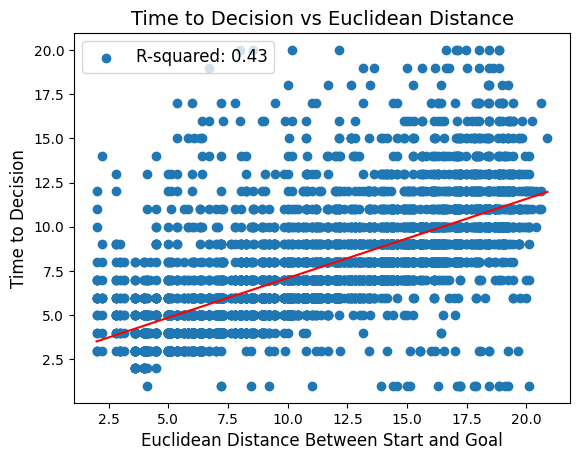

In [32]:
fig, ax = plt.subplots()
ax.scatter(np.array(euclidean_distances)[mask], decision_points[mask])
ax.set_title("Time to Decision vs Euclidean Distance", fontsize=14)
ax.set_ylabel("Time to Decision", fontsize=12)
ax.set_xlabel("Euclidean Distance Between Start and Goal", fontsize=12)
ax.plot(np.unique(np.array(euclidean_distances)[mask]), np.poly1d(np.polyfit(np.array(euclidean_distances)[mask], decision_points[mask], 1))(np.unique(np.array(euclidean_distances)[mask])), color='red')
r_squared = np.corrcoef(np.array(euclidean_distances)[mask], decision_points[mask])[0,1]**2
ax.legend([f"R-squared: {r_squared:.2f}"], loc="best", fontsize=12)
fig.savefig(os.path.join(save_dir, "figure_e_euclidean_vs_time.svg"), format='svg', bbox_inches='tight')
plt.show()

## Time to solve vs Geodesic distance (shortest path)

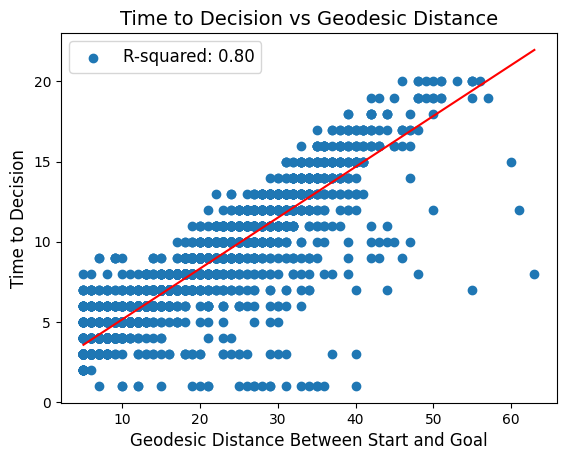

In [33]:
fig, ax = plt.subplots()
ax.scatter(shortest_path_lengths[mask], decision_points[mask])
ax.set_title("Time to Decision vs Geodesic Distance", fontsize=14)
ax.set_ylabel("Time to Decision", fontsize=12)
ax.set_xlabel("Geodesic Distance Between Start and Goal", fontsize=12)
ax.plot(np.unique(np.array(shortest_path_lengths)[mask]), np.poly1d(np.polyfit(np.array(shortest_path_lengths)[mask], decision_points[mask], 1))(np.unique(np.array(shortest_path_lengths)[mask])), color='red')
r_squared = np.corrcoef(np.array(shortest_path_lengths)[mask], decision_points[mask])[0,1]**2
ax.legend([f"R-squared: {r_squared:.2f}"], loc="best", fontsize=12)
fig.savefig(os.path.join(save_dir, "figure_e_geodesic_vs_time.svg"), format='svg', bbox_inches='tight')
plt.show()

# Figure S1 - Kernels

In [34]:
def plot_kernel_grid(
    weights,
    *,
    in_labels=None,
    out_labels=None,
    normalize=True,
    vmin=None,
    vmax=None,
    cmap="seismic",
    figscale=1.0,
    pad=0.1,
    savepath=None,
    show=True,
    title=""
):
    """
    Plot a grid of kernels: cell (i, j) shows kernel from input channel i to output channel j.

    Args:
        weights: Tensor/array of shape (n_out, n_in, kx, ky). Torch or NumPy.
        in_labels: Optional list of length n_in for row labels (input channels).
        out_labels: Optional list of length n_out for column labels (output channels).
        normalize: If True, use symmetric vmin/vmax from global max(|w|).
        vmin, vmax: Optional overrides for color scaling (ignored if normalize=True and these are None).
        cmap: Matplotlib colormap.
        figscale: Scales overall figure size (useful for large channel counts).
        pad: Padding between subplots (in inches).
        savepath: If set, path to save the figure (e.g., "kernels.png").
        show: If True, plt.show() at the end.

    Returns:
        (fig, axes): Matplotlib Figure and Axes array of shape (n_in, n_out).
    """
    # Convert to NumPy
    if isinstance(weights, torch.Tensor):
        W = weights.detach().cpu().numpy()
    else:
        W = np.asarray(weights)

    assert W.ndim == 4, f"Expected (n_out, n_in, kx, ky), got shape {W.shape}"
    n_out, n_in, kx, ky = W.shape

    # Color scale
    if normalize:
        amax = np.abs(W).max()
        vmin_, vmax_ = -amax if amax > 0 else -1.0, amax if amax > 0 else 1.0
    else:
        vmin_ = vmin
        vmax_ = vmax

    # Figure size: a small multiple per cell, scaled
    cell_size = 1.0 * figscale
    fig_w = max(4.0, n_out * cell_size)
    fig_h = max(3.5, n_in  * cell_size)
    fig, axes = plt.subplots(
        n_in, n_out,
        figsize=(fig_w, fig_h),
        squeeze=False
    )

    # Tight layout tweaks
    plt.subplots_adjust(wspace=0.15, hspace=0.15)

    # Plot each kernel slice at (row=i, col=j) = (input i, output j)
    for i in range(n_in):
        for j in range(n_out):
            ax = axes[i, j]
            kern = W[j, i]  # (kx, ky)
            im = ax.imshow(kern, cmap=cmap, vmin=vmin_, vmax=vmax_, origin="upper")
            ax.set_xticks([])
            ax.set_yticks([])
            # light frame
            for spine in ax.spines.values():
                spine.set_linewidth(0.5)
                spine.set_alpha(0.5)

    # Labels on outer edges (optional)
    if out_labels is None:
        out_labels = [f"out {j}" for j in range(n_out)]
    if in_labels is None:
        in_labels = [f"in {i}" for i in range(n_in)]

    # Column titles (top row)
    for j in range(n_out):
        axes[0, j].set_title(out_labels[j], fontsize=12, pad=6)

    # Row labels (leftmost col)
    for i in range(n_in):
        axes[i, 0].set_ylabel(in_labels[i], fontsize=12, rotation=0, labelpad=12, va="center")

    # Shared colorbar (right side)
    # Make a single colorbar using the last imshow handle
    cbar = fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02)
    cbar.ax.tick_params(labelsize=8)

    # Extra padding around the whole figure
    fig.tight_layout(pad=pad)
    fig.suptitle(title, fontsize=14, y=1.04)

    if savepath is not None:
        fig.savefig(savepath, format='svg', bbox_inches="tight")

    if show:
        plt.show()

    return fig, axes


In [35]:
input2e_name = "rnn.areas.0.convs.0->0.0.weight"
input2i_name = "rnn.areas.0.convs.0->1.0.weight"
e2e_name = "rnn.areas.0.convs.1->0.0.weight"
e2i_name = "rnn.areas.0.convs.1->1.0.weight"
i2i_name = "rnn.areas.0.convs.2->1.0.weight"
i2e_name = "rnn.areas.0.convs.2->0.0.weight"

e2e = state_dict[e2e_name].detach().cpu().numpy()
input2e = state_dict[input2e_name].detach().cpu().numpy()
input2i = state_dict[input2i_name].detach().cpu().numpy()
e2i = state_dict[e2i_name].detach().cpu().numpy()
i2i = state_dict[i2i_name].detach().cpu().numpy() * -1 
i2e = state_dict[i2e_name].detach().cpu().numpy() * -1

/tmp/ipykernel_2279751/3602179962.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=pad)


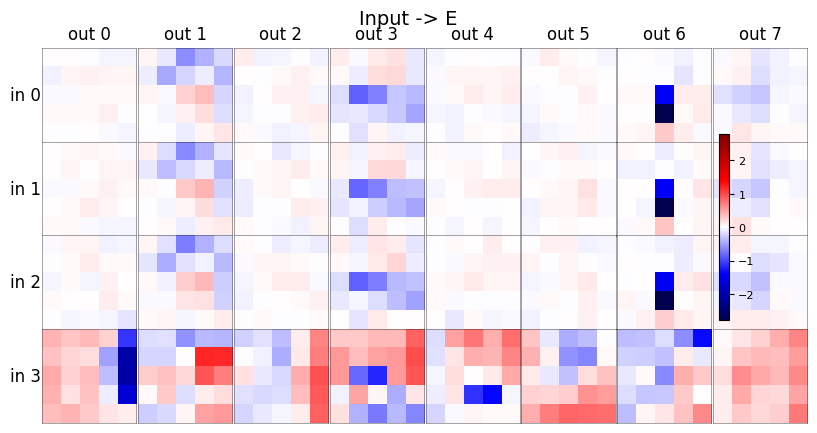

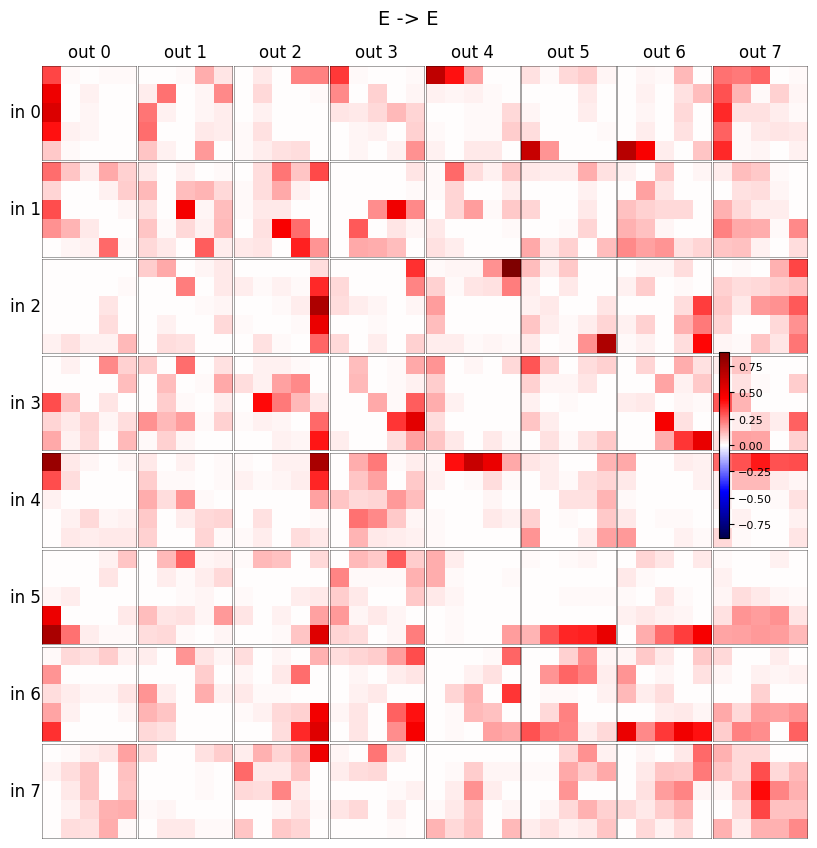

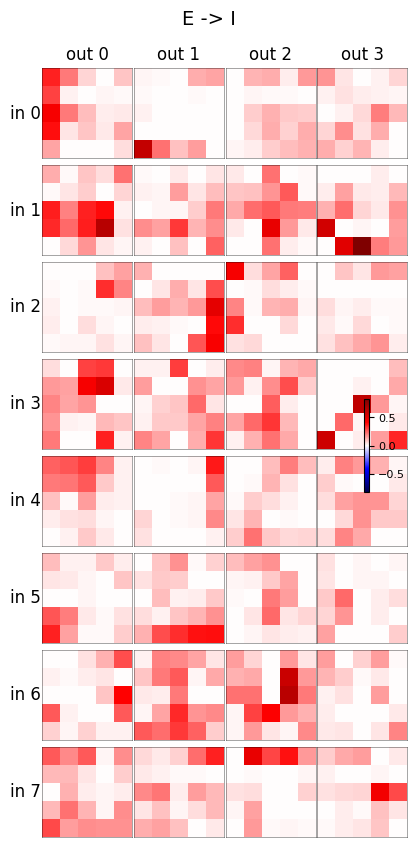

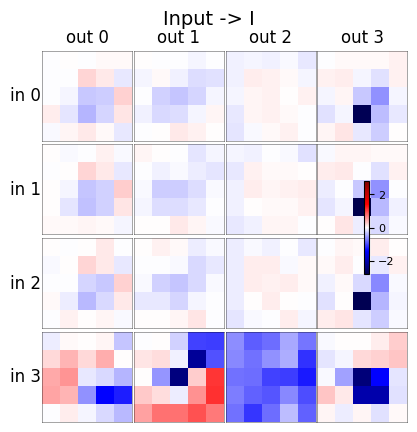

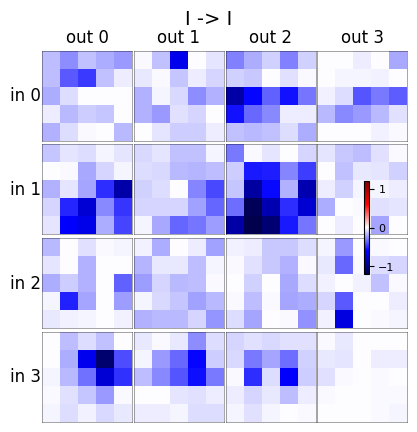

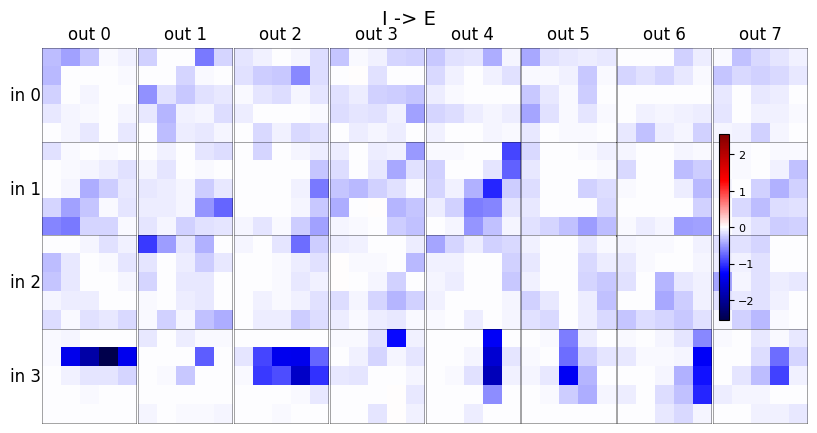

(<Figure size 800x400 with 33 Axes>,
 array([[<Axes: title={'center': 'out 0'}, ylabel='in 0'>,
         <Axes: title={'center': 'out 1'}>,
         <Axes: title={'center': 'out 2'}>,
         <Axes: title={'center': 'out 3'}>,
         <Axes: title={'center': 'out 4'}>,
         <Axes: title={'center': 'out 5'}>,
         <Axes: title={'center': 'out 6'}>,
         <Axes: title={'center': 'out 7'}>],
        [<Axes: ylabel='in 1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='in 2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='in 3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [36]:
plot_kernel_grid(input2e, title="Input -> E", savepath=os.path.join(save_dir, "figure_kernel_input2e.svg"))
plot_kernel_grid(e2e, title="E -> E", savepath=os.path.join(save_dir, "figure_kernel_e2e.svg"))
plot_kernel_grid(e2i, title="E -> I", savepath=os.path.join(save_dir, "figure_kernel_e2i.svg"))
plot_kernel_grid(input2i, title="Input -> I", savepath=os.path.join(save_dir, "figure_kernel_input2i.svg"))
plot_kernel_grid(i2i, title="I -> I", savepath=os.path.join(save_dir, "figure_kernel_i2i.svg"))
plot_kernel_grid(i2e, title="I -> E", savepath=os.path.join(save_dir, "figure_kernel_i2e.svg"))

# Figure S2 - Ablation

In [37]:
def plot(inp, inp_np, just_walls, steps_to_plot, n_channels_to_plot, num_steps, ablate_type, correctness=None, visualize_neuron=0, ablate_neuron=0, subtract_maze_activation=False, subtract_from_normal=False, ablate_all_but=False, savepath=None):
    # ----- Collect activity maps (ablations) -----
    activities = []

    if len(inp.shape) < 4:
        steps_given = num_steps
        inp_np = np.repeat(inp_np[None, ...], num_steps, axis=0)
    else:
        steps_given = None

    # ----- Normal (no ablation) activity -----
    _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=steps_given, ablater=None)
    normal_act = model.query_neuron_states(neuron_states, 0, visualize_neuron).detach().cpu()[0]  # (T, C, H, W)

    _, neuron_states, _ = model(just_walls.unsqueeze(0), num_steps=num_steps, ablater=None)
    normal_maze_act = model.query_neuron_states(neuron_states, 0, visualize_neuron).detach().cpu()[0]  # (T, C, H, W)

    # ----- Ablation activity -----
    for i in range(n_channels_to_plot):

        if ablate_all_but:
            neuron_ablation_config = {ablate_neuron: {j: "zero" for j in range(n_channels_to_plot) if j != i}}
        else:
            neuron_ablation_config = {ablate_neuron: {i: "zero"}}

        # ----- Ablation configuration -----
        if ablate_type == "exc":
            ablater = {
                step: {0: Ablation(neuron_ablation_config=neuron_ablation_config)}
                for step in range(num_steps)
            }
        elif ablate_type == "self_connection":
            # ablate a channels connection to itself
            connection_ablation_config = {
                "1->0": 
                {
                    (i, i): "zero",
                }
            }
            ablater = {
                step: {0: Ablation(connection_ablation_config=connection_ablation_config)}
                for step in range(num_steps)
            }

        elif ablate_type == "inhib_connection":
            #Ablate all inhibitory connections to a channel
            connection_ablation_config = {
                "2->0": 
                {
                    (0, i): "zero",
                    (1, i): "zero",
                    (2, i): "zero",
                    (3, i): "zero"
                }
            }
            ablater = {
                step: {0: Ablation(connection_ablation_config=connection_ablation_config)}
                for step in range(num_steps)
            }

        _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=steps_given, ablater=ablater)
        ablated_act = model.query_neuron_states(neuron_states, 0, visualize_neuron).detach().cpu()[0]  # (T, C, H, W)

        if subtract_from_normal:
            ablated_act = normal_act - ablated_act

        if subtract_maze_activation:
            _, neuron_states, _ = model(just_walls.unsqueeze(0), num_steps=num_steps, ablater=ablater)
            ablated_maze_act = model.query_neuron_states(neuron_states, 0, visualize_neuron).detach().cpu()[0]  # (T, C, H, W)

            if subtract_from_normal:
                ablated_act = (normal_act - ablated_act) - (normal_maze_act - ablated_maze_act)
            else:
                ablated_act = ablated_act - ablated_maze_act

        ablated_act = ablated_act.mean(dim=1).numpy()  # (T, H, W)
        activities.append(ablated_act)

    if subtract_maze_activation:
        normal_act = normal_act - normal_maze_act

    normal_act = normal_act.mean(dim=1).detach().cpu().numpy()  # (T, H, W) -> numpy

    # ----- Plot grid -----
    n_rows_acts  = len(activities)            # ablated activity rows
    n_cols       = len(steps_to_plot)
    n_rows_total = n_rows_acts + 2            # Input + Normal + Ablated rows

    fig, axes = plt.subplots(n_rows_total, n_cols, figsize=(3*n_cols, 3*n_rows_total), squeeze=False)

    # ---- Top row: Input (grayscale + red overlay) ----
    bg_stack = inp_np[steps_to_plot, 0]
    bg_vmin, bg_vmax = np.nanmin(bg_stack), np.nanmax(bg_stack)

    for col_idx, step_idx in enumerate(steps_to_plot):
        ax = axes[0, col_idx]
        bg   = inp_np[step_idx, 0]
        over = inp_np[step_idx, -1]

        ax.imshow(bg, cmap='gray', vmin=bg_vmin, vmax=bg_vmax, interpolation='none')

        over_norm = over.astype(float)
        vmax_o, vmin_o = np.nanmax(over_norm), np.nanmin(over_norm)
        over_norm = (over_norm - vmin_o) / (vmax_o - vmin_o) if vmax_o > vmin_o else np.zeros_like(over_norm)

        rgba = np.zeros((*over_norm.shape, 4), dtype=float)
        rgba[..., 0] = 1.0
        rgba[..., 3] = over_norm * 0.85
        ax.imshow(rgba, interpolation='none')

        ax.axis('off')
        ax.set_title(f"Step {step_idx}", fontsize=30)

    # Label the input row
    axes[0, 0].annotate("Input", xy=(-0.25, 0.5), xycoords='axes fraction',
                        ha='right', va='center', fontsize=30, fontweight='bold',
                        annotation_clip=False)

    # ---- NEW second row: Normal (no ablation) activity ----
    norm_stack = normal_act[steps_to_plot]              # (n_cols, H, W)
    nvmin, nvmax = np.nanmin(norm_stack), np.nanmax(norm_stack)

    for col_idx, step_idx in enumerate(steps_to_plot):
        ax = axes[1, col_idx]
        ax.imshow(normal_act[step_idx]) #, vmin=nvmin, vmax=nvmax, interpolation='none')
        ax.axis('off')

    # Label the normal row
    axes[1, 0].annotate("None", xy=(-0.25, 0.5), xycoords='axes fraction',
                        ha='right', va='center', fontsize=30, fontweight='bold',
                        annotation_clip=False)

    # ---- Ablated activity rows (shifted down by +2) ----
    for row_idx in range(n_rows_acts):
        row_stack = activities[row_idx][steps_to_plot]
        vmin, vmax = np.nanmin(row_stack), np.nanmax(row_stack)

        for col_idx, step_idx in enumerate(steps_to_plot):
            ax = axes[row_idx + 2, col_idx]  # +2: skip Input + Normal
            ax.imshow(activities[row_idx][step_idx]) #, vmin=vmin, vmax=vmax, interpolation='none')
            ax.axis('off')

        if correctness is not None:
            if correctness[row_idx+1]:
                correct = ", Correct"
            else:
                correct = ", Incorrect"
        else:
            correct = ""

        axes[row_idx + 2, 0].annotate(f"Channel {row_idx}{correct}",
                                    xy=(-0.25, 0.5), xycoords='axes fraction',
                                    ha='right', va='center', fontsize=30, fontweight='bold',
                                    annotation_clip=False)

    plt.tight_layout()
    plt.subplots_adjust(left=0.14)  # room for left labels
    if ablate_all_but:
        fig.supylabel("Channel not ablated", x=0.06, fontsize=30, fontweight='bold')
    else:
        fig.supylabel("Channel ablated", x=0.00, fontsize=30, fontweight='bold')
    if savepath is not None:
        fig.savefig(savepath, format='svg', bbox_inches='tight')
    plt.show()

In [38]:
def build_cross_input(
    corridor_idx=12,
    point_pos=(12, 12),
    excitatory=True,
    num_steps=20,
    num_input_steps=5,
):
    """
    Build a synthetic cross-corridor maze input.

    Args:
        corridor_idx: Row/col index for the corridor center (in 24x24 space).
        point_pos: (row, col) of the cue point (in 24x24 space).
        full_cross: If True, corridors span the full width/height.
                    If False, corridors span only [8:16] (for inhibitory tests).
        num_steps: Total number of timesteps.
        num_input_steps: Number of steps the cue is presented.

    Returns:
        inp: Input tensor (num_steps, 4, 48, 48) on device.
        inp_np: Same as numpy array.
        just_walls: Walls-only tensor (4, 48, 48) on device.
    """
    base = np.zeros((24, 24))
    walls = base.copy()

    if excitatory:
        walls[corridor_idx, :] = 1
        walls[:, corridor_idx] = 1
    else:
        walls[corridor_idx, 9:16] = 1
        walls[9:16, corridor_idx] = 1

    walls = walls.repeat(2, axis=0).repeat(2, axis=1)
    walls = np.stack([walls, walls, walls], axis=0)           # (3, 48, 48)

    points = base.copy()
    points[point_pos[0], point_pos[1]] = 1
    points = points.repeat(2, axis=0).repeat(2, axis=1)
    points = points[np.newaxis, ...]                          # (1, 48, 48)

    # Frames with cue
    C = np.concatenate([walls, points], axis=0)               # (4, 48, 48)
    C = np.repeat(C[None, ...], num_input_steps, axis=0)      # (num_input_steps, 4, 48, 48)

    # Frames without cue
    empty_points = np.zeros_like(points)
    just_walls_np = np.concatenate([walls, empty_points], axis=0)  # (4, 48, 48)
    D = np.repeat(just_walls_np[None, ...], num_steps - num_input_steps, axis=0)

    inp_np = np.concatenate([C, D], axis=0)                   # (num_steps, 4, 48, 48)
    inp = torch.as_tensor(inp_np, dtype=torch.float32).to(device)
    just_walls = torch.as_tensor(just_walls_np, dtype=torch.float32).to(device)

    return inp, inp_np, just_walls

## Ablating Individual E Channels Stops Activity Propagation in Corresponding Direction

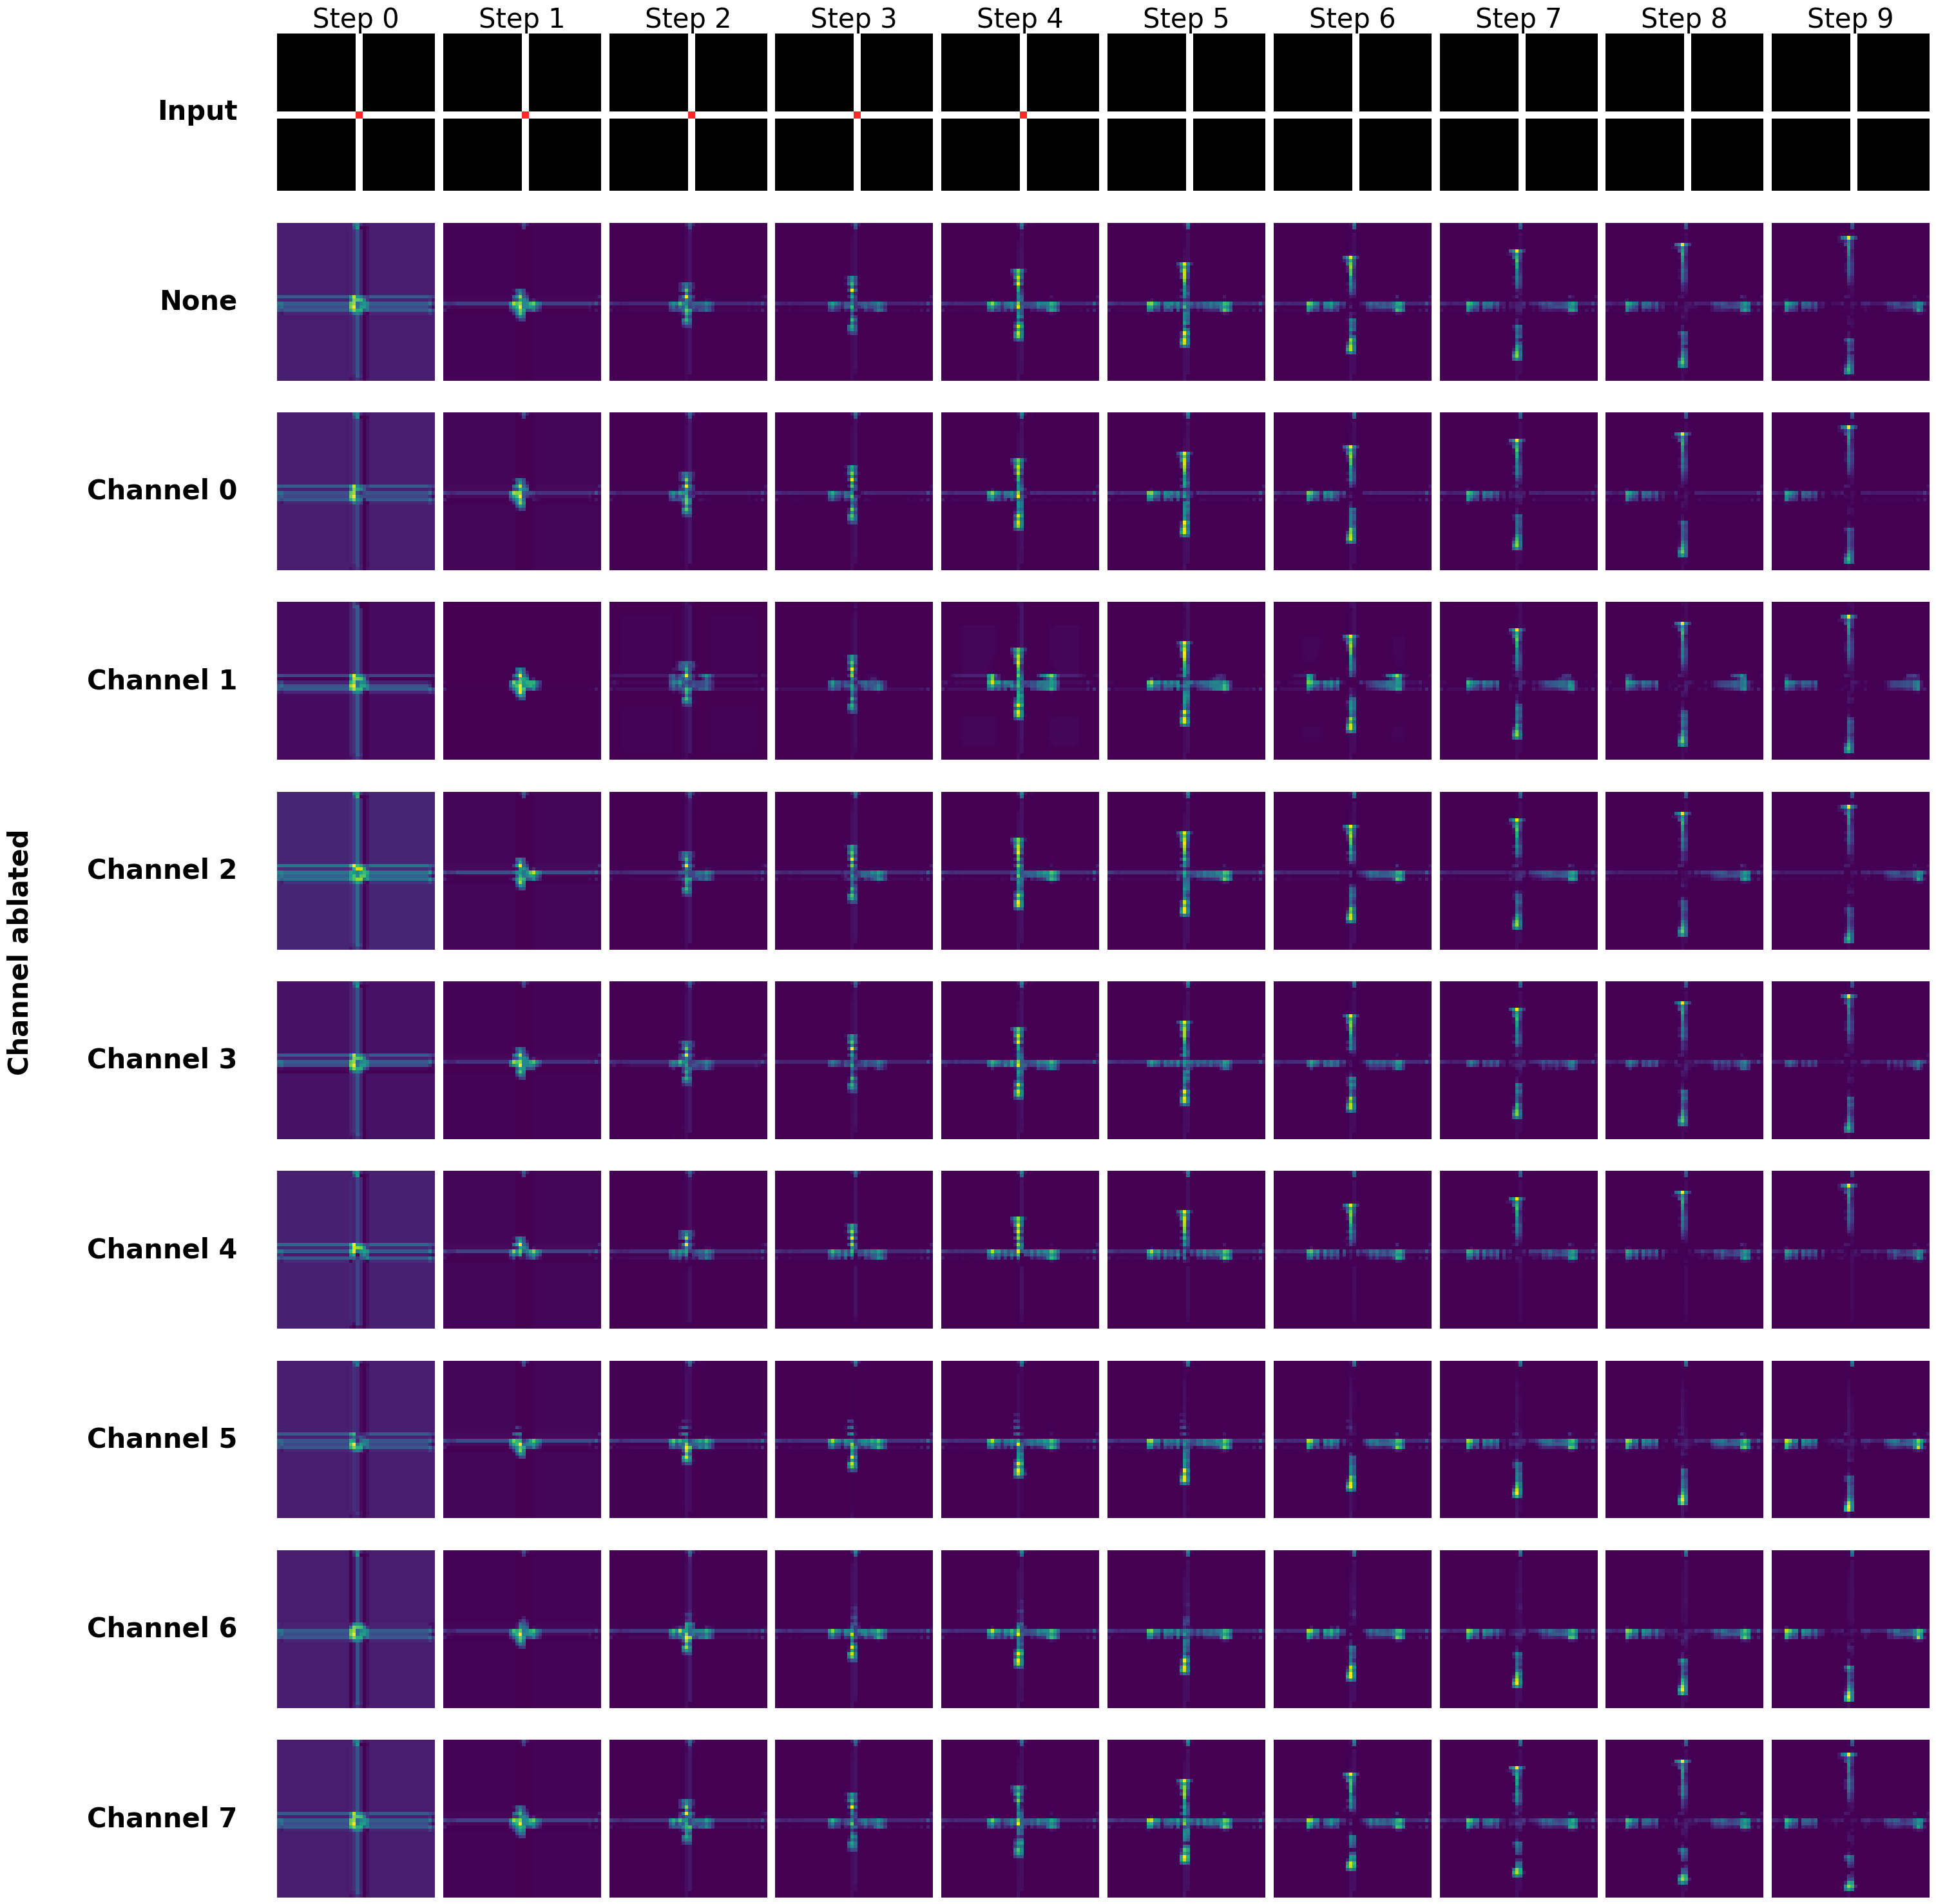

In [39]:
inp, inp_np, just_walls = build_cross_input(excitatory=True)

plot(
    inp, inp_np, just_walls,
    steps_to_plot=np.arange(0, 10),
    n_channels_to_plot=8,
    num_steps=20,
    ablate_type="exc",
    visualize_neuron=0,
    ablate_neuron=0,
    subtract_maze_activation=False, # Flipping this is potentially a better visualization.
    subtract_from_normal=False,
    ablate_all_but=False,
    savepath=os.path.join(save_dir, "figure_ablate_exc_channels.svg"),
)

## Ablating Self E -> E Connection Inhibits Activity In Corresponding Direction

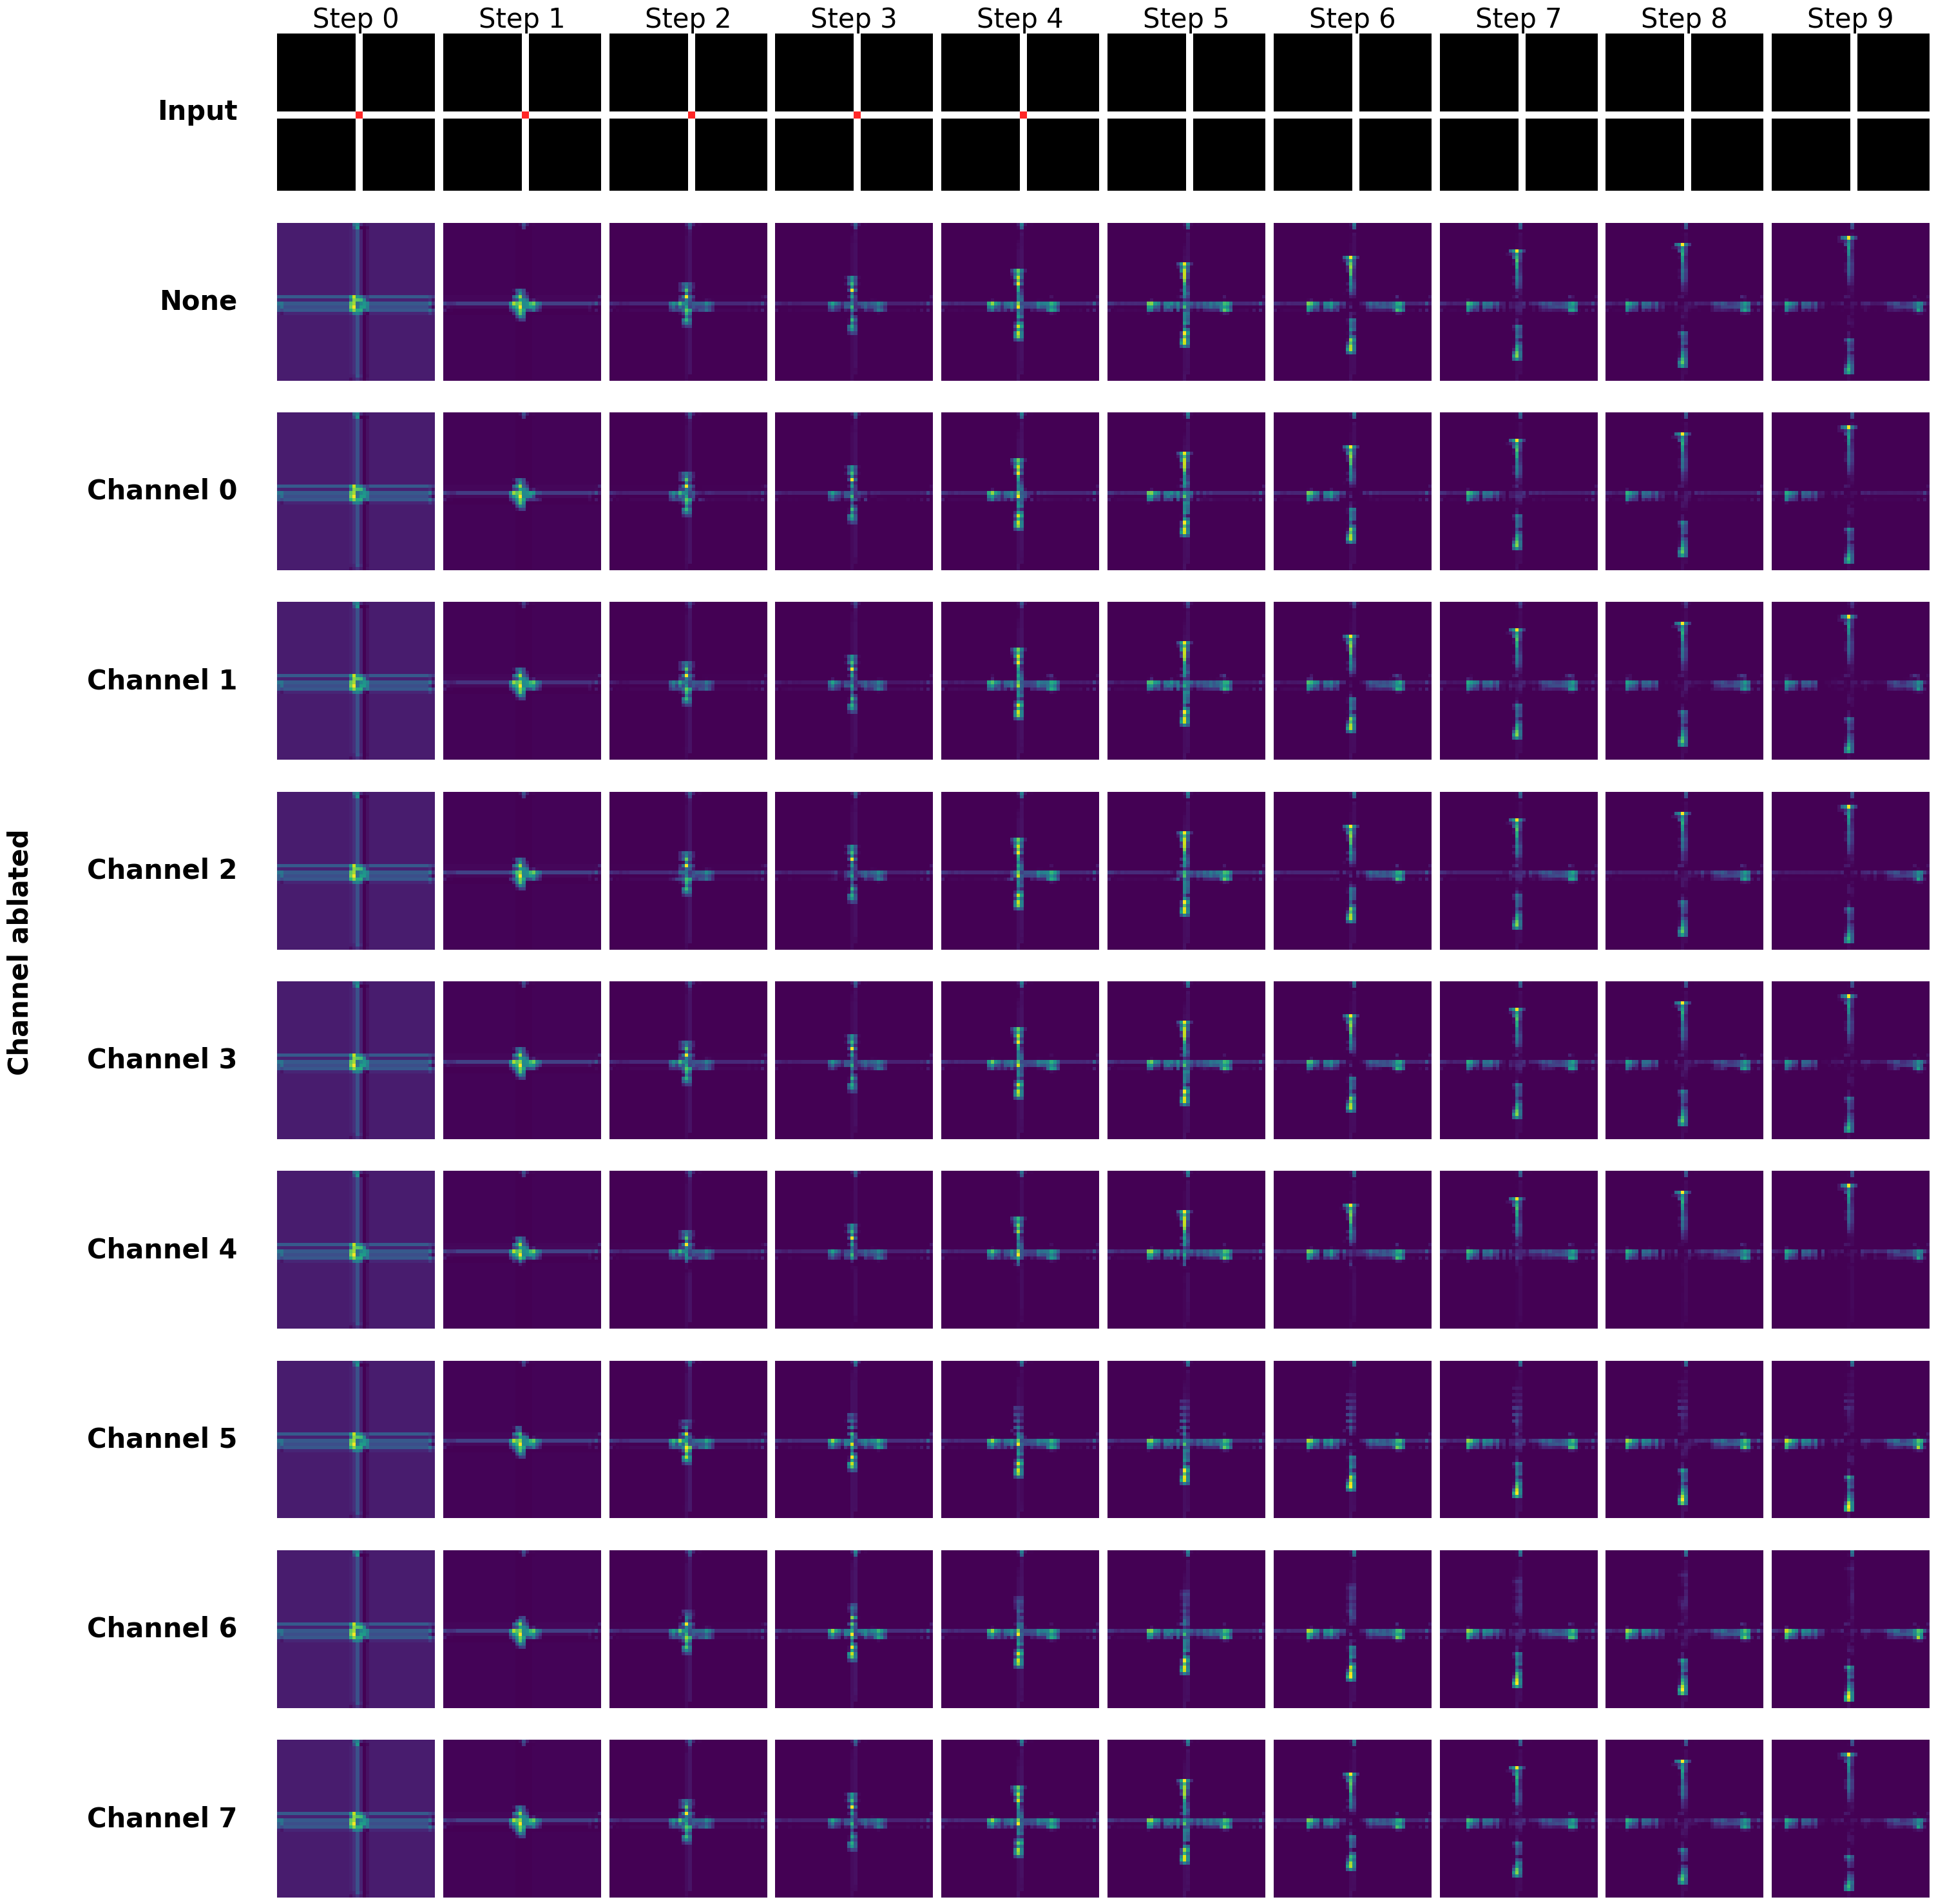

In [40]:
inp, inp_np, just_walls = build_cross_input(excitatory=True)

plot(
    inp, inp_np, just_walls,
    steps_to_plot=np.arange(0, 10),
    n_channels_to_plot=8,
    num_steps=20,
    ablate_type="self_connection",
    visualize_neuron=0,
    ablate_neuron=0,
    subtract_maze_activation=False,
    subtract_from_normal=False, # Flipping this is potentially a better visualization.
    ablate_all_but=False,
    savepath=os.path.join(save_dir, "figure_ablate_self_ee_connection.svg"),
)

## Ablating Individual Inhib->Exc Channels Lets Activity Propagate Past Walls in Corresponding Direction

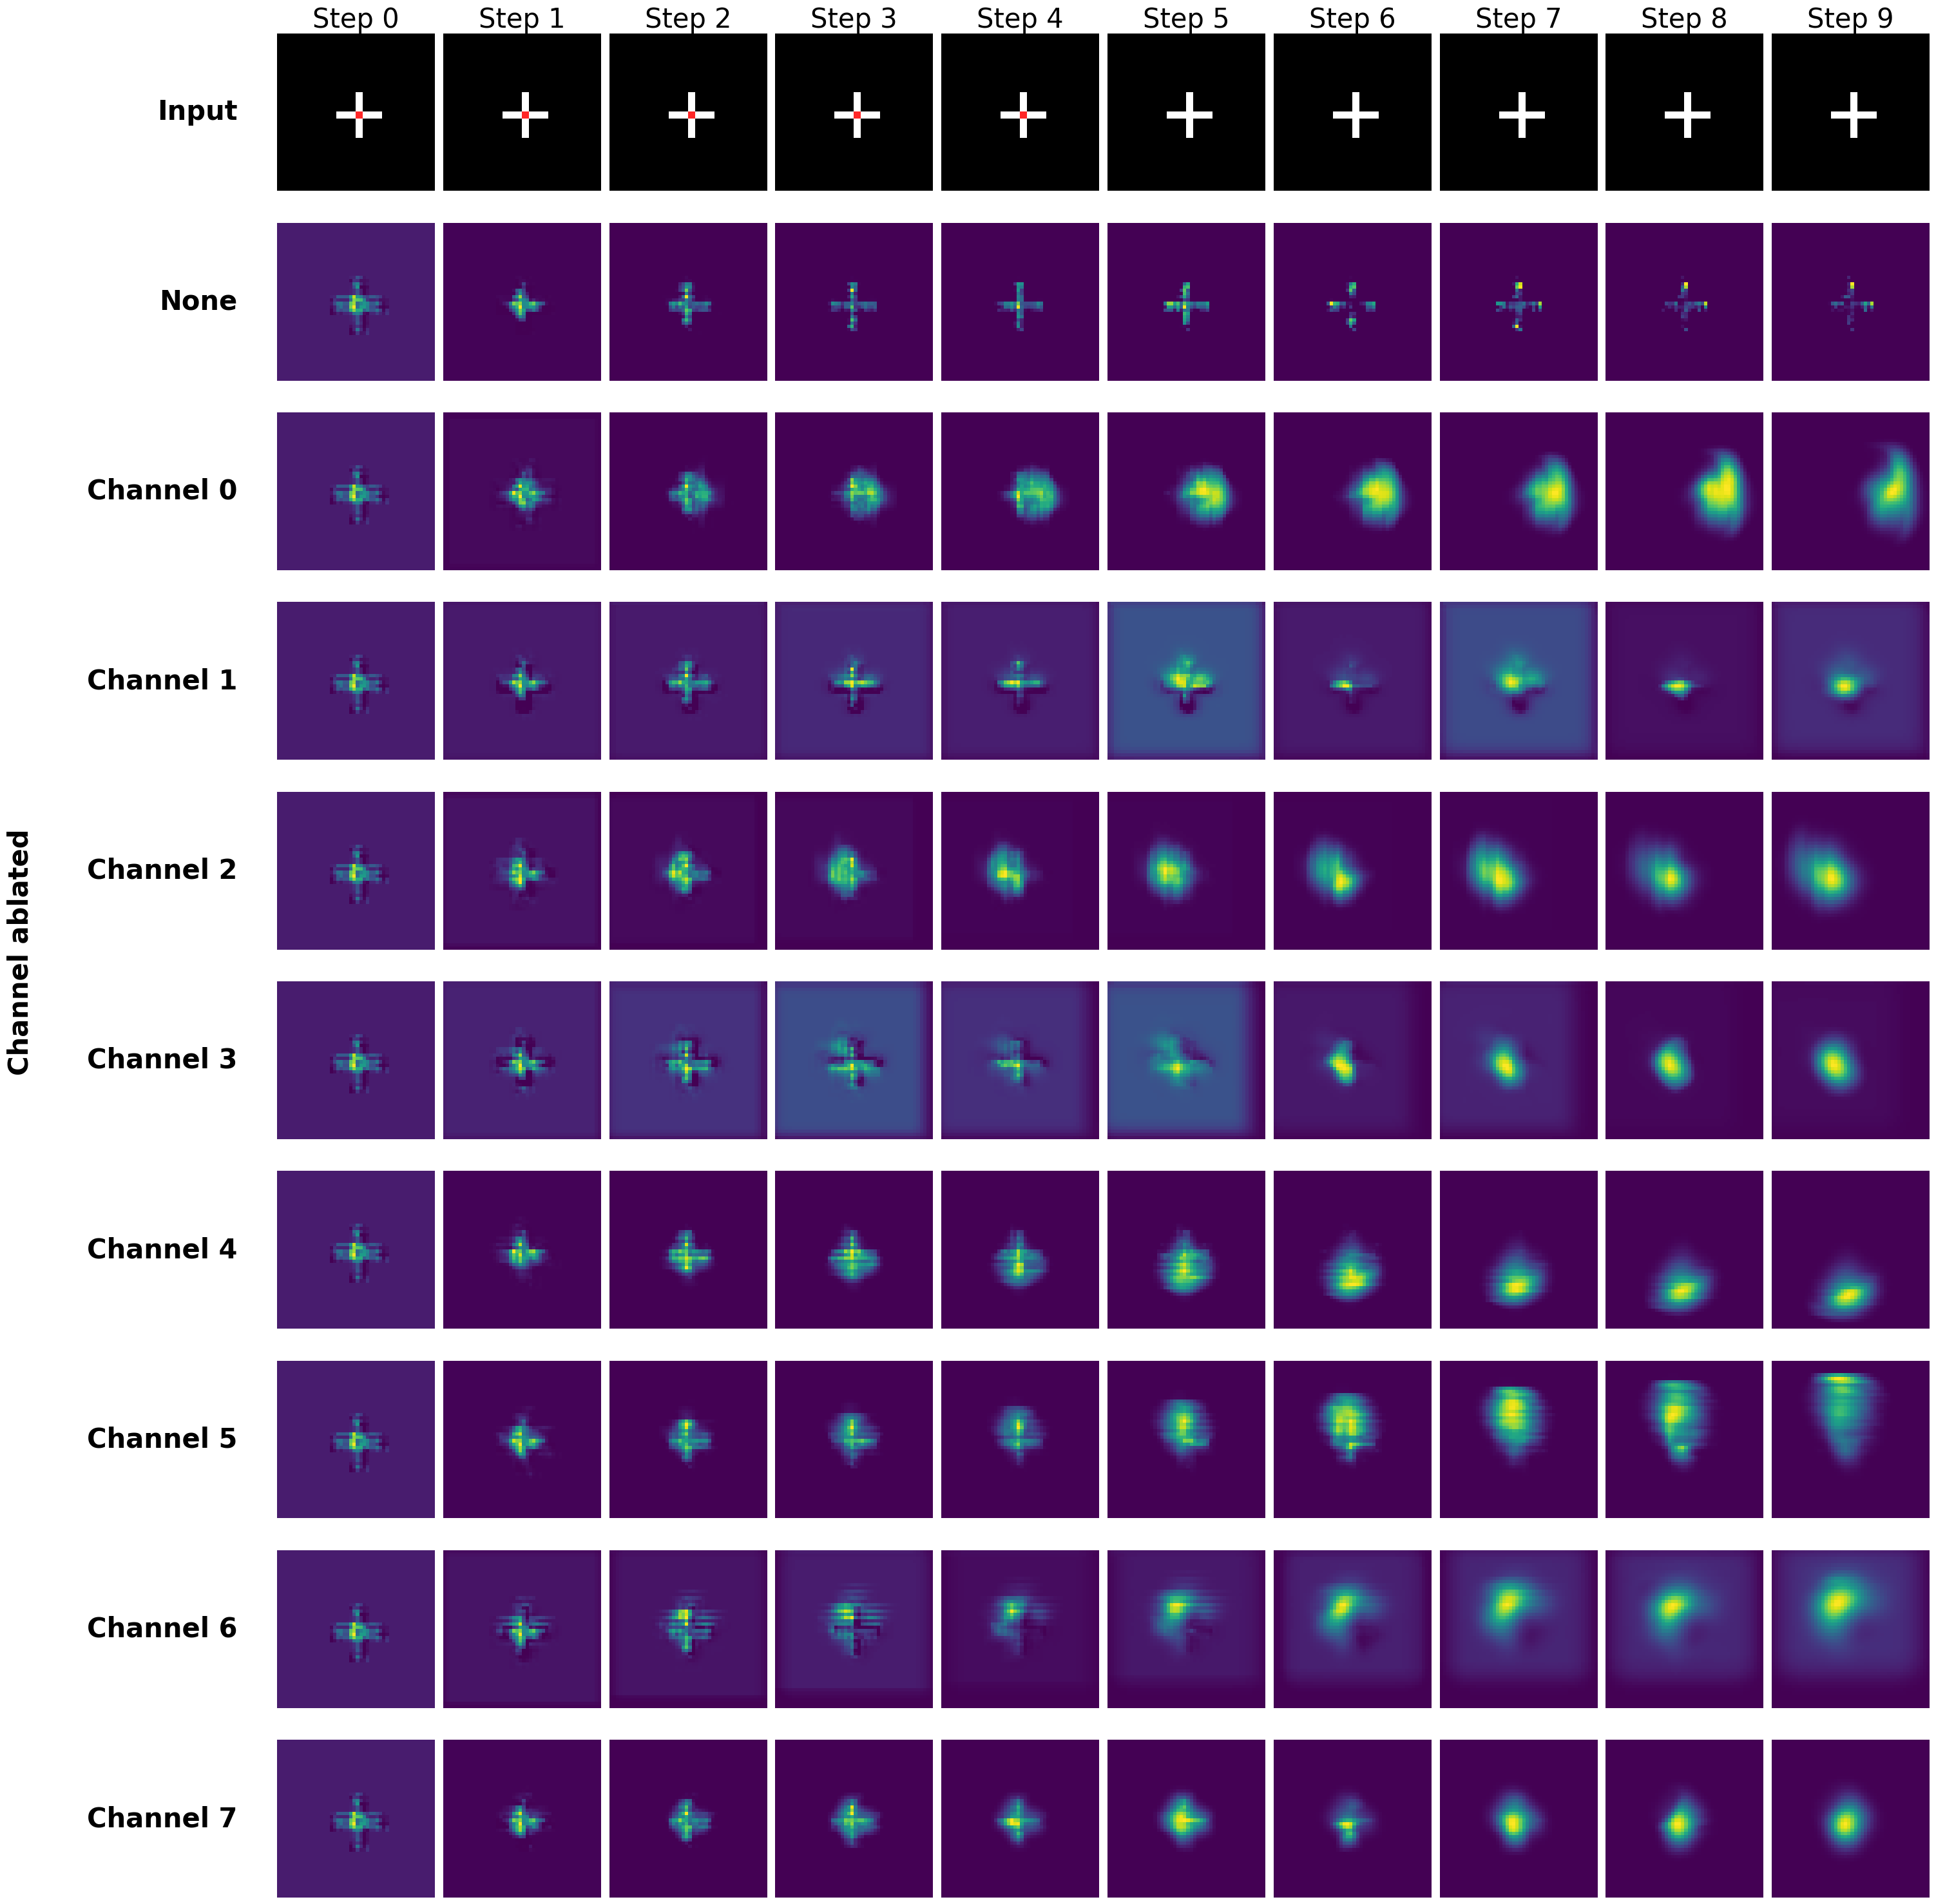

In [41]:
inp, inp_np, just_walls = build_cross_input(excitatory=False)

plot(
    inp, inp_np, just_walls,
    steps_to_plot=np.arange(0, 10),
    n_channels_to_plot=8,
    num_steps=20,
    ablate_type="inhib_connection",
    visualize_neuron=0,
    ablate_neuron=0,
    subtract_maze_activation=False,
    subtract_from_normal=False, # Flipping this is potentially a better visualization.
    ablate_all_but=False,
    savepath=os.path.join(save_dir, "figure_ablate_inhib_exc_channels.svg"),
)

# Figure S3 - In Silico Electrophysiology: Directional Tuning

In [42]:
ALL_8_DIRECTIONS = ("right", "up-right", "up", "up-left", "left", "down-left", "down", "down-right")
ALL_4_DIRECTIONS = ("left", "right", "up", "down")

# Direction -> angle in radians (CCW from right, standard math convention)
DIRECTION_ANGLES = {
    "right": 0,
    "up-right": np.pi / 4,
    "up": np.pi / 2,
    "up-left": 3 * np.pi / 4,
    "left": np.pi,
    "down-left": 5 * np.pi / 4,
    "down": 3 * np.pi / 2,
    "down-right": 7 * np.pi / 4,
}


def build_single_arm_input(
    direction="right",
    corridor_idx=12,
    point_pos=(12, 12),
    num_steps=5,
    num_input_steps=5,
):
    """
    Build a single-arm corridor input (one arm of the cross).

    Args:
        direction: One of 'left', 'right', 'up', 'down',
                   'up-right', 'up-left', 'down-right', 'down-left'.
        corridor_idx: Row/col index for the corridor center (in 24x24 space).
                      Used for cardinal directions only.
        point_pos: (row, col) of the cue point (in 24x24 space).
        num_steps: Total number of timesteps.
        num_input_steps: Number of steps the cue is presented.

    Returns:
        inp: Input tensor (num_steps, 4, 48, 48) on device.
        inp_np: Same as numpy array.
        just_walls: Walls-only tensor (4, 48, 48) on device.
    """
    base = np.zeros((24, 24))
    walls = base.copy()

    r, c = point_pos
    if direction == "right":
        walls[corridor_idx, c:] = 1
    elif direction == "left":
        walls[corridor_idx, :c + 1] = 1
    elif direction == "down":
        walls[r:, corridor_idx] = 1
    elif direction == "up":
        walls[:r + 1, corridor_idx] = 1
    elif direction == "up-right":
        for i in range(min(r + 1, 24 - c)):
            walls[r - i, c + i] = 1
            # Fill the two edge-adjacent cells to smooth the diagonal
            if i > 0:
                walls[r - i + 1, c + i] = 1  # cell below
                walls[r - i, c + i - 1] = 1  # cell to the left
    elif direction == "up-left":
        for i in range(min(r + 1, c + 1)):
            walls[r - i, c - i] = 1
            if i > 0:
                walls[r - i + 1, c - i] = 1  # cell below
                walls[r - i, c - i + 1] = 1  # cell to the right
    elif direction == "down-right":
        for i in range(min(24 - r, 24 - c)):
            walls[r + i, c + i] = 1
            if i > 0:
                walls[r + i - 1, c + i] = 1  # cell above
                walls[r + i, c + i - 1] = 1  # cell to the left
    elif direction == "down-left":
        for i in range(min(24 - r, c + 1)):
            walls[r + i, c - i] = 1
            if i > 0:
                walls[r + i - 1, c - i] = 1  # cell above
                walls[r + i, c - i + 1] = 1  # cell to the right
    else:
        raise ValueError(f"Unknown direction: {direction}")

    walls = walls.repeat(2, axis=0).repeat(2, axis=1)
    walls = np.stack([walls, walls, walls], axis=0)           # (3, 48, 48)

    points = base.copy()
    points[point_pos[0], point_pos[1]] = 1
    points = points.repeat(2, axis=0).repeat(2, axis=1)
    points = points[np.newaxis, ...]                          # (1, 48, 48)

    # Frames with cue
    C = np.concatenate([walls, points], axis=0)               # (4, 48, 48)
    C = np.repeat(C[None, ...], num_input_steps, axis=0)      # (num_input_steps, 4, 48, 48)

    # Frames without cue
    empty_points = np.zeros_like(points)
    just_walls_np = np.concatenate([walls, empty_points], axis=0)
    D = np.repeat(just_walls_np[None, ...], num_steps - num_input_steps, axis=0)

    inp_np = np.concatenate([C, D], axis=0)                   # (num_steps, 4, 48, 48)
    inp = torch.as_tensor(inp_np, dtype=torch.float32).to(device)
    just_walls = torch.as_tensor(just_walls_np, dtype=torch.float32).to(device)

    return inp, inp_np, just_walls


def record_2x2_block(activity, i, j):
    """
    Average the 2x2 pixel block starting at (i, j) from activity of shape (T, C, H, W).
    Returns shape (T, C).
    """
    return activity[:, :, i:i+2, j:j+2].mean(dim=(-2, -1))


def draw_input_with_sites(ax, inp_np, recording_positions, site_colors=None, linewidth=1.5):
    """
    Draw the corridor input on an axis with colored squares at recording positions.

    Args:
        ax: Matplotlib axis.
        inp_np: Input array of shape (T, 4, 48, 48) or (4, 48, 48).
        recording_positions: List of (pixel_i, pixel_j) tuples (top-left of 2x2 blocks).
        site_colors: List of colors for each site, or single color string. Defaults to lime.
        linewidth: Line width of the recording-site outline rectangles.
    """
    frame = inp_np[0] if inp_np.ndim == 4 else inp_np  # (4, 48, 48)
    walls = frame[0]
    cue = frame[-1]

    # Build RGB image: black bg, white corridors, red cue
    h, w = walls.shape
    rgb = np.zeros((h, w, 3), dtype=np.float32)
    rgb[walls > 0] = [1, 1, 1]
    rgb[cue > 0] = [1, 0, 0]

    ax.imshow(rgb, interpolation='none')

    # Draw recording-site markers
    if site_colors is None:
        site_colors = ['lime'] * len(recording_positions)
    elif isinstance(site_colors, str):
        site_colors = [site_colors] * len(recording_positions)

    for idx, (pi, pj) in enumerate(recording_positions):
        # Draw outline rectangle exactly on the 2x2 pixel block.
        # Pixel [pi, pj] spans from (pj-0.5, pi-0.5) to (pj+0.5, pi+0.5) in imshow coords,
        # so the 2x2 block [pi:pi+2, pj:pj+2] spans (pj-0.5, pi-0.5) to (pj+1.5, pi+1.5).
        color = site_colors[idx] if idx < len(site_colors) else 'lime'
        rect = Rectangle((pj - 0.5, pi - 0.5), 2, 2,
                          linewidth=linewidth, edgecolor=color, facecolor='none', zorder=5)
        ax.add_patch(rect)

    ax.set_xticks([])
    ax.set_yticks([])


_DIR_DELTAS = {
    "right": (0, 1), "left": (0, -1), "up": (-1, 0), "down": (1, 0),
    "up-right": (-1, 1), "up-left": (-1, -1), "down-right": (1, 1), "down-left": (1, -1),
}

def get_position_at_distance(direction, d, corridor_idx=12, point_pos=(12, 12)):
    """
    Return the (pixel_i, pixel_j) recording-block origin at exactly d logical
    cells from center along the given arm direction.

    d=0 returns center. Clamped to arm length.
    """
    r, c = point_pos
    dr, dc = _DIR_DELTAS[direction]
    # For cardinal directions, the fixed axis uses corridor_idx
    if direction in ("right", "left"):
        row, col = corridor_idx, c + dc * d
    elif direction in ("up", "down"):
        row, col = r + dr * d, corridor_idx
    else:
        row, col = r + dr * d, c + dc * d
    # Clamp to grid
    row = max(0, min(23, row))
    col = max(0, min(23, col))
    return (2 * row, 2 * col)


def get_arm_recording_positions(direction, corridor_idx=12, point_pos=(12, 12), n_sites=5):
    """
    Return a list of (pixel_i, pixel_j) recording-block origins along the given arm,
    evenly spaced from center outward. Each position is the top-left corner of a 2x2 block.

    Supports all 8 directions: cardinal + diagonal.

    Args:
        direction: one of ALL_8_DIRECTIONS
        corridor_idx: row/col of the corridor in 24x24 space (cardinal only)
        point_pos: (row, col) of the cue point in 24x24 space
        n_sites: number of evenly spaced recording sites along the arm

    Returns:
        List of (pixel_i, pixel_j) tuples (top-left of each 2x2 block).
    """
    r, c = point_pos

    if direction == "right":
        arm_cells = [(corridor_idx, c + i) for i in range(24 - c)]
    elif direction == "left":
        arm_cells = [(corridor_idx, c - i) for i in range(c + 1)]
    elif direction == "down":
        arm_cells = [(r + i, corridor_idx) for i in range(24 - r)]
    elif direction == "up":
        arm_cells = [(r - i, corridor_idx) for i in range(r + 1)]
    elif direction == "up-right":
        arm_cells = [(r - i, c + i) for i in range(min(r + 1, 24 - c))]
    elif direction == "up-left":
        arm_cells = [(r - i, c - i) for i in range(min(r + 1, c + 1))]
    elif direction == "down-right":
        arm_cells = [(r + i, c + i) for i in range(min(24 - r, 24 - c))]
    elif direction == "down-left":
        arm_cells = [(r + i, c - i) for i in range(min(24 - r, c + 1))]
    else:
        raise ValueError(f"Unknown direction: {direction}")

    positions = np.linspace(0, len(arm_cells) - 1, n_sites, dtype=int)
    return [(2 * arm_cells[p][0], 2 * arm_cells[p][1]) for p in positions]

In [43]:
def plot_electrophysiology_center(
    model,
    directions=ALL_8_DIRECTIONS,
    corridor_idx=12,
    point_pos=(12, 12),
    num_steps=5,
    num_input_steps=5,
    neuron_type=0,       # 0 = excitatory, 1 = inhibitory
    savepath=None,
):
    """
    In silico electrophysiology: record from the center 2x2 block
    across all channels over time, for each single-arm corridor direction.
    Top row: input visualization with recording site marked.
    Bottom row: channel activity traces over time.
    """
    n_dirs = len(directions)
    n_channels = 8 if neuron_type == 0 else 4
    colors = plt.cm.tab10(np.arange(n_channels))

    # Center 2x2 block in pixel space
    center_pi, center_pj = 2 * point_pos[0], 2 * point_pos[1]

    # 2 rows: input viz (top) + traces (bottom); extra col for legend
    fig, axes = plt.subplots(
        2, n_dirs + 1,
        figsize=(4 * n_dirs + 1.5, 7),
        gridspec_kw={"width_ratios": [1] * n_dirs + [0.4], "height_ratios": [1, 1.4]},
    )

    all_traces = {}
    all_inp_nps = {}
    global_ymin, global_ymax = float('inf'), float('-inf')

    for direction in directions:
        inp, inp_np, just_walls = build_single_arm_input(
            direction=direction,
            corridor_idx=corridor_idx,
            point_pos=point_pos,
            num_steps=num_steps,
            num_input_steps=num_input_steps,
        )

        with torch.no_grad():
            _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=None)

        activity = model.query_neuron_states(
            neuron_states, 0, neuron_type
        ).detach().cpu()[0]  # (T, C, H, W)

        # Average over center 2x2 block -> (T, C)
        traces = record_2x2_block(activity, center_pi, center_pj).numpy()
        all_traces[direction] = traces
        all_inp_nps[direction] = inp_np

        ymin, ymax = traces.min(), traces.max()
        global_ymin = min(global_ymin, ymin)
        global_ymax = max(global_ymax, ymax)

    # Add margin
    margin = (global_ymax - global_ymin) * 0.05
    global_ymin -= margin
    global_ymax += margin

    for d_idx, direction in enumerate(directions):
        # --- Top row: input visualization ---
        ax_img = axes[0, d_idx]
        draw_input_with_sites(
            ax_img, all_inp_nps[direction],
            recording_positions=[(center_pi, center_pj)],
            site_colors='lime',
        )
        ax_img.set_title(direction.capitalize(), fontsize=14)

        # --- Bottom row: traces ---
        ax = axes[1, d_idx]
        traces = all_traces[direction]
        T = traces.shape[0]

        for ch in range(n_channels):
            ax.plot(range(T), traces[:, ch], color=colors[ch], linewidth=1.5,
                    label=f"Ch {ch}")

        # Shade the input presentation period
        ax.axvspan(0, num_input_steps - 0.5, alpha=0.1, color='gray')

        ax.set_xlabel("Time Step", fontsize=12)
        ax.set_ylim(global_ymin, global_ymax)
        if d_idx == 0:
            type_label = "Excitatory" if neuron_type == 0 else "Inhibitory"
            ax.set_ylabel(f"{type_label} Activity", fontsize=12)
        else:
            ax.set_yticklabels([])

    # Turn off extra legend column axes in top row
    axes[0, -1].axis('off')

    # Legend in the extra axis (bottom row)
    ax_leg = axes[1, -1]
    ax_leg.axis('off')
    handles = [plt.Line2D([0], [0], color=colors[ch], linewidth=2, label=f"Channel {ch}")
               for ch in range(n_channels)]
    handles.append(plt.Rectangle((0, 0), 1, 1, fc='gray', alpha=0.2, label='Cue on'))
    handles.append(Rectangle((0, 0), 1, 1, edgecolor='lime', facecolor='none',
                              linewidth=1.5, label='Recording site'))
    ax_leg.legend(handles=handles, loc='center', fontsize=12, frameon=False)

    type_str = "Excitatory" if neuron_type == 0 else "Inhibitory"
    fig.suptitle(f"Center Recording — {type_str} Channels", fontsize=16, y=1.02)
    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, format='svg', bbox_inches='tight')
    plt.show()
    return all_traces

In [44]:
def plot_electrophysiology_along_arm(
    model,
    directions=ALL_8_DIRECTIONS,
    corridor_idx=12,
    point_pos=(12, 12),
    num_steps=5,
    num_input_steps=5,
    neuron_type=0,
    n_sites=5,
    savepath=None,
):
    """
    In silico electrophysiology along each arm: for each direction, present
    the single-arm stimulus and record from n_sites 2x2 blocks spaced evenly
    along that arm (center -> edge).

    Layout: rows = directions, col 0 = input image with site markers,
    cols 1..n_sites = trace plots, last col = legend.
    """
    n_dirs = len(directions)
    n_channels = 8 if neuron_type == 0 else 4
    colors = plt.cm.tab10(np.arange(n_channels))

    # Generate distinct colors for recording sites (center -> edge)
    site_cmap = plt.cm.cool(np.linspace(0.1, 0.9, n_sites))

    # Columns: input_viz + n_sites trace plots + legend
    n_cols = 1 + n_sites + 1
    fig, axes = plt.subplots(
        n_dirs, n_cols,
        figsize=(3 * n_sites + 4.5, 3 * n_dirs),
        gridspec_kw={"width_ratios": [1.2] + [1] * n_sites + [0.4]},
        squeeze=False,
    )

    global_ymin, global_ymax = float('inf'), float('-inf')
    all_data = {}

    # First pass: collect all traces and find global y range
    for direction in directions:
        inp, inp_np, just_walls = build_single_arm_input(
            direction=direction,
            corridor_idx=corridor_idx,
            point_pos=point_pos,
            num_steps=num_steps,
            num_input_steps=num_input_steps,
        )

        with torch.no_grad():
            _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=None)

        activity = model.query_neuron_states(
            neuron_states, 0, neuron_type
        ).detach().cpu()[0]  # (T, C, H, W)

        positions = get_arm_recording_positions(
            direction, corridor_idx=corridor_idx, point_pos=point_pos, n_sites=n_sites
        )

        site_traces = []
        for pi, pj in positions:
            traces = record_2x2_block(activity, pi, pj).numpy()  # (T, C)
            site_traces.append(traces)
            global_ymin = min(global_ymin, traces.min())
            global_ymax = max(global_ymax, traces.max())

        all_data[direction] = (site_traces, positions, inp_np)

    margin = (global_ymax - global_ymin) * 0.05
    global_ymin -= margin
    global_ymax += margin

    # Second pass: plot
    center_pi, center_pj = 2 * point_pos[0], 2 * point_pos[1]

    for d_idx, direction in enumerate(directions):
        site_traces, positions, inp_np = all_data[direction]

        # --- Col 0: input visualization with recording-site markers ---
        ax_img = axes[d_idx, 0]
        draw_input_with_sites(
            ax_img, inp_np,
            recording_positions=positions,
            site_colors=[site_cmap[s] for s in range(n_sites)],
        )
        ax_img.set_ylabel(f"{direction.capitalize()}", fontsize=12)
        if d_idx == 0:
            ax_img.set_title("Input", fontsize=12)

        # --- Cols 1..n_sites: trace plots ---
        for s_idx, (traces, (pi, pj)) in enumerate(zip(site_traces, positions)):
            ax = axes[d_idx, 1 + s_idx]
            T = traces.shape[0]

            for ch in range(n_channels):
                ax.plot(range(T), traces[:, ch], color=colors[ch], linewidth=1.2)

            ax.axvspan(0, num_input_steps - 0.5, alpha=0.1, color='gray')
            ax.set_ylim(global_ymin, global_ymax)

            # Highlight the border with the site color
            for spine in ax.spines.values():
                spine.set_edgecolor(site_cmap[s_idx])
                spine.set_linewidth(2)

            # Compute logical cell distance from center
            dist = abs(pi - center_pi) // 2 + abs(pj - center_pj) // 2

            if d_idx == 0:
                ax.set_title(f"d={dist}", fontsize=12)
            if d_idx == n_dirs - 1:
                ax.set_xlabel("Time", fontsize=12)
            else:
                ax.set_xticklabels([])
            if s_idx == 0:
                pass  # ylabel is on the image column
            ax.set_yticklabels([])

        # --- Last col: legend ---
        ax_leg = axes[d_idx, -1]
        ax_leg.axis('off')
        if d_idx == 0:
            handles = [plt.Line2D([0], [0], color=colors[ch], linewidth=2, label=f"Ch {ch}")  # pyright: ignore[reportPrivateImportUsage]
                       for ch in range(n_channels)]
            handles.append(plt.Rectangle((0, 0), 1, 1, fc='gray', alpha=0.2, label='Cue on'))  # pyright: ignore[reportArgumentType, reportPrivateImportUsage]
            # Site legend entries
            for s in range(n_sites):
                handles.append(Rectangle((0, 0), 1, 1, edgecolor=site_cmap[s],  # pyright: ignore[reportArgumentType]
                               facecolor='none', linewidth=1.5, label=f'Site {s}'))
            ax_leg.legend(handles=handles, loc='center', fontsize=12, frameon=False)

    type_str = "Excitatory" if neuron_type == 0 else "Inhibitory"
    fig.suptitle(f"Along-Arm Recording — {type_str} Channels", fontsize=16, y=1.02)
    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, format='svg', bbox_inches='tight')
    plt.show()
    return all_data

## Center Recording

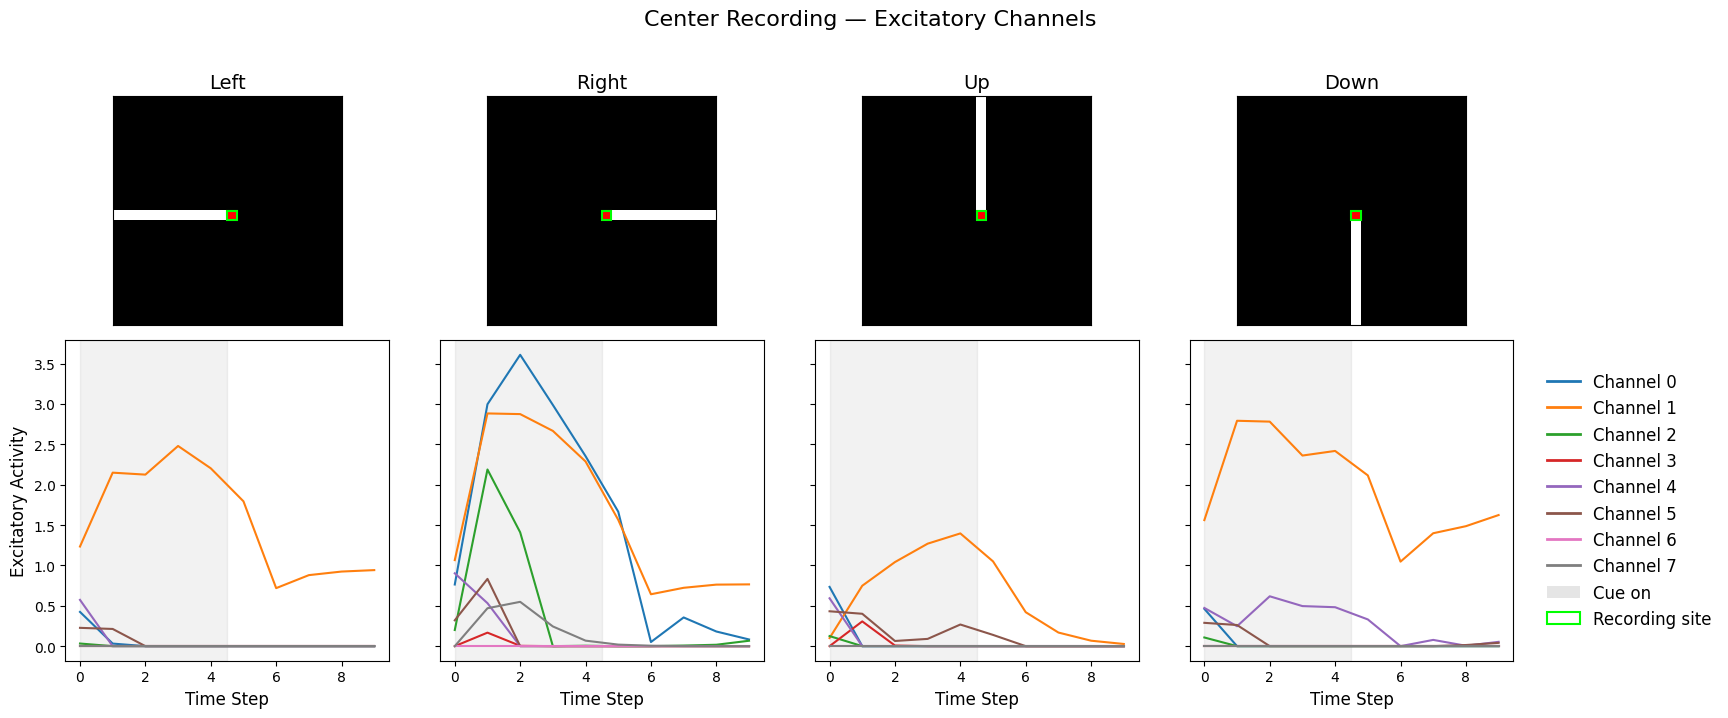

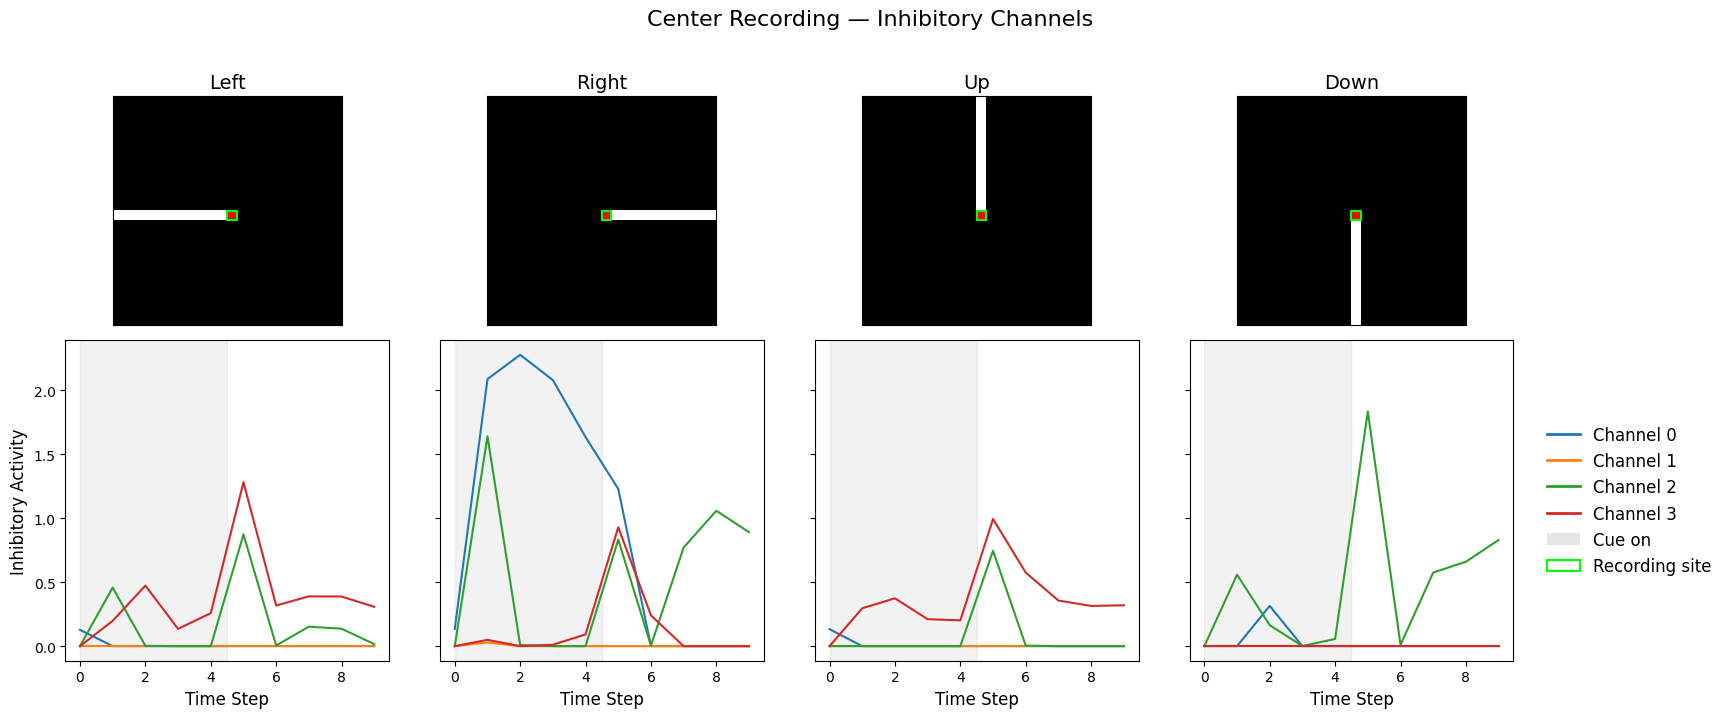

In [45]:
# Excitatory channels — center recording
exc_center_traces = plot_electrophysiology_center(
    model,
    neuron_type=0,
    num_steps=10,
    num_input_steps=5,
    directions=ALL_4_DIRECTIONS,
    savepath=os.path.join(save_dir, "figure_electrophys_center_exc.svg"),
)

# Inhibitory channels — center recording
inh_center_traces = plot_electrophysiology_center(
    model,
    neuron_type=1,
    num_steps=10,
    num_input_steps=5,
    directions=ALL_4_DIRECTIONS,
    savepath=os.path.join(save_dir, "figure_electrophys_center_inh.svg"),
)

## Along-Arm Recording

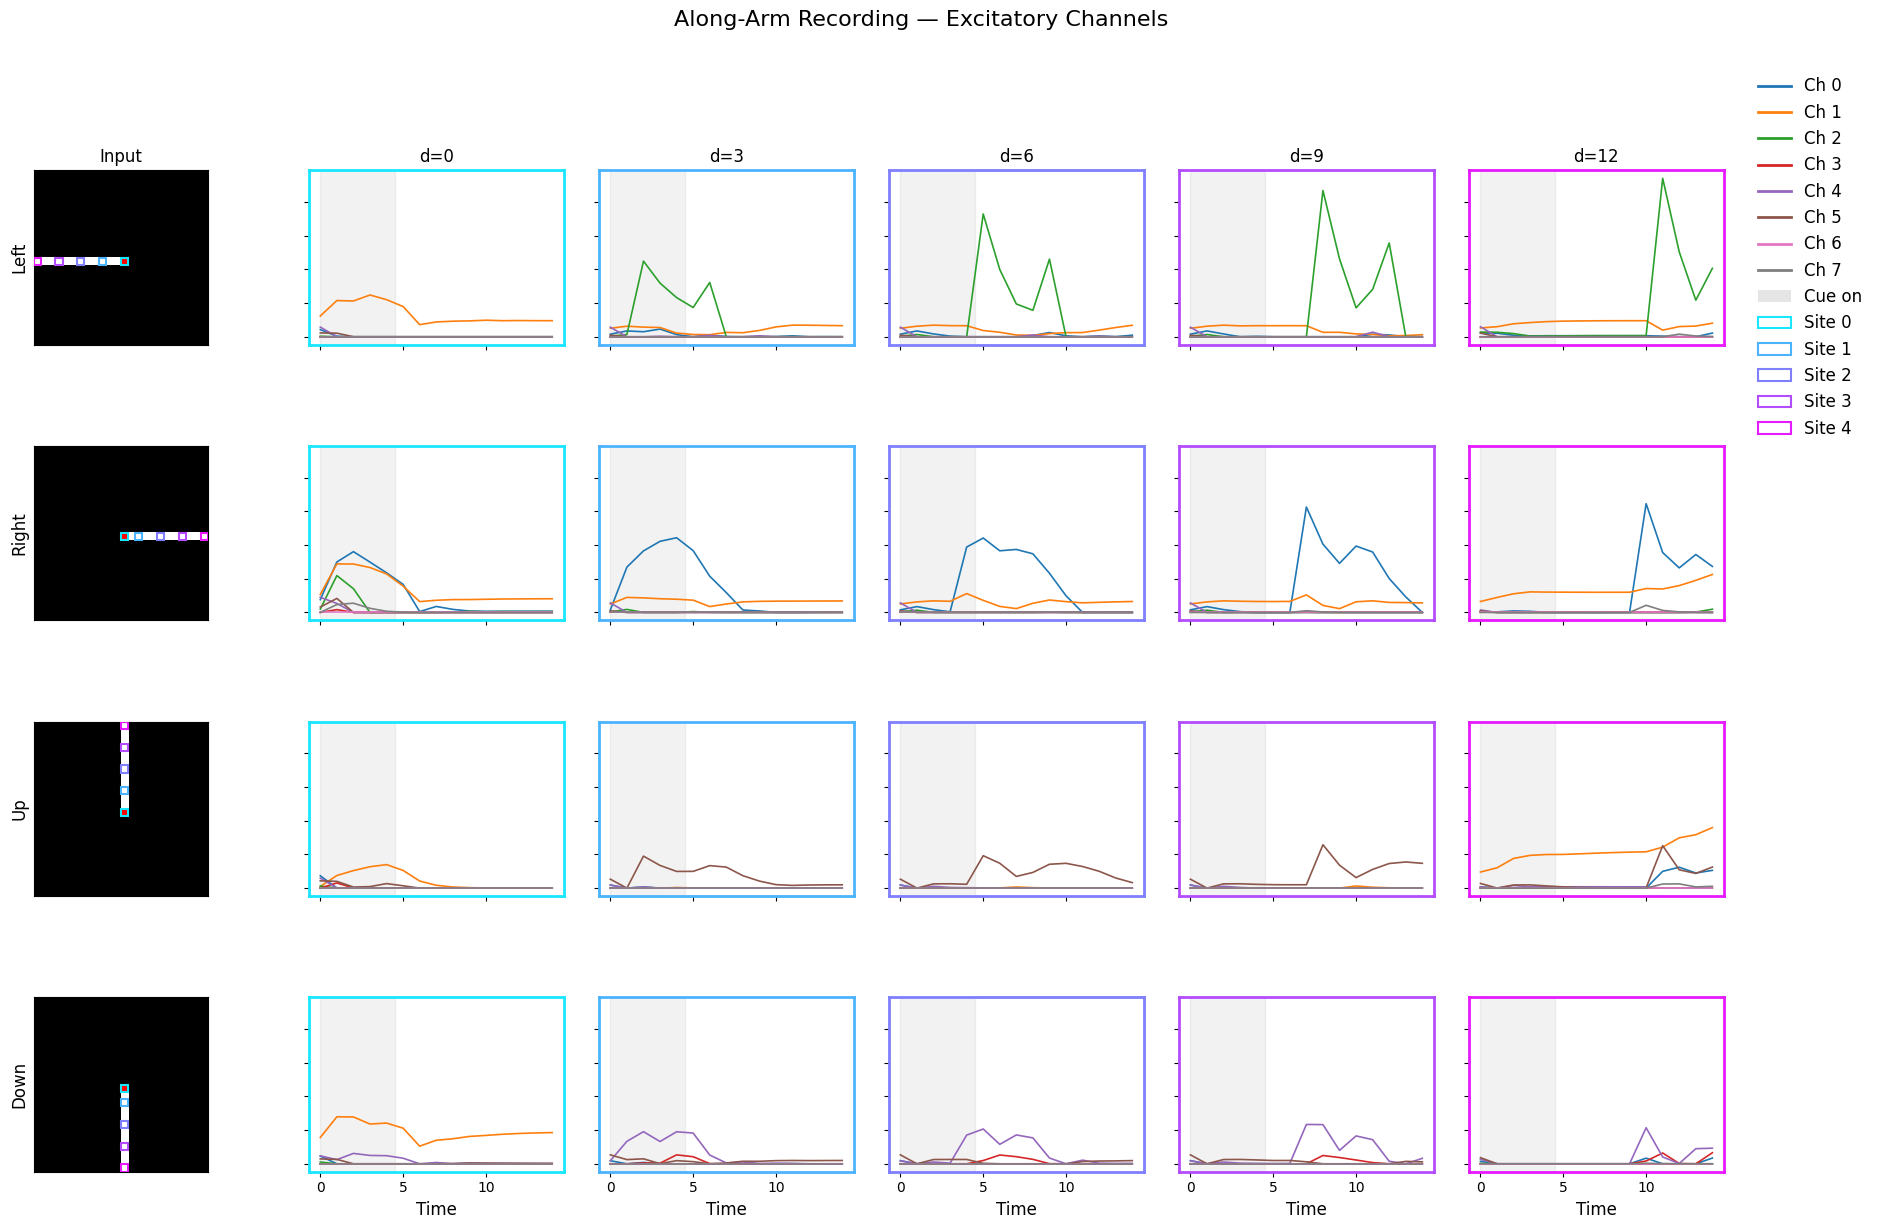

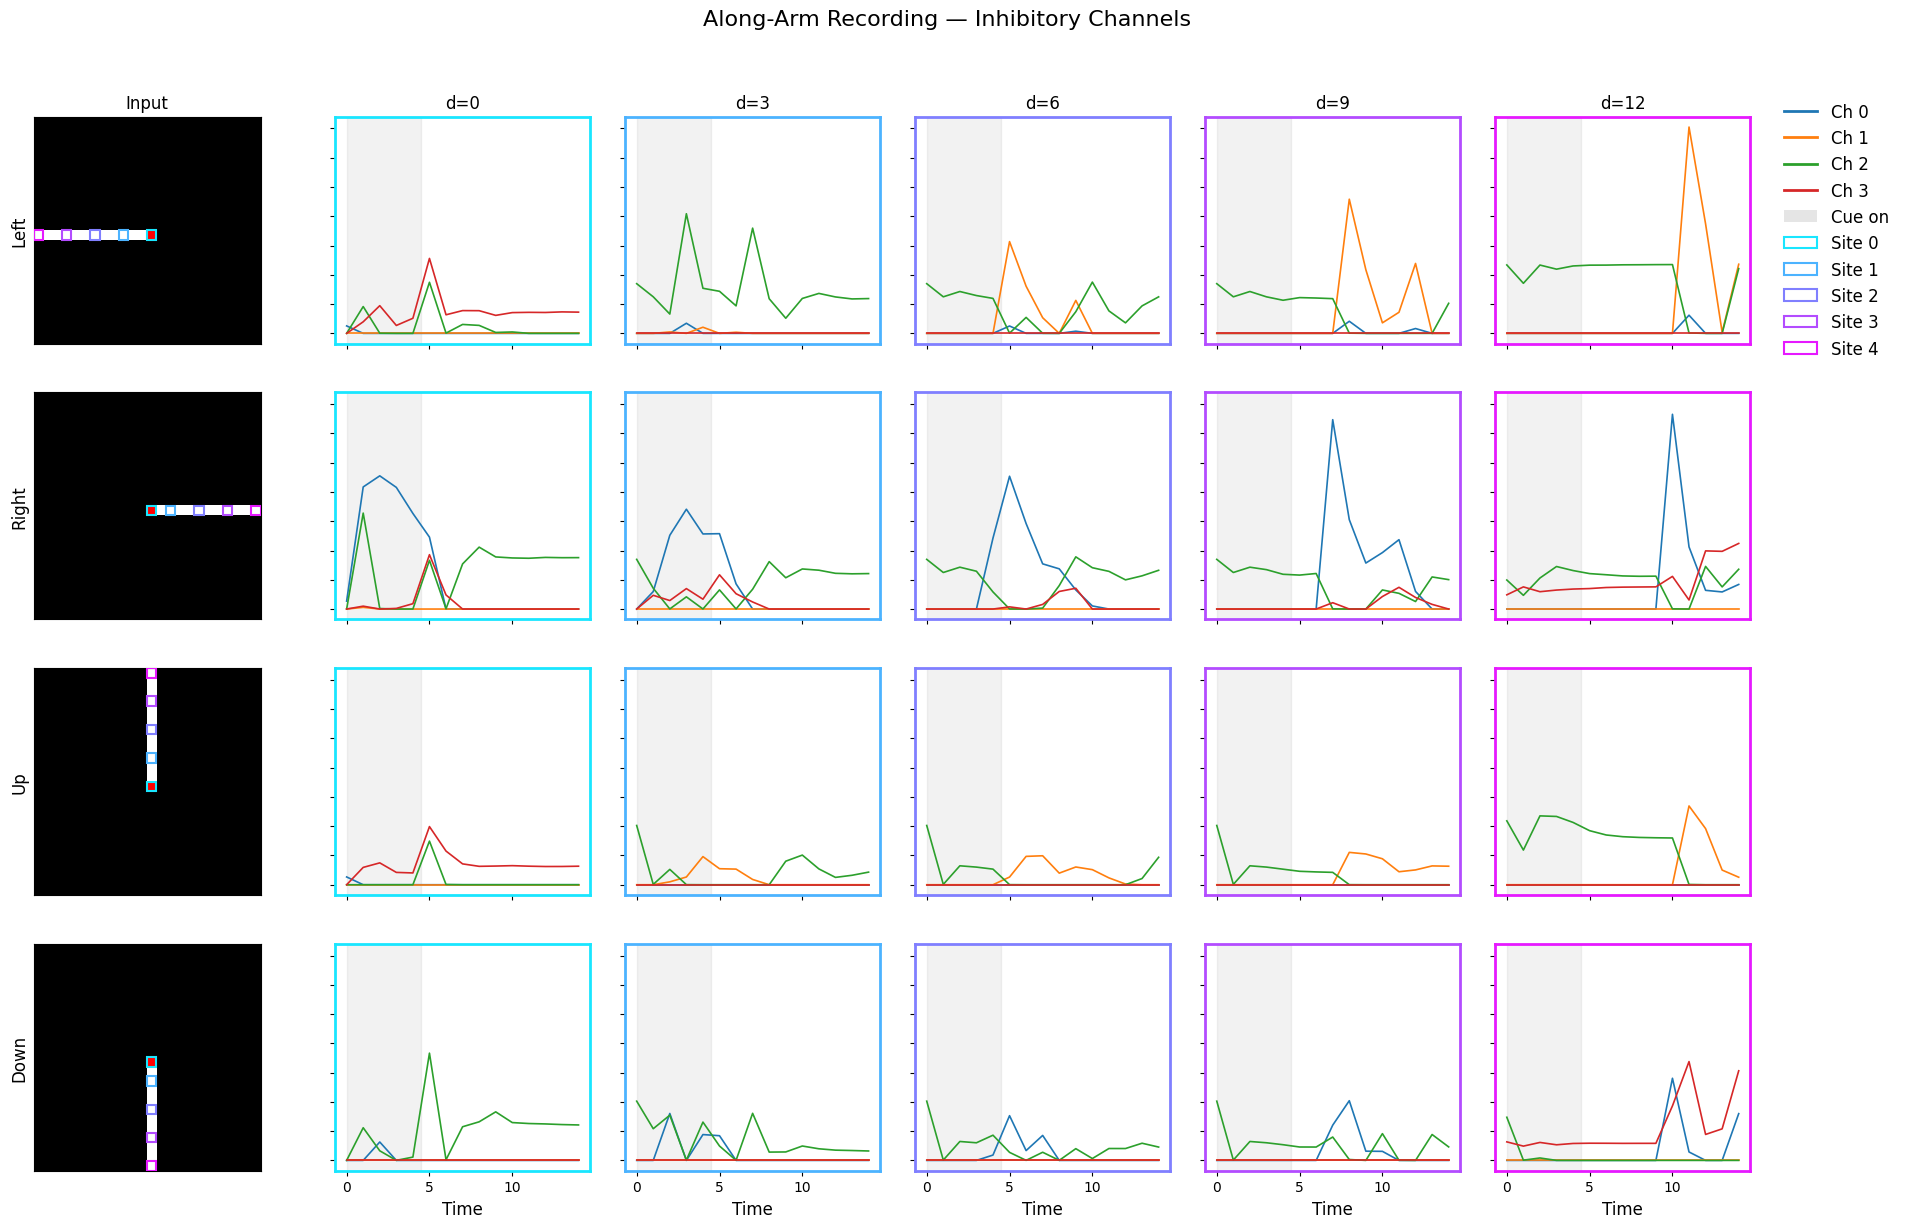

In [46]:
# Excitatory channels — along-arm recording
exc_arm_data = plot_electrophysiology_along_arm(
    model,
    neuron_type=0,
    n_sites=5,
    num_steps=15,
    num_input_steps=5,
    directions=ALL_4_DIRECTIONS,
    savepath=os.path.join(save_dir, "figure_electrophys_arm_exc.svg"),
)

# Inhibitory channels — along-arm recording
inh_arm_data = plot_electrophysiology_along_arm(
    model,
    neuron_type=1,
    num_steps=15,
    num_input_steps=5,
    n_sites=5,
    directions=ALL_4_DIRECTIONS,
    savepath=os.path.join(save_dir, "figure_electrophys_arm_inh.svg"),
)

## Polar Tuning Curves

In [47]:
def plot_polar_tuning(
    model,
    directions=ALL_8_DIRECTIONS,
    corridor_idx=12,
    point_pos=(12, 12),
    num_steps=10,
    num_input_steps=None,
    neuron_type=0,
    d=0,
    normalize=True,
    savepath=None,
):
    """
    Polar tuning curve: for each channel, plot final-step activity as a function
    of stimulus direction on a polar plot.

    Args:
        d: Distance (in logical cells) from center along each arm to place the
           recording site. 0 = center.
        num_steps: Total timesteps to run the model.
        normalize: If True, min-max normalize each channel's responses across
                   directions to [0, 1] so tuning shape is comparable.
    """
    n_channels = 8 if neuron_type == 0 else 4
    colors = plt.cm.tab10(np.arange(n_channels))
    if num_input_steps is None:
        num_input_steps = num_steps

    center_pi, center_pj = 2 * point_pos[0], 2 * point_pos[1]

    # Collect final-step activity per direction
    angles = []
    responses = {ch: [] for ch in range(n_channels)}
    all_inp_nps = {}

    for direction in directions:
        inp, inp_np, _ = build_single_arm_input(
            direction=direction,
            corridor_idx=corridor_idx,
            point_pos=point_pos,
            num_steps=num_steps,
            num_input_steps=num_input_steps,
        )
        all_inp_nps[direction] = inp_np

        with torch.no_grad():
            _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=None)

        activity = model.query_neuron_states(
            neuron_states, 0, neuron_type
        ).detach().cpu()[0]  # (T, C, H, W)

        # Get recording position at distance d cells from center along the arm
        pi, pj = get_position_at_distance(direction, d, corridor_idx, point_pos)

        # Record from 2x2 block at the last timestep
        trace = record_2x2_block(activity, pi, pj).numpy()  # (T, C)
        final_response = trace[-1]  # (C,)

        angles.append(DIRECTION_ANGLES[direction])
        for ch in range(n_channels):
            responses[ch].append(final_response[ch])

    # Normalize each channel across directions (min-max -> [0, 1])
    if normalize:
        for ch in range(n_channels):
            vals = np.array(responses[ch])
            vmin, vmax = vals.min(), vals.max()
            if vmax - vmin > 1e-12:
                responses[ch] = ((vals - vmin) / (vmax - vmin)).tolist()
            else:
                responses[ch] = [0.0] * len(vals)

    # Close the polar curve by appending the first point
    angles_closed = angles + [angles[0]]

    # --- Layout: input viz row + polar plot ---
    n_dirs = len(directions)
    fig = plt.figure(figsize=(max(2.5 * n_dirs, 12), 7))
    gs = GridSpec(2, n_dirs, figure=fig, height_ratios=[1, 2.5], hspace=0.3)

    # Top row: input visualizations
    for d_idx, direction in enumerate(directions):
        ax_img = fig.add_subplot(gs[0, d_idx])
        rec_pos = [get_position_at_distance(direction, d, corridor_idx, point_pos)]
        draw_input_with_sites(ax_img, all_inp_nps[direction], rec_pos, site_colors='lime')
        ax_img.set_title(direction.replace("-", "\n"), fontsize=9)

    # Bottom: single polar plot spanning all columns
    ax_polar = fig.add_subplot(gs[1, :], projection='polar')

    for ch in range(n_channels):
        vals = responses[ch] + [responses[ch][0]]  # close the curve
        ax_polar.plot(angles_closed, vals, color=colors[ch], linewidth=2, label=f"Ch {ch}")
        ax_polar.fill(angles_closed, vals, color=colors[ch], alpha=0.08)

    # Set direction labels
    ax_polar.set_thetagrids(
        [np.degrees(DIRECTION_ANGLES[dn]) for dn in directions],
        labels=[dn.capitalize() for dn in directions],
        fontsize=9,
    )
    ax_polar.set_theta_zero_location('E')   # 0° = right
    ax_polar.set_theta_direction(1)        # counterclockwise (standard math: up=90°)

    ax_polar.legend(loc='upper left', bbox_to_anchor=(1.05, 1.0), fontsize=12, frameon=False)

    type_str = "Excitatory" if neuron_type == 0 else "Inhibitory"
    norm_str = ", normalized" if normalize else ""
    fig.suptitle(f"Polar Tuning — {type_str} (d={d}, T={num_steps}{norm_str})", fontsize=16, y=1.02)
    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, format='svg', bbox_inches='tight')
    plt.show()
    return responses

/tmp/ipykernel_2279751/3333395949.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


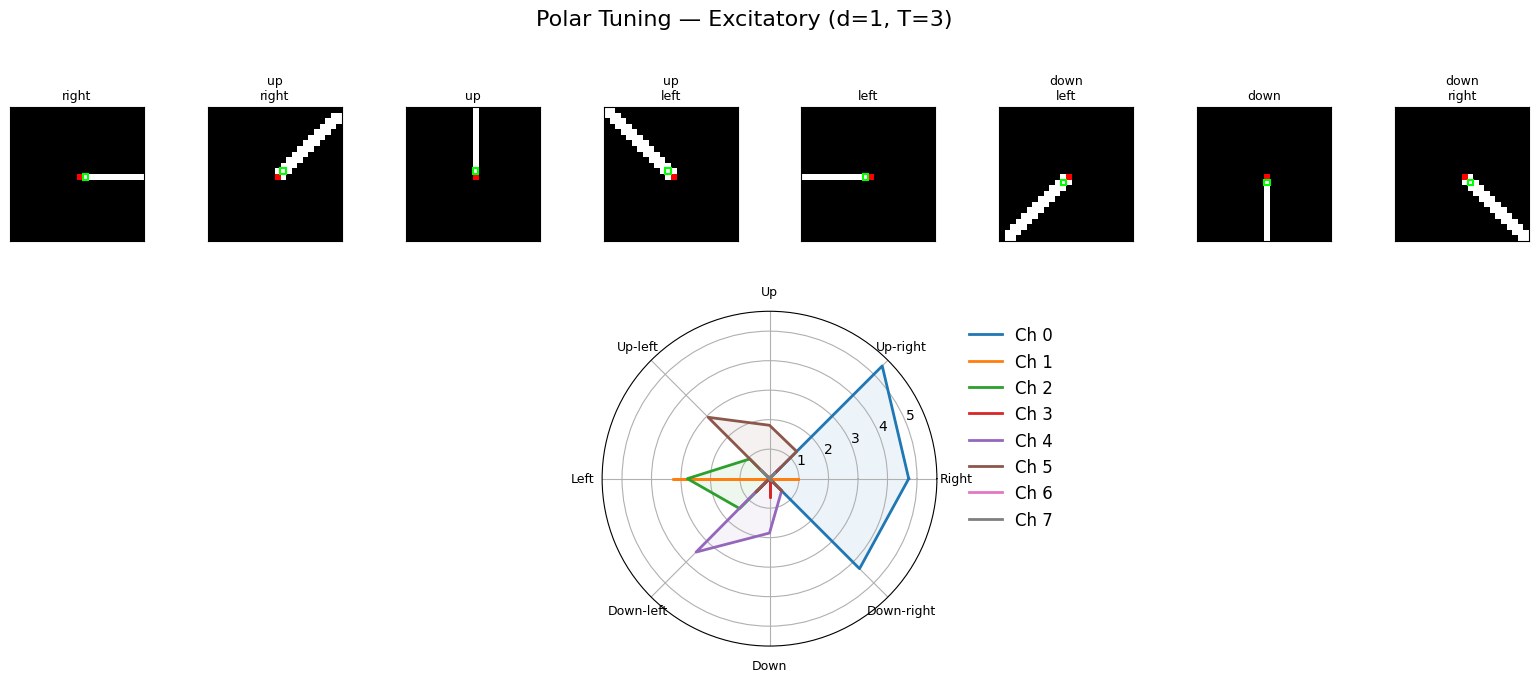

/tmp/ipykernel_2279751/3333395949.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


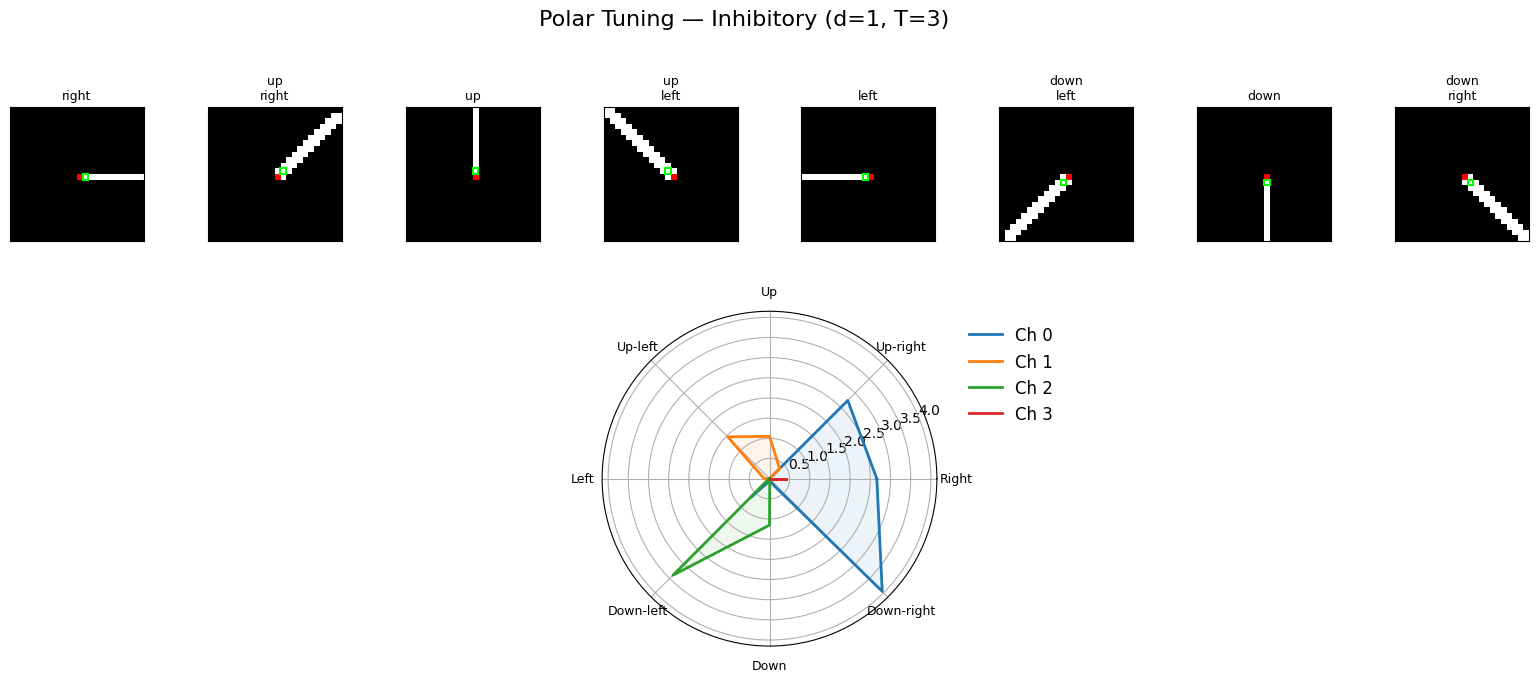

In [48]:
# Excitatory polar tuning
for d in range(1, 2):
    plot_polar_tuning(model, neuron_type=0, d=d, num_steps=3, normalize=False, directions=ALL_8_DIRECTIONS,
        savepath=os.path.join(save_dir, f"figure_s3_polar_exc_d{d}.svg"))

# Inhibitory polar tuning
for d in range(1, 2):
    plot_polar_tuning(model, neuron_type=1, d=d, num_steps=3, normalize=False, directions=ALL_8_DIRECTIONS,
        savepath=os.path.join(save_dir, f"figure_s3_polar_inh_d{d}.svg"))

# Figure S4 - Wall-Gating: Inhibitory Boundary Response

In [49]:
def build_terminated_corridor_input(
    corridor_length=8,
    direction="right",
    corridor_idx=12,
    point_pos=(12, 12),
    num_steps=10,
    num_input_steps=5,
):
    """
    Build a corridor of finite length that terminates at a wall.
    The cue is at point_pos, corridor extends corridor_length cells
    in the given direction from point_pos.

    Returns:
        inp, inp_np, just_walls (same format as build_single_arm_input)
        wall_pos: (pixel_i, pixel_j) of the 2x2 block just past the corridor end (wall).
        end_pos: (pixel_i, pixel_j) of the last corridor cell.
    """
    base = np.zeros((24, 24))
    walls = base.copy()
    r, c = point_pos

    dr, dc = {"right": (0, 1), "left": (0, -1), "up": (-1, 0), "down": (1, 0)}[direction]

    corridor_cells = []
    for i in range(corridor_length):
        nr, nc = r + dr * i, c + dc * i
        if 0 <= nr < 24 and 0 <= nc < 24:
            walls[nr, nc] = 1
            corridor_cells.append((nr, nc))

    end_r, end_c = corridor_cells[-1]
    wall_r, wall_c = end_r + dr, end_c + dc
    # Clamp wall position to valid range
    wall_r = max(0, min(23, wall_r))
    wall_c = max(0, min(23, wall_c))

    walls = walls.repeat(2, axis=0).repeat(2, axis=1)
    walls = np.stack([walls, walls, walls], axis=0)

    points = base.copy()
    points[point_pos[0], point_pos[1]] = 1
    points = points.repeat(2, axis=0).repeat(2, axis=1)
    points = points[np.newaxis, ...]

    C = np.concatenate([walls, points], axis=0)
    C = np.repeat(C[None, ...], num_input_steps, axis=0)

    empty_points = np.zeros_like(points)
    just_walls_np = np.concatenate([walls, empty_points], axis=0)
    D = np.repeat(just_walls_np[None, ...], num_steps - num_input_steps, axis=0)

    inp_np = np.concatenate([C, D], axis=0)
    inp = torch.as_tensor(inp_np, dtype=torch.float32).to(device)
    just_walls = torch.as_tensor(just_walls_np, dtype=torch.float32).to(device)

    end_pos = (2 * end_r, 2 * end_c)
    wall_pos = (2 * wall_r, 2 * wall_c)

    # Recording sites along corridor + at wall
    site_cells = []
    n_corridor_sites = min(5, len(corridor_cells))
    indices = np.linspace(0, len(corridor_cells) - 1, n_corridor_sites, dtype=int)
    for idx in indices:
        cr, cc = corridor_cells[idx]
        site_cells.append((2 * cr, 2 * cc))
    site_cells.append(wall_pos)  # extra site just past the wall

    return inp, inp_np, just_walls, site_cells, end_pos, wall_pos


def plot_wall_gating(
    model,
    corridor_length=8,
    direction="right",
    corridor_idx=12,
    point_pos=(12, 12),
    num_steps=10,
    num_input_steps=5,
    savepath=None,
):
    """
    Wall-gating experiment: record excitatory and inhibitory activity
    at sites along a terminated corridor and at the wall boundary.
    Shows how inhibition gates activity at walls.
    """
    inp, inp_np, just_walls, sites, end_pos, wall_pos = build_terminated_corridor_input(
        corridor_length=corridor_length, direction=direction,
        corridor_idx=corridor_idx, point_pos=point_pos,
        num_steps=num_steps, num_input_steps=num_input_steps,
    )

    n_sites = len(sites)

    with torch.no_grad():
        _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=None)

    exc_act = model.query_neuron_states(neuron_states, 0, 0).detach().cpu()[0]  # (T, 8, H, W)
    inh_act = model.query_neuron_states(neuron_states, 0, 1).detach().cpu()[0]  # (T, 4, H, W)

    exc_traces = [record_2x2_block(exc_act, pi, pj).numpy() for pi, pj in sites]
    inh_traces = [record_2x2_block(inh_act, pi, pj).numpy() for pi, pj in sites]

    n_exc_ch = exc_traces[0].shape[1]
    n_inh_ch = inh_traces[0].shape[1]
    exc_colors = plt.cm.tab10(np.arange(n_exc_ch))
    inh_colors = plt.cm.Set2(np.arange(n_inh_ch))

    site_cmap = plt.cm.cool(np.linspace(0.1, 0.9, n_sites))

    # Layout: 3 rows x (n_sites + 1) cols
    # Row 0: input image (merged) + empty
    # Row 1: exc traces per site
    # Row 2: inh traces per site
    fig, axes = plt.subplots(
        3, n_sites + 1, figsize=(3 * n_sites + 2, 9),
        gridspec_kw={"width_ratios": [1.5] + [1] * (n_sites - 1) + [0.5], "height_ratios": [1.2, 1, 1]},
        squeeze=False,
    )

    # Row 0, Col 0: input visualization with all sites
    ax_img = axes[0, 0]
    draw_input_with_sites(ax_img, inp_np, sites, site_colors=[site_cmap[s] for s in range(n_sites)])
    ax_img.set_title("Input + Sites", fontsize=12)
    for j in range(1, n_sites + 1):
        axes[0, j].axis('off')

    center_pi, center_pj = 2 * point_pos[0], 2 * point_pos[1]

    # Shared y ranges
    exc_all = np.concatenate(exc_traces, axis=0)
    inh_all = np.concatenate(inh_traces, axis=0)
    exc_ylim = (exc_all.min() - 0.02, exc_all.max() + 0.02)
    inh_ylim = (inh_all.min() - 0.02, inh_all.max() + 0.02)

    for s_idx in range(n_sites):
        pi, pj = sites[s_idx]
        dist = abs(pi - center_pi) // 2 + abs(pj - center_pj) // 2
        is_wall = (s_idx == n_sites - 1)
        label = "wall" if is_wall else f"d={dist}"

        # Exc trace
        ax_e = axes[1, s_idx]
        T = exc_traces[s_idx].shape[0]
        for ch in range(n_exc_ch):
            ax_e.plot(range(T), exc_traces[s_idx][:, ch], color=exc_colors[ch], linewidth=1.2)
        ax_e.axvspan(0, num_input_steps - 0.5, alpha=0.1, color='gray')
        ax_e.set_ylim(exc_ylim)
        ax_e.set_title(label, fontsize=12)
        for spine in ax_e.spines.values():
            spine.set_edgecolor(site_cmap[s_idx]); spine.set_linewidth(2)
        if s_idx == 0:
            ax_e.set_ylabel("Excitatory", fontsize=12)
        else:
            ax_e.set_yticklabels([])
        ax_e.set_xticklabels([])

        # Inh trace
        ax_i = axes[2, s_idx]
        for ch in range(n_inh_ch):
            ax_i.plot(range(T), inh_traces[s_idx][:, ch], color=inh_colors[ch], linewidth=1.2)
        ax_i.axvspan(0, num_input_steps - 0.5, alpha=0.1, color='gray')
        ax_i.set_ylim(inh_ylim)
        for spine in ax_i.spines.values():
            spine.set_edgecolor(site_cmap[s_idx]); spine.set_linewidth(2)
        if s_idx == 0:
            ax_i.set_ylabel("Inhibitory", fontsize=12)
        else:
            ax_i.set_yticklabels([])
        ax_i.set_xlabel("Time", fontsize=12)

    # Legend column
    for row in range(1, 3):
        ax_leg = axes[row, -1]
        ax_leg.axis('off')
    ax_leg = axes[1, -1]
    handles_e = [plt.Line2D([0], [0], color=exc_colors[ch], linewidth=2, label=f"E Ch {ch}")
                 for ch in range(n_exc_ch)]
    ax_leg.legend(handles=handles_e, loc='center', fontsize=12, frameon=False)
    ax_leg2 = axes[2, -1]
    handles_i = [plt.Line2D([0], [0], color=inh_colors[ch], linewidth=2, label=f"I Ch {ch}")
                 for ch in range(n_inh_ch)]
    ax_leg2.legend(handles=handles_i, loc='center', fontsize=12, frameon=False)

    fig.suptitle(f"Wall-Gating — {direction.capitalize()} Corridor (len={corridor_length})",
                 fontsize=16, y=1.02)
    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, format='svg', bbox_inches='tight')
    plt.show()

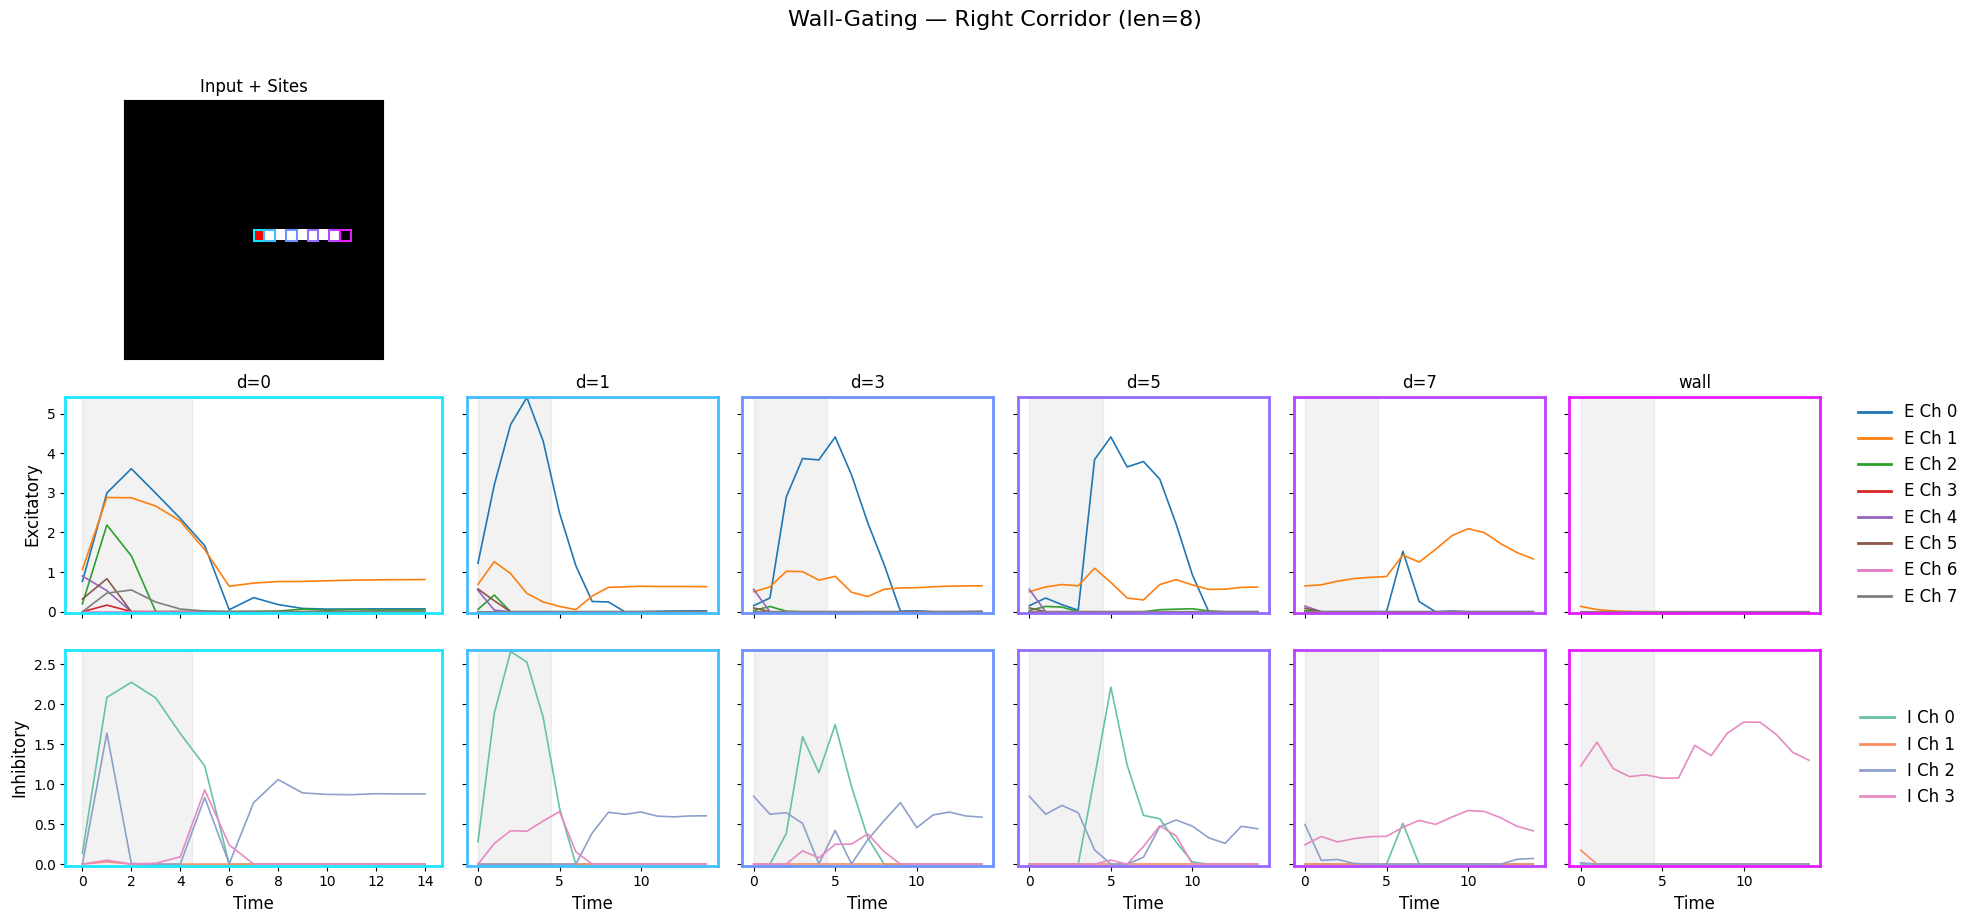

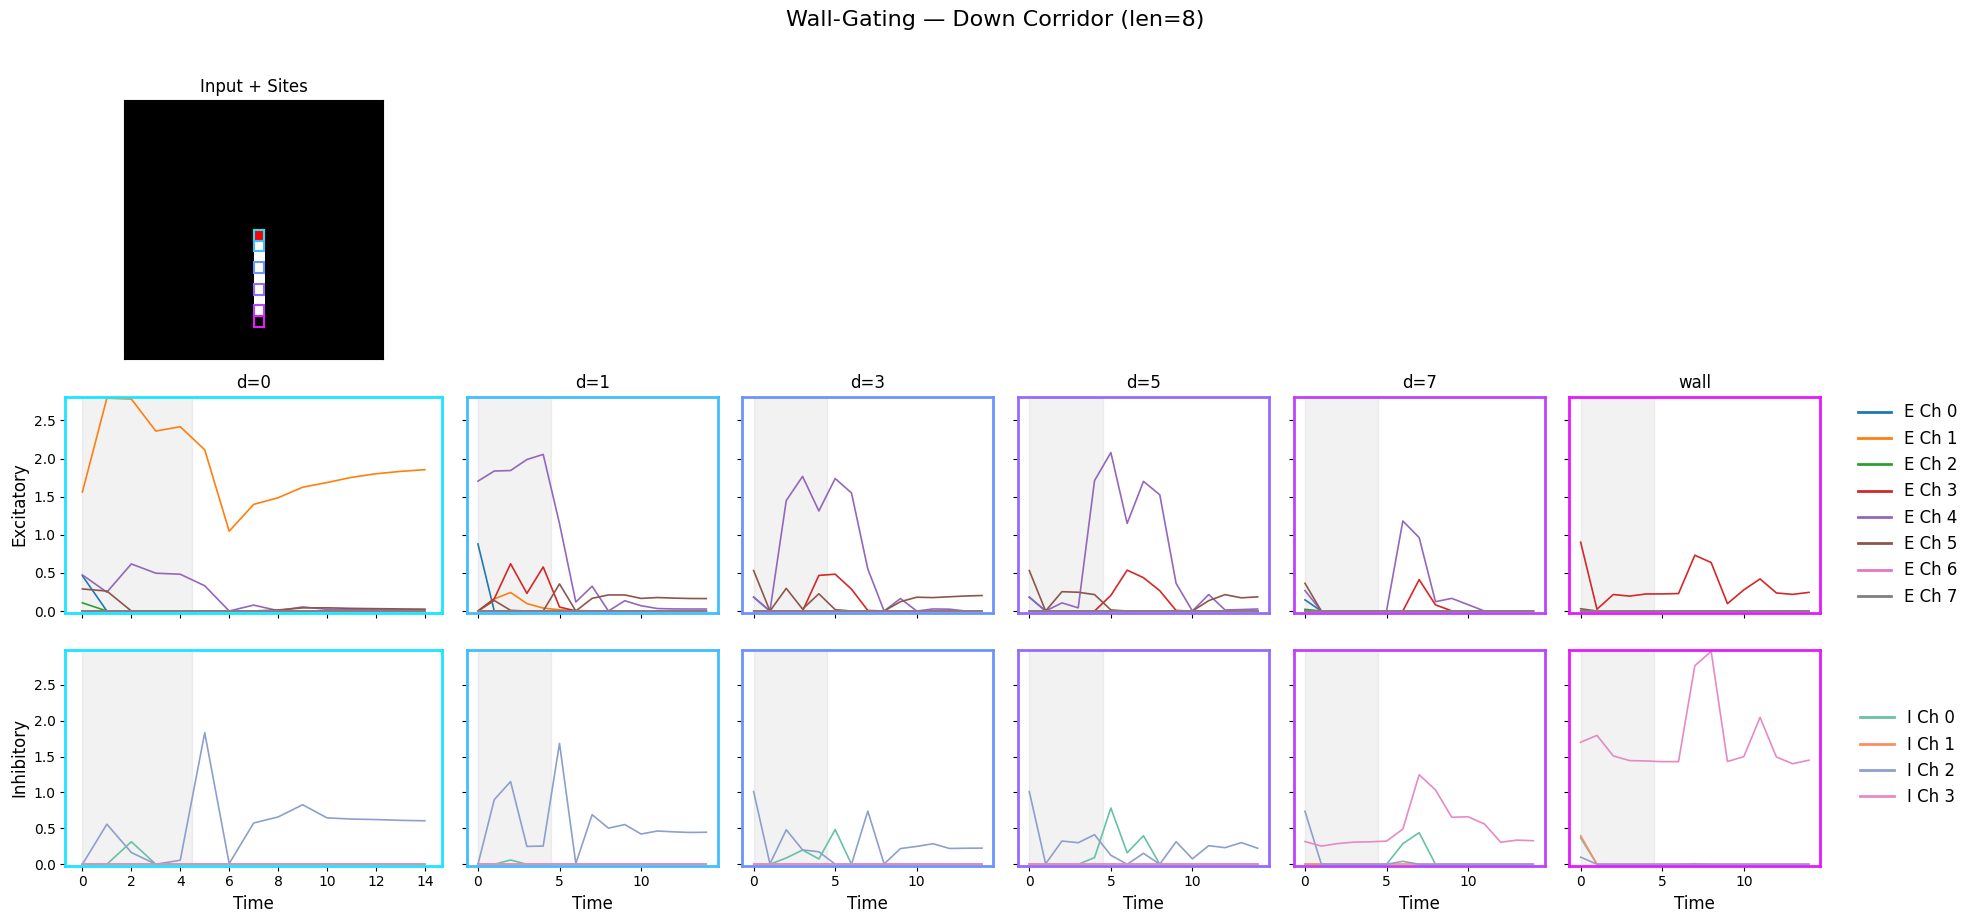

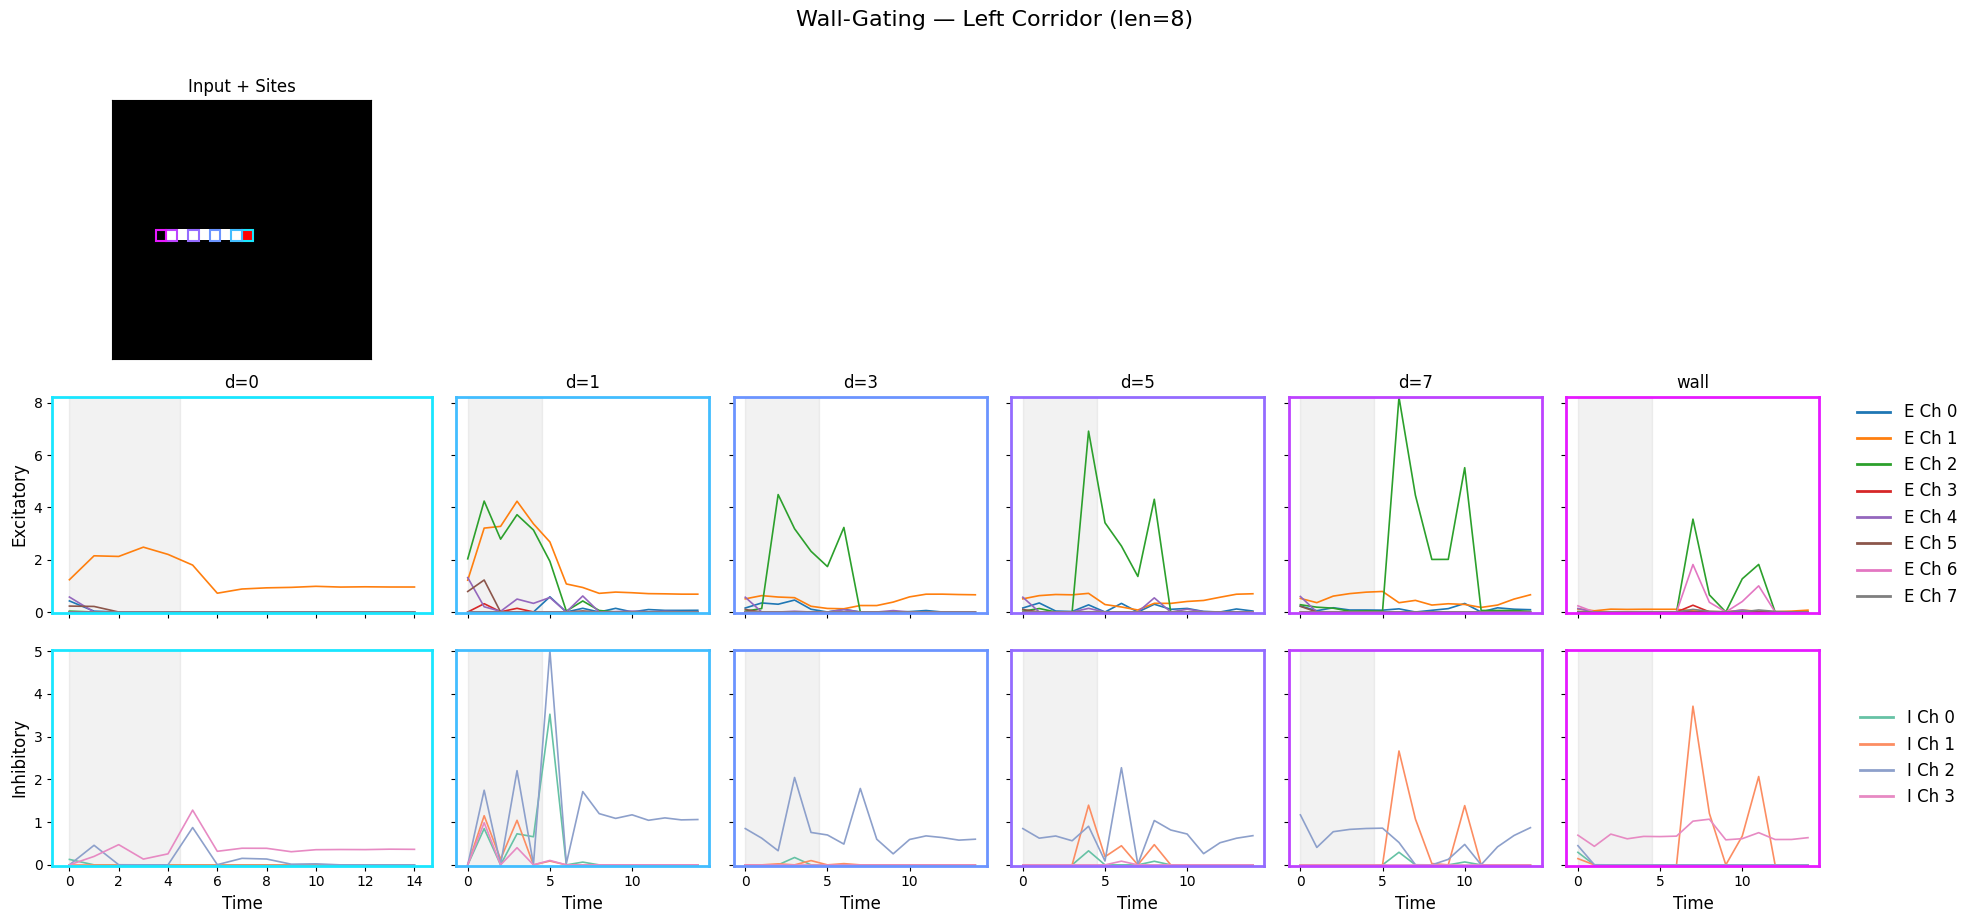

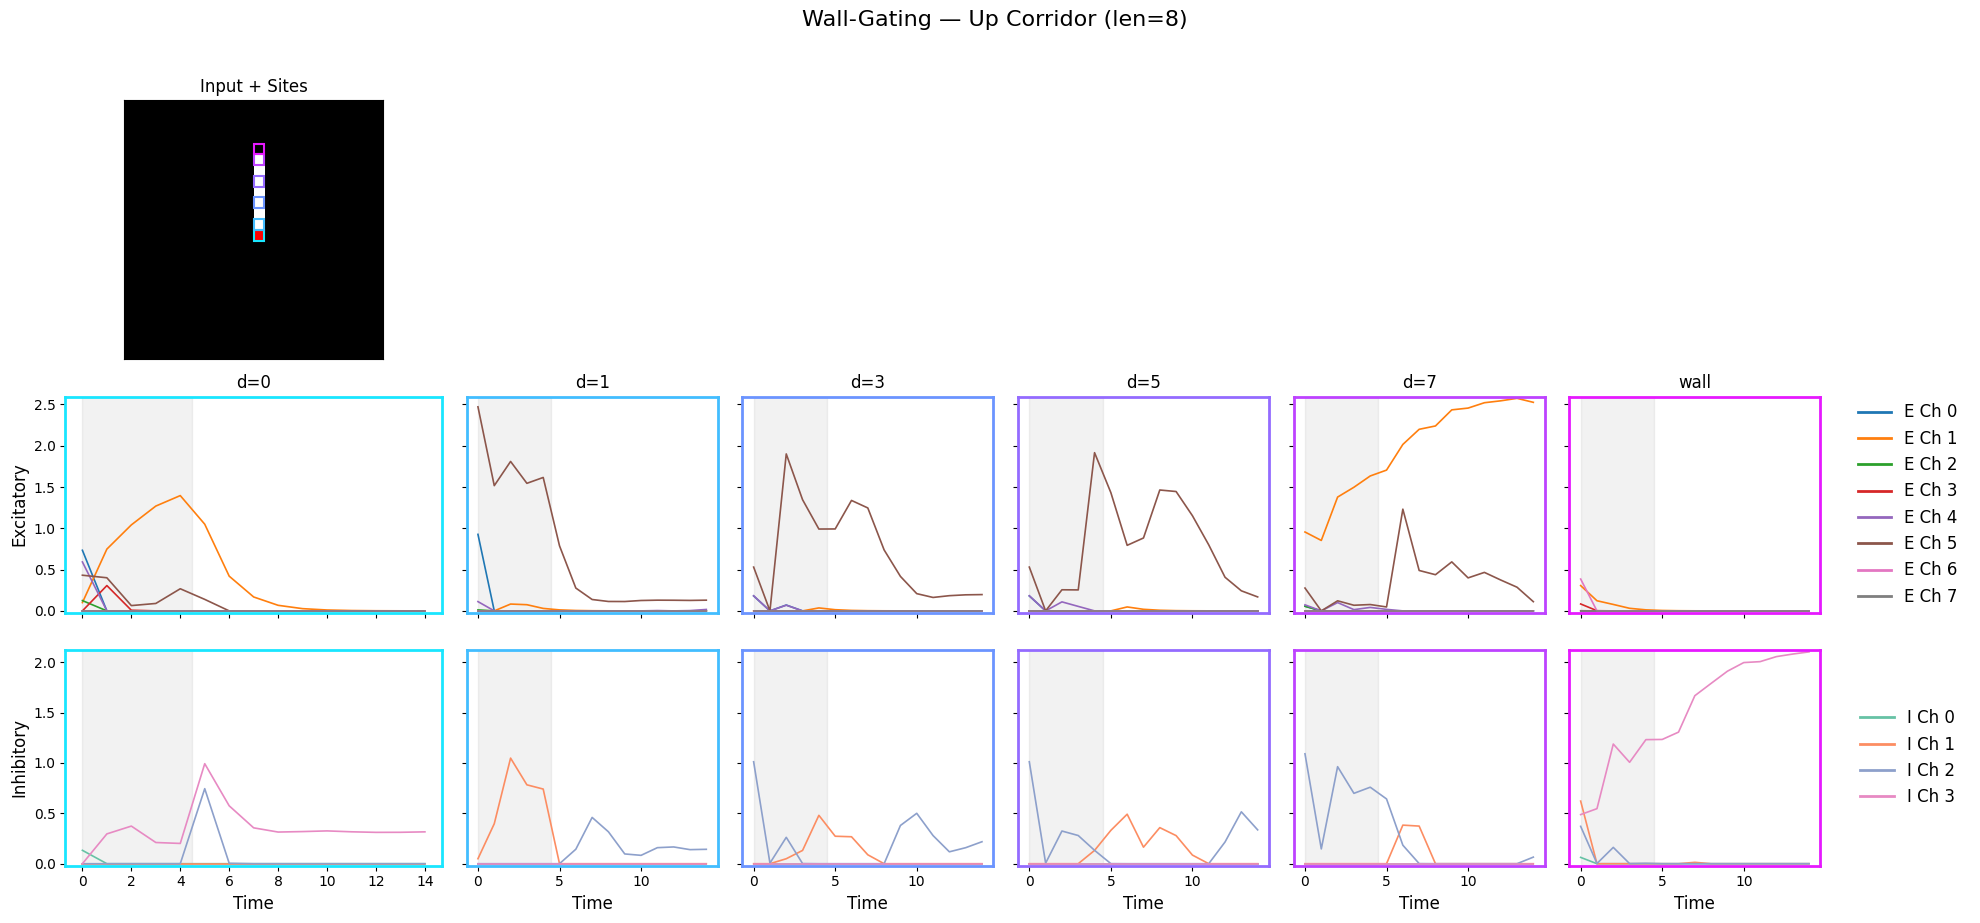

In [50]:
# Wall-gating: right corridor
plot_wall_gating(model, corridor_length=8, direction="right",
    num_steps=15, num_input_steps=5,
    savepath=os.path.join(save_dir, "figure_s4_wall_gating_right.svg"))

# Wall-gating: down corridor
plot_wall_gating(model, corridor_length=8, direction="down",
    num_steps=15, num_input_steps=5,
    savepath=os.path.join(save_dir, "figure_s4_wall_gating_down.svg"))

plot_wall_gating(model, corridor_length=8, direction="left",
    num_steps=15, num_input_steps=5,
    savepath=os.path.join(save_dir, "figure_s4_wall_gating_left.svg"))

plot_wall_gating(model, corridor_length=8, direction="up",
    num_steps=15, num_input_steps=5,
    savepath=os.path.join(save_dir, "figure_s4_wall_gating_up.svg"))

# Figure S5 - Receptive Field Mapping

In [51]:
def build_open_field_with_cue(
    cue_pos,
    num_steps=10,
    num_input_steps=5,
):
    """
    Build an open-field (all corridors passable) input with a single-pixel cue.

    Args:
        cue_pos: (row, col) in 24x24 space for the cue.

    Returns:
        inp: Tensor (num_steps, 4, 48, 48).
    """
    walls = np.ones((24, 24))
    walls = walls.repeat(2, axis=0).repeat(2, axis=1)
    walls = np.stack([walls, walls, walls], axis=0)

    points = np.zeros((24, 24))
    points[cue_pos[0], cue_pos[1]] = 1
    points = points.repeat(2, axis=0).repeat(2, axis=1)[np.newaxis, ...]

    C = np.concatenate([walls, points], axis=0)
    C = np.repeat(C[None, ...], num_input_steps, axis=0)

    empty_points = np.zeros_like(points)
    just_walls_np = np.concatenate([walls, empty_points], axis=0)
    D = np.repeat(just_walls_np[None, ...], num_steps - num_input_steps, axis=0)

    inp_np = np.concatenate([C, D], axis=0)
    inp = torch.as_tensor(inp_np, dtype=torch.float32).to(device)
    return inp


def map_receptive_field(
    model,
    record_pos=(12, 12),
    neuron_type=0,
    num_steps=10,
    num_input_steps=5,
    grid_step=1,
):
    """
    Map the receptive field of a recording site by sweeping a cue across the grid.

    For each cue position in a 24x24 grid (sampled every grid_step), present the cue
    on an open field and record the response at record_pos at the final timestep.

    Args:
        record_pos: (row, col) in 24x24 space of the recording site.
        neuron_type: 0 = excitatory, 1 = inhibitory.
        grid_step: Step size for cue positions (1 = every cell, 2 = every other).

    Returns:
        rf_maps: array of shape (n_channels, 24//grid_step, 24//grid_step).
    """
    n_channels = 8 if neuron_type == 0 else 4
    rec_pi, rec_pj = 2 * record_pos[0], 2 * record_pos[1]

    rows = list(range(0, 24, grid_step))
    cols = list(range(0, 24, grid_step))
    rf_maps = np.zeros((n_channels, len(rows), len(cols)))

    for ri, r in enumerate(rows):
        for ci, c in enumerate(cols):
            inp = build_open_field_with_cue(
                cue_pos=(r, c), num_steps=num_steps, num_input_steps=num_input_steps)
            with torch.no_grad():
                _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=None)
            activity = model.query_neuron_states(
                neuron_states, 0, neuron_type).detach().cpu()[0]
            response = record_2x2_block(activity, rec_pi, rec_pj).numpy()
            rf_maps[:, ri, ci] = response[-1]  # final timestep

    return rf_maps, rows, cols


def plot_receptive_fields(
    rf_maps,
    rows,
    cols,
    record_pos=(12, 12),
    neuron_type=0,
    savepath=None,
):
    """
    Plot receptive field maps as heatmaps for each channel.

    Args:
        rf_maps: (n_channels, n_rows, n_cols) array.
    """
    n_channels = rf_maps.shape[0]
    n_cols_plot = min(n_channels, 4)
    n_rows_plot = (n_channels + n_cols_plot - 1) // n_cols_plot

    fig, axes = plt.subplots(n_rows_plot, n_cols_plot,
                              figsize=(4 * n_cols_plot, 4 * n_rows_plot), squeeze=False)

    # Global color range for consistency
    vmin, vmax = rf_maps.min(), rf_maps.max()

    for ch in range(n_channels):
        ax = axes[ch // n_cols_plot, ch % n_cols_plot]
        im = ax.imshow(rf_maps[ch], cmap='RdBu_r', interpolation='none',
                       vmin=vmin, vmax=vmax,
                       extent=[cols[0], cols[-1] + 1, rows[-1] + 1, rows[0]])
        # Mark recording site
        rec_r, rec_c = record_pos
        rect = Rectangle((rec_c - 0.5, rec_r - 0.5), 2, 2,
                          linewidth=2, edgecolor='lime', facecolor='none', zorder=5)
        ax.add_patch(rect)
        ax.set_title(f"Channel {ch}", fontsize=12)
        ax.set_xlabel("Col (24x24)")
        ax.set_ylabel("Row (24x24)")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Hide extra axes
    for idx in range(n_channels, n_rows_plot * n_cols_plot):
        axes[idx // n_cols_plot, idx % n_cols_plot].axis('off')

    type_str = "Excitatory" if neuron_type == 0 else "Inhibitory"
    fig.suptitle(f"Receptive Fields — {type_str} at ({record_pos[0]}, {record_pos[1]})",
                 fontsize=16, y=1.02)
    plt.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, format='svg', bbox_inches='tight')
    plt.show()

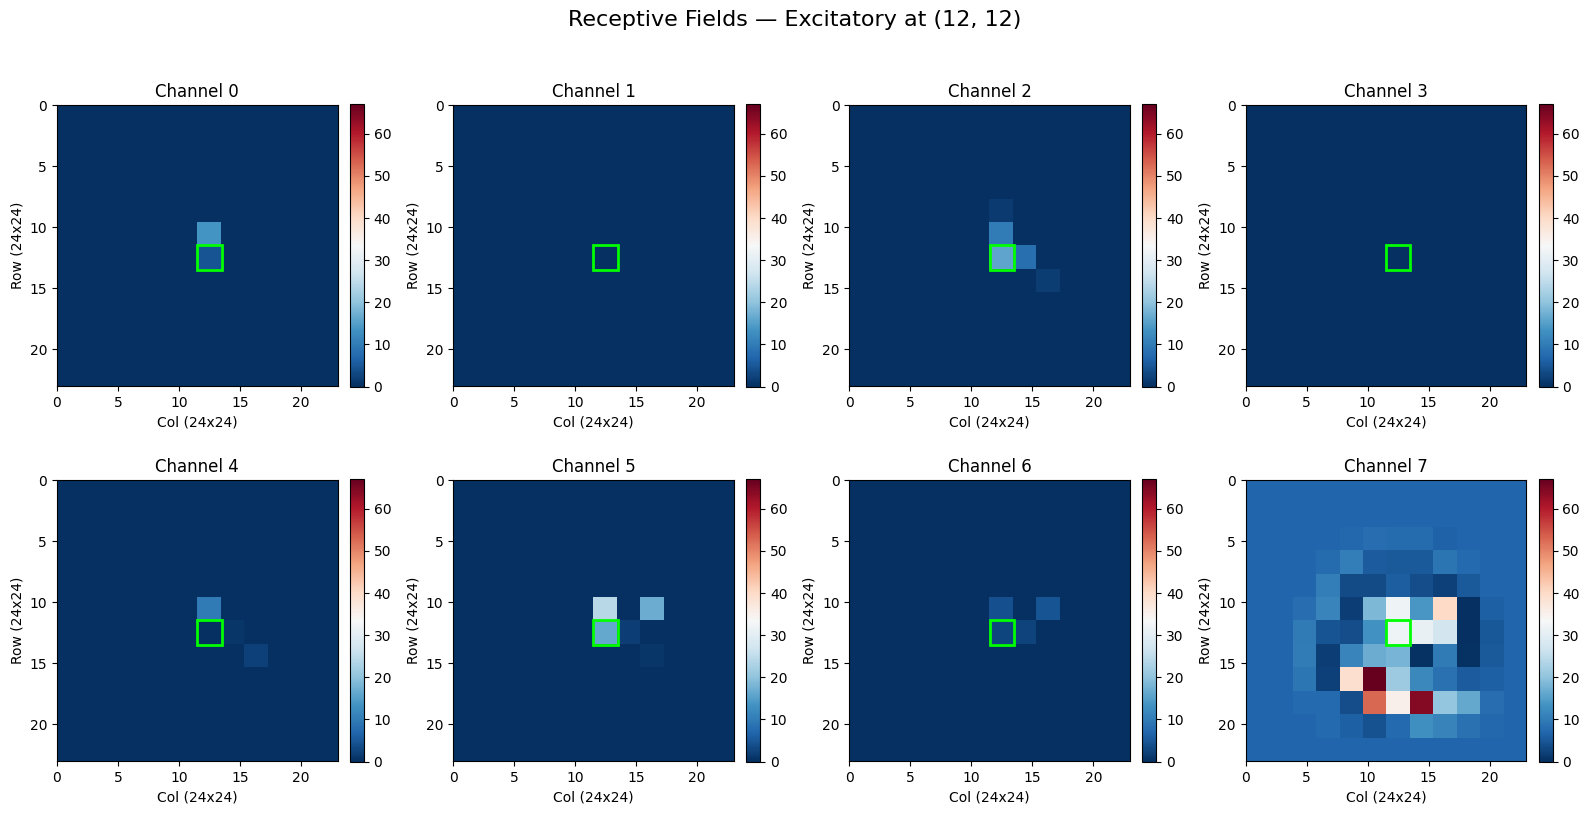

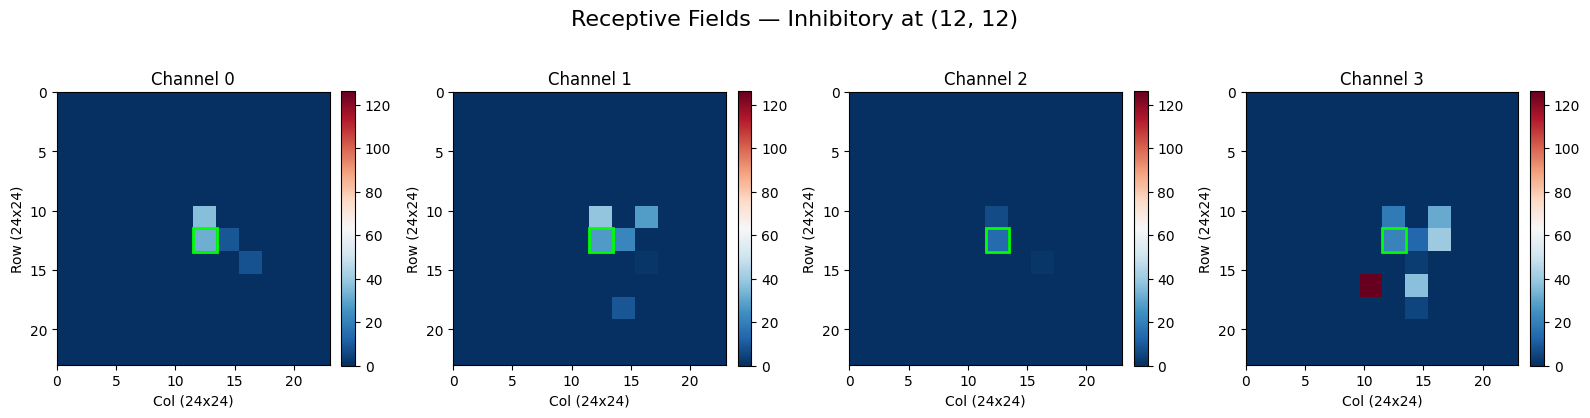

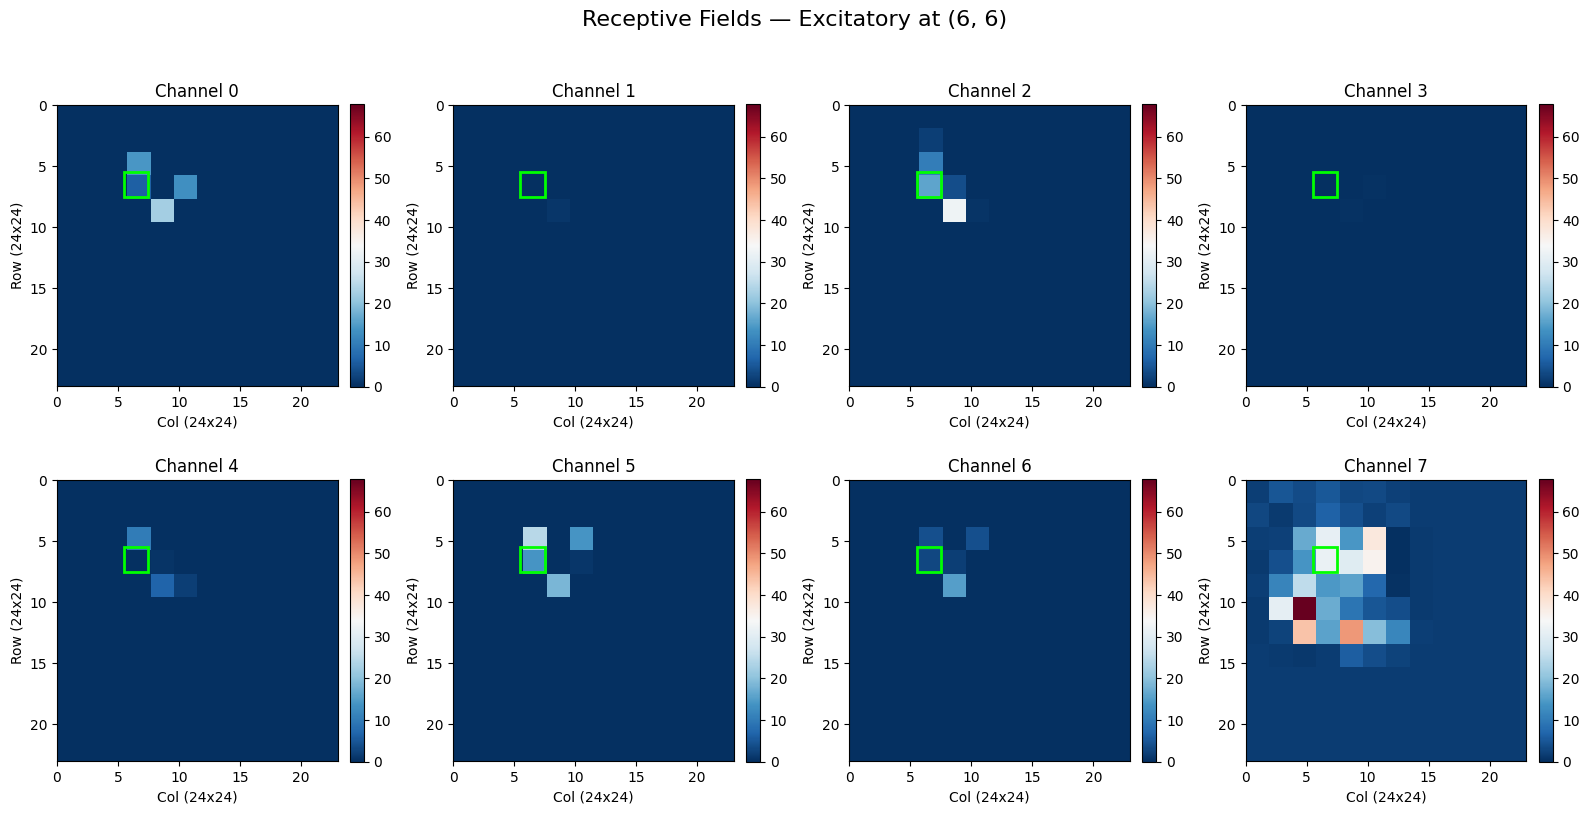

In [52]:
# Receptive field mapping — excitatory at center (grid_step=2 for speed)
exc_rf, rf_rows, rf_cols = map_receptive_field(
    model, record_pos=(12, 12), neuron_type=0, num_steps=10, grid_step=2)
plot_receptive_fields(exc_rf, rf_rows, rf_cols, record_pos=(12, 12), neuron_type=0,
    savepath=os.path.join(save_dir, "figure_s5_rf_exc_center.svg"))

# Receptive field mapping — inhibitory at center
inh_rf, rf_rows_i, rf_cols_i = map_receptive_field(
    model, record_pos=(12, 12), neuron_type=1, num_steps=10, grid_step=2)
plot_receptive_fields(inh_rf, rf_rows_i, rf_cols_i, record_pos=(12, 12), neuron_type=1,
    savepath=os.path.join(save_dir, "figure_s5_rf_inh_center.svg"))

# Receptive field mapping — excitatory at off-center position
exc_rf_off, rf_rows_o, rf_cols_o = map_receptive_field(
    model, record_pos=(6, 6), neuron_type=0, num_steps=10, grid_step=2)
plot_receptive_fields(exc_rf_off, rf_rows_o, rf_cols_o, record_pos=(6, 6), neuron_type=0,
    savepath=os.path.join(save_dir, "figure_s5_rf_exc_off_center.svg"))